# Cartilage Data Analysis

*Date: 16 July, 2026 - BY: Tomás Silva*

Tasks:
 - Import Dataset
 - Generate 3 stacked 2D plots using these specific features: `total intensity`, `total collagen` and `rho_new`.
    -   `rho_new`: degree of orientation, representing how aligned the collagen fibers are at one point
 - Define Evaluation Metric Functins
 - Run Models using different scalers: `StandardScaler`, `MinMaxScaler` and `RobustScaler`
 - Run Models using different features:
    - Primary Set: total SAXS intensity ($totalint$), total Collagen Intensity ($totalcol$), Degree of orientation ($rho_new$)
    - Microstructural features: Degree of orientation ($rho_new$), peak area ($wa2$), collagen D-spacing ($Dnew2$), fibril diameter ($Diameter2$)
    - Run with all 7 features combined
 - Run models using different values for min_samples {5, 10, 13}
 - Run models using control samples vs low injury vs high injury

 ### 1. Imports & Setting Up the Notebook


In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
from sklearn.metrics import adjusted_rand_score, homogeneity_score, completeness_score, normalized_mutual_info_score
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import kneighbors_graph
import hdbscan

# Color palette
palette_base = sns.color_palette("Set1")
my_colors = {-1: 'black'}
for i in range(50):
    my_colors[i] = palette_base[i % len(palette_base)]
print("Universal HDBSCAN color palette ready!")

Universal HDBSCAN color palette ready!


### 2. Import Dataset & Selecting Sample

In [2]:
df_import = pd.read_csv('Cartilage/master_data_file_v2_hsg.csv')
print(df_import.shape)

# Samples in the dataset
samples_id = df_import['sample no'].unique()
num_samples = len(samples_id)
print(f"\n{'-'*25}")
print(f"There are {num_samples} unique samples in this master dataset.")
print(f"\nThe sample IDs are: {samples_id}")
print(f"{'-'*25}")

# Generate a pair table with each sample category
info_df = df_import[['sample no', 'State', 'Group', 'Sample']].drop_duplicates()

unloaded_df = info_df[info_df['State'] == 'unloaded'].sort_values('sample no').reset_index(drop=True)
loaded_df = info_df[info_df['State'] == 'loaded'].sort_values('sample no').reset_index(drop=True)

pair_table = pd.DataFrame({
    'Unloaded_ID': unloaded_df['sample no'],
    'Loaded_ID': loaded_df['sample no'],
    'Condition': unloaded_df['Sample'], 
    'Treatment': unloaded_df['Group'] 
})
display(pair_table)

# Save
# pair_table.to_csv('Cartilage/Samples_inventory.csv', index=False)
# print('Samples_invetory saved as CSV.')

(47498, 17)

-------------------------
There are 60 unique samples in this master dataset.

The sample IDs are: [599112 599118 599124 599130 599134 599113 599119 599125 599131 599135
 599114 599120 599126 599132 599143 599115 599121 599127 599133 599144
 599116 599122 599128 599145 599147 599117 599123 599129 599146 599148
 599170 599177 599196 599202 599204 599171 599178 599197 599203 599205
 599161 599173 599179 599192 599198 599166 599174 599180 599193 599199
 599167 599175 599181 599194 599200 599168 599176 599182 599195 599201]
-------------------------


,Unloaded_ID,Loaded_ID,Condition,Treatment
0,599112,599113,control,untreated
1,599114,599115,lowinjury,untreated
2,599116,599117,highinjury,untreated
3,599118,599119,control,untreated
4,599120,599121,lowinjury,untreated
5,599122,599123,highinjury,untreated
6,599124,599125,control,untreated
7,599126,599127,lowinjury,untreated
8,599128,599129,highinjury,untreated
9,599130,599131,control,untreated


In [3]:
# Choosing the sample to analyse
sample_num = 599133

# Slice the data using the sample
df_slice = df_import[df_import['sample no'] == sample_num].copy()

# Verify the slice worked
print(f"\nData for sample {sample_num} has {len(df_slice)} rows and {len(df_slice.columns)} columns.")

# Filter
z_parameters = ['totalint', 'totalcoll', 'rho_new']
df_sample = df_slice.dropna(subset=z_parameters).copy()

# df_sample.head()


Data for sample 599133 has 853 rows and 17 columns.


### 3. Feature Plots

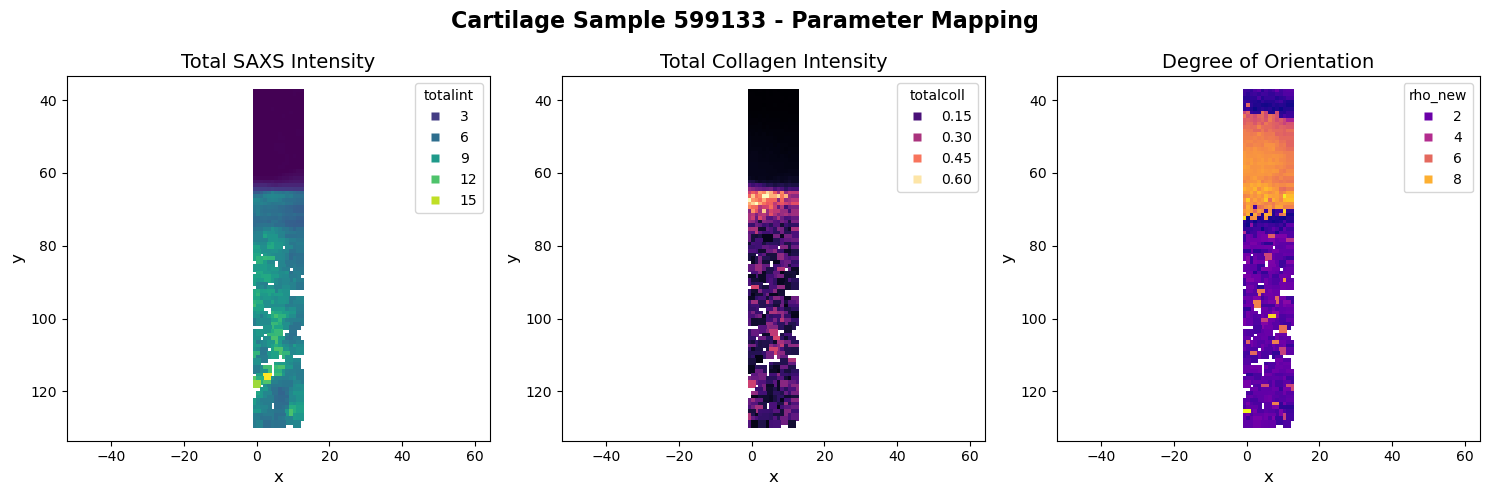

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Cartilage Sample {sample_num} - Parameter Mapping', fontsize=16, fontweight='bold')

# Total Intensity
sns.scatterplot(
    data=df_sample, x='ix', y='iy', 
    hue='totalint', palette='viridis', # viridis
    edgecolor='none', s=35, marker='s', ax=axes[0]
)
axes[0].set_title('Total SAXS Intensity', fontsize=14)
axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('y', fontsize=12)
axes[0].axis('equal')
axes[0].invert_yaxis()

# Total Collagen
sns.scatterplot(
    data=df_sample, x='ix', y='iy', 
    hue='totalcoll', palette='magma', # magma
    edgecolor='none', s=35, marker='s', ax=axes[1]
)
axes[1].set_title('Total Collagen Intensity', fontsize=14)
axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('y', fontsize=12)
axes[1].axis('equal')
axes[1].invert_yaxis()

# Rho New
sns.scatterplot(
    data=df_sample, x='ix', y='iy', 
    hue='rho_new', palette='plasma', # plasma
    edgecolor='none', s=35, marker='s', ax=axes[2]
)
axes[2].set_title('Degree of Orientation', fontsize=14)
axes[2].set_xlabel('x', fontsize=12)
axes[2].set_ylabel('y', fontsize=12)
axes[2].axis('equal')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

# Clustering the different samples:

We cluster each sample using HDBSCAN and Kmeans.

 - Compare the different forms of normalisation: $MinMaxScaler$, $StandardScaler$ and $RobustScaler$


 - Features used: `Total Intensity`, `Total Collage`, `rho_new`
 - Add `wa2`
 - switch to features: `rho_new`, `Dnew2`, `Diameter2`, `wa2`
 - Run with all features: `totalint`, `totalcol`, `rho_new`, `wa2`, `Dnew2`, `Diameter2`

 - Compare different values for min_samples in HDBSCAN

 - Compare model performance using control vs low injury vs high injury samples

 ### 1. Define the functions

 #### Metrics Function

In [5]:
def evaluate_clustering(true_labels, predicted_clusters):
    # 1. Calculate percentage of unclustered noise points (-1)
    total_points = len(predicted_clusters)
    noise_count = np.sum(predicted_clusters == -1)
    noise_pct = (noise_count / total_points) * 100 if total_points > 0 else 0.0

    # 2. Filter out HDBSCAN noise points (-1) for metric calculation
    valid_idx = predicted_clusters != -1
    y_true = true_labels[valid_idx]
    y_pred = predicted_clusters[valid_idx]
    
    # If a model puts everything as noise, return NaNs to avoid crashing
    if len(np.unique(y_pred)) == 0:
        print("All points classified as noise (-1). Cannot evaluate.\n")
        return {"ARI": np.nan, "NMI": np.nan, "Homogeneity": np.nan, "Completeness": np.nan, "Noise_%": 100.0}
    
    # 3. Core Metrics
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    homogeneity = homogeneity_score(y_true, y_pred)
    completeness = completeness_score(y_true, y_pred)
    
    # 4. Print Results
    print(f"Adjusted Rand Index (ARI):    {ari:.3f}")
    print(f"Normalized Mutual Info (NMI): {nmi:.3f}")
    print(f"Homogeneity:                  {homogeneity:.3f}")
    print(f"Completeness:                 {completeness:.3f}")
    print(f"Noise Percentage:             {noise_pct:.1f}%\n")

    return {
        "ARI": ari, 
        "NMI": nmi, 
        "Homogeneity": homogeneity, 
        "Completeness": completeness,
        "Noise_%": noise_pct
    }

#### Clustering Function (K-means & HDBSCAN)

In [6]:
def analyse_and_plot_sample(sample_num, df_master, z_params, hdb_csize=40, hdb_msamples=10, scaler_k=MinMaxScaler(), scaler_hdb=MinMaxScaler()):
    # 1. Slice and drop NaNs
    df_sample = df_master[df_master['sample no'] == sample_num].dropna(subset=z_params).copy()

    # 1.2. Filter the a specific zone (e.g. trabecular zone 'tb')
    # df_sample = df_sample[~df_sample['region'].isin(['tb'])].copy()

    # 2. Count the exact number of unique zones in this specific sample's ground truth
    dynamic_k = df_sample['region'].nunique()
    
    # 3. Scale the data (MinMaxScaler, StandardScaler, RobustScaler)
    # K-Means
    X_scaled_k = scaler_k.fit_transform(df_sample[z_params])
    
    # HDBSCAN
    X_scaled_hdb = scaler_hdb.fit_transform(df_sample[z_params])
    
    # 4. K-Means (Dynamic Clusters based on Ground Truth)
    kmeans = KMeans(n_clusters=dynamic_k, random_state=42)
    df_sample['kmeans_cluster'] = kmeans.fit_predict(X_scaled_k)
    
    # 5. HDBSCAN
    hdb = hdbscan.HDBSCAN(min_cluster_size=hdb_csize, min_samples=hdb_msamples)
    df_sample['hdbscan_cluster'] = hdb.fit_predict(X_scaled_hdb)

    print(f"==== METRICS FOR SAMPLE {sample_num} ====")
    print("K-MEANS:")
    k_metrics = evaluate_clustering(df_sample['region'], df_sample['kmeans_cluster'])
    print("HDBSCAN:")
    hdb_metrics = evaluate_clustering(df_sample['region'], df_sample['hdbscan_cluster'])
    print("===================================")
    
    # 6. Plotting the 1x3 Grid
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    state = df_sample['State'].iloc[0] if not df_sample.empty else "Unknown"
    # fig.suptitle(f'High Injury Sample {sample_num}', fontsize=16, fontweight='bold')
    #fig.suptitle(f'Sample {sample_num} ({state.capitalize()})', fontsize=16, fontweight='bold')
    fig.suptitle(f'Clustering Performance - Sample {sample_num}', fontsize=16, fontweight='bold')

    
    # --- Plot Ground Truth ---
    sns.scatterplot(data=df_sample, x='ix', y='iy', hue='region', palette='Set2', 
                    edgecolor='none', s=35, marker='s', ax=axes[0])
    axes[0].set_title(f'Ground Truth ({dynamic_k} Regions)', fontsize=14)
    
    # --- Plot K-Means ---
    sns.scatterplot(data=df_sample, x='ix', y='iy', hue='kmeans_cluster', palette=my_colors, 
                    edgecolor='none', s=35, marker='s', ax=axes[1])
    axes[1].set_title(f'K-Means (k={dynamic_k})', fontsize=14)
    
    # --- Plot HDBSCAN ---
    sns.scatterplot(data=df_sample, x='ix', y='iy', hue='hdbscan_cluster', palette=my_colors, 
                    edgecolor='none', s=35, marker='s', ax=axes[2], legend='full')
    axes[2].set_title(f'HDBSCAN', fontsize=14) # HDBSCAN (size={hdb_csize}, min={hdb_msamples}
    
    # Clean up all axes
    for ax in axes:
        ax.axis('equal')
        ax.invert_yaxis()
        ax.set_xlabel('x [mm]', fontsize=12)
        ax.set_ylabel('y [mm]', fontsize=12)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
    plt.tight_layout()
    plt.show()

    return k_metrics, hdb_metrics

### 2. Check the minimum size of the clusters

In [7]:
# 1. Filter out missing data just like in the clustering pipeline
z_parameters = ['Dnew2', 'Diameter2', 'rho_new', 'iy']
df_valid = df_import.dropna(subset=z_parameters).copy()

# 2. Group by sample and region to count the number of pixels
region_sizes = df_valid.groupby(['sample no', 'region']).size().reset_index(name='pixel_count')

# 3. Sort to see the absolute smallest regions in the dataset
smallest_regions = region_sizes.sort_values(by='pixel_count').head(15)

print("--- 15 Smallest Regions Across All Samples ---")
display(smallest_regions)

# 4. Get general summary statistics to see the distribution
print("\n--- Summary Statistics of Region Sizes ---")
display(region_sizes['pixel_count'].describe().to_frame())

--- 15 Smallest Regions Across All Samples ---


,sample no,region,pixel_count
257,599199,sz,1
222,599192,sz,13
242,599196,sz,13
122,599145,sz,14
34,599119,tb,14
277,599203,sz,14
80,599129,dz,14
38,599120,sz,16
202,599179,sz,16
109,599135,sz,16



--- Summary Statistics of Region Sizes ---


,pixel_count
count,290.000000
mean,163.786207
std,138.693193
min,1.000000
25%,47.500000
50%,115.000000
75%,262.500000
max,616.000000


### 3. Run the modles

In [8]:
sample_counts = df_import.groupby('Sample')['sample no'].nunique()

print("Number of unique samples per category:")
print(sample_counts)

Number of unique samples per category:
Sample
aged_control       10
aged_highinjury    10
aged_lowinjury     10
control            10
highinjury         10
lowinjury          10
Name: sample no, dtype: int64


==== METRICS FOR SAMPLE 599112 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.776
Normalized Mutual Info (NMI): 0.803
Homogeneity:                  0.783
Completeness:                 0.824
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.820
Normalized Mutual Info (NMI): 0.842
Homogeneity:                  0.822
Completeness:                 0.864
Noise Percentage:             3.7%



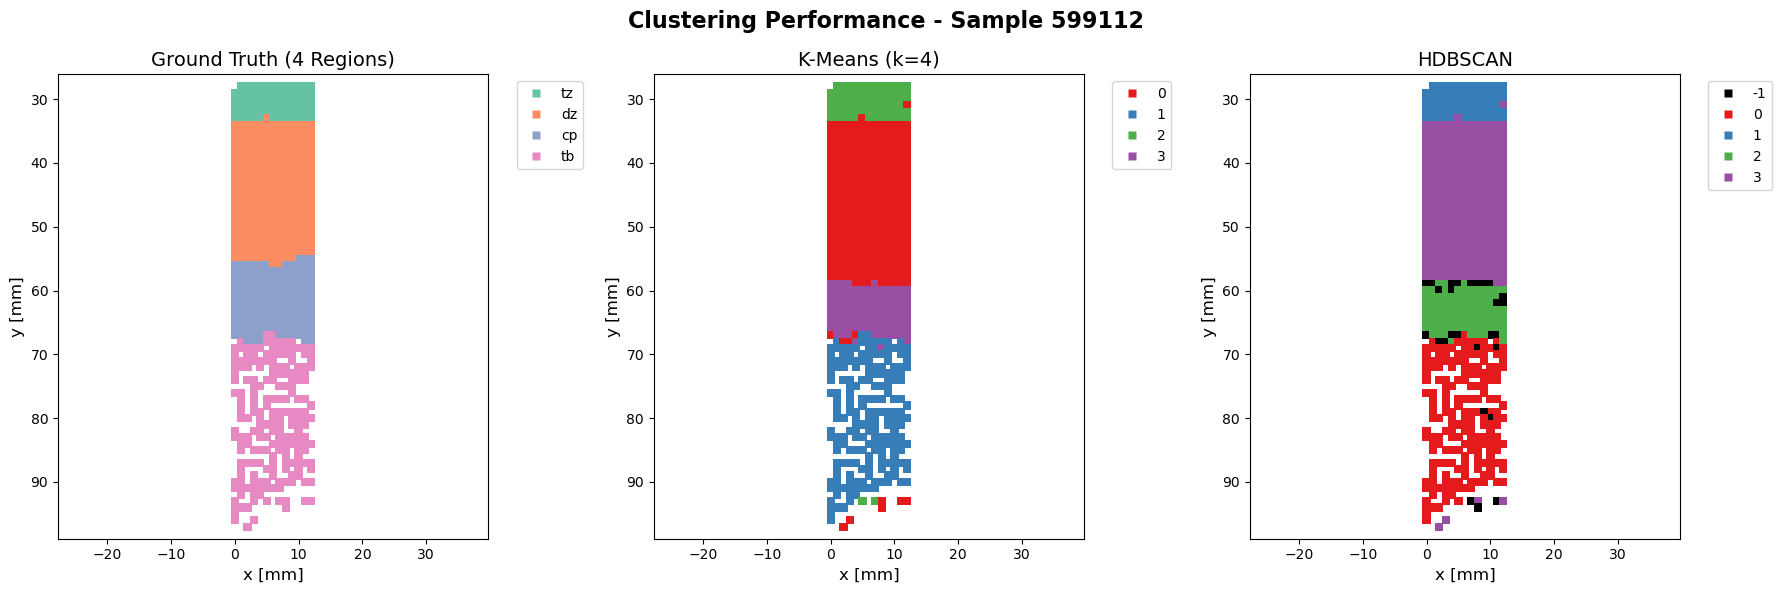

==== METRICS FOR SAMPLE 599118 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.689
Normalized Mutual Info (NMI): 0.605
Homogeneity:                  0.546
Completeness:                 0.678
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.756
Normalized Mutual Info (NMI): 0.731
Homogeneity:                  0.841
Completeness:                 0.646
Noise Percentage:             24.0%



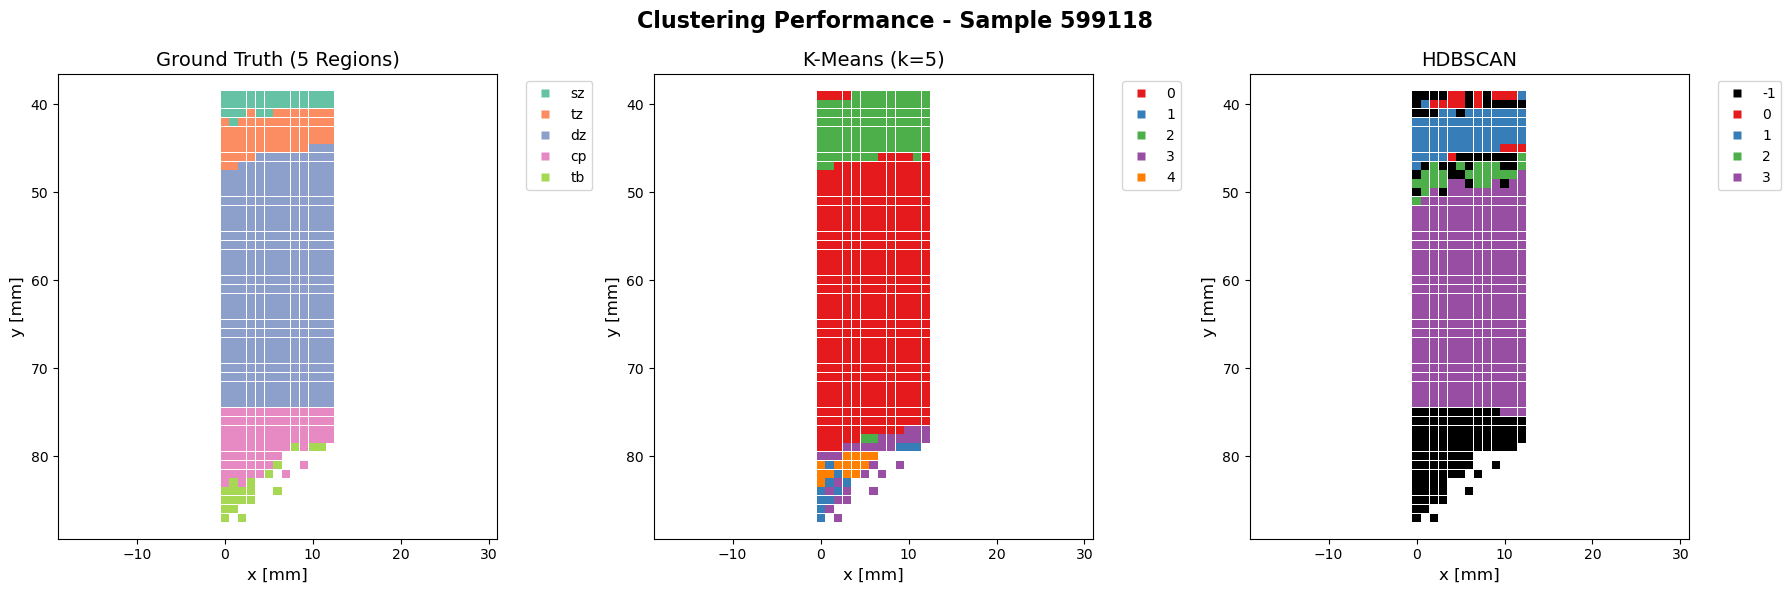

==== METRICS FOR SAMPLE 599124 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.726
Normalized Mutual Info (NMI): 0.743
Homogeneity:                  0.715
Completeness:                 0.773
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.898
Normalized Mutual Info (NMI): 0.866
Homogeneity:                  0.867
Completeness:                 0.865
Noise Percentage:             11.2%



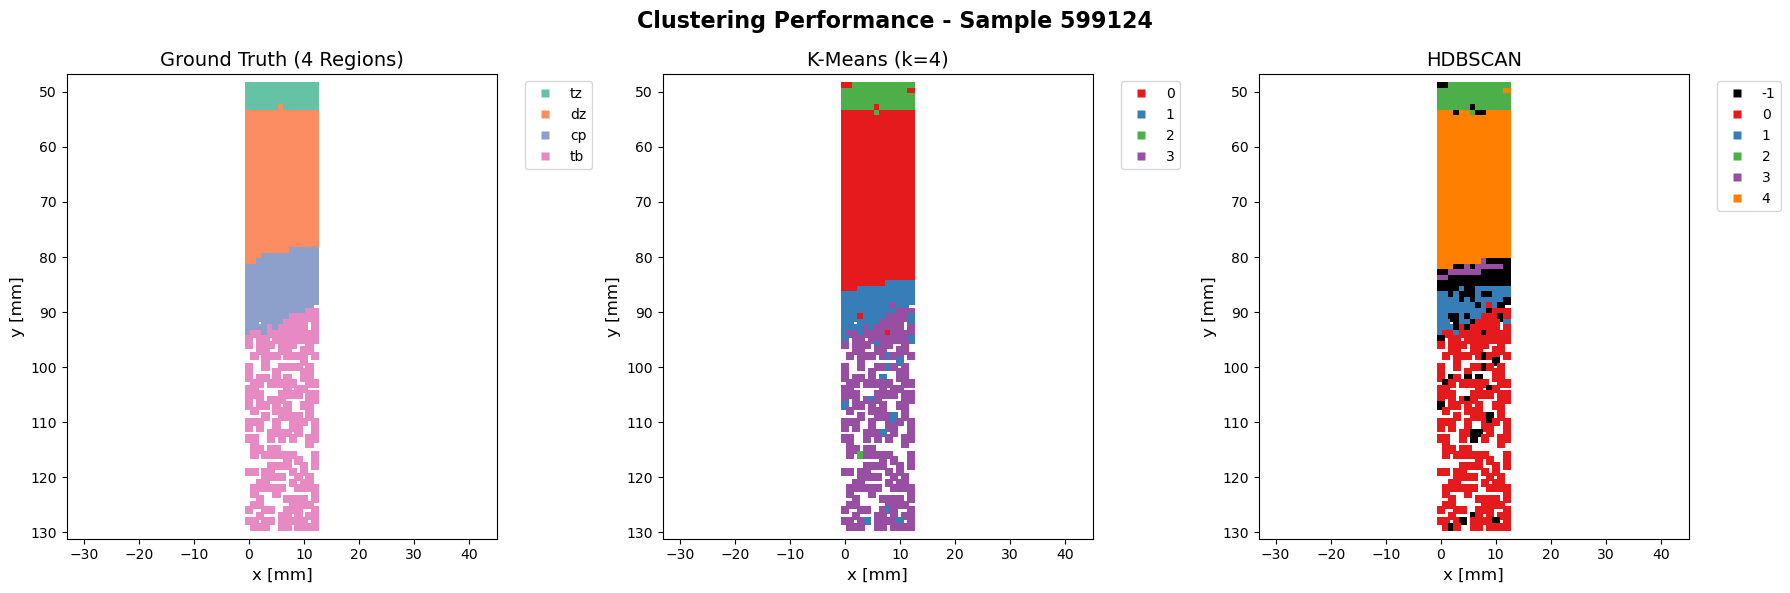

==== METRICS FOR SAMPLE 599130 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.809
Normalized Mutual Info (NMI): 0.777
Homogeneity:                  0.761
Completeness:                 0.794
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.860
Normalized Mutual Info (NMI): 0.834
Homogeneity:                  0.803
Completeness:                 0.867
Noise Percentage:             4.1%



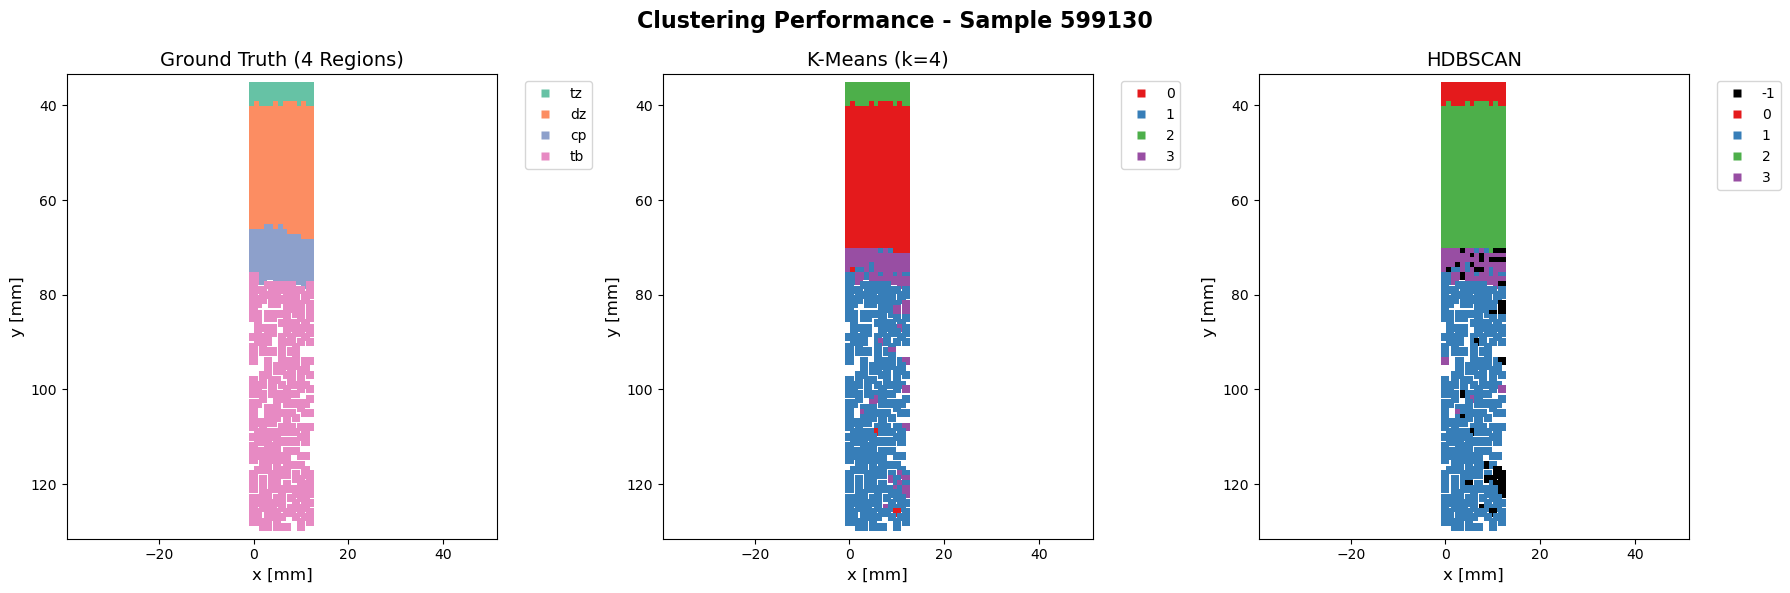

==== METRICS FOR SAMPLE 599134 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.705
Normalized Mutual Info (NMI): 0.761
Homogeneity:                  0.821
Completeness:                 0.709
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.939
Normalized Mutual Info (NMI): 0.891
Homogeneity:                  0.862
Completeness:                 0.922
Noise Percentage:             3.7%



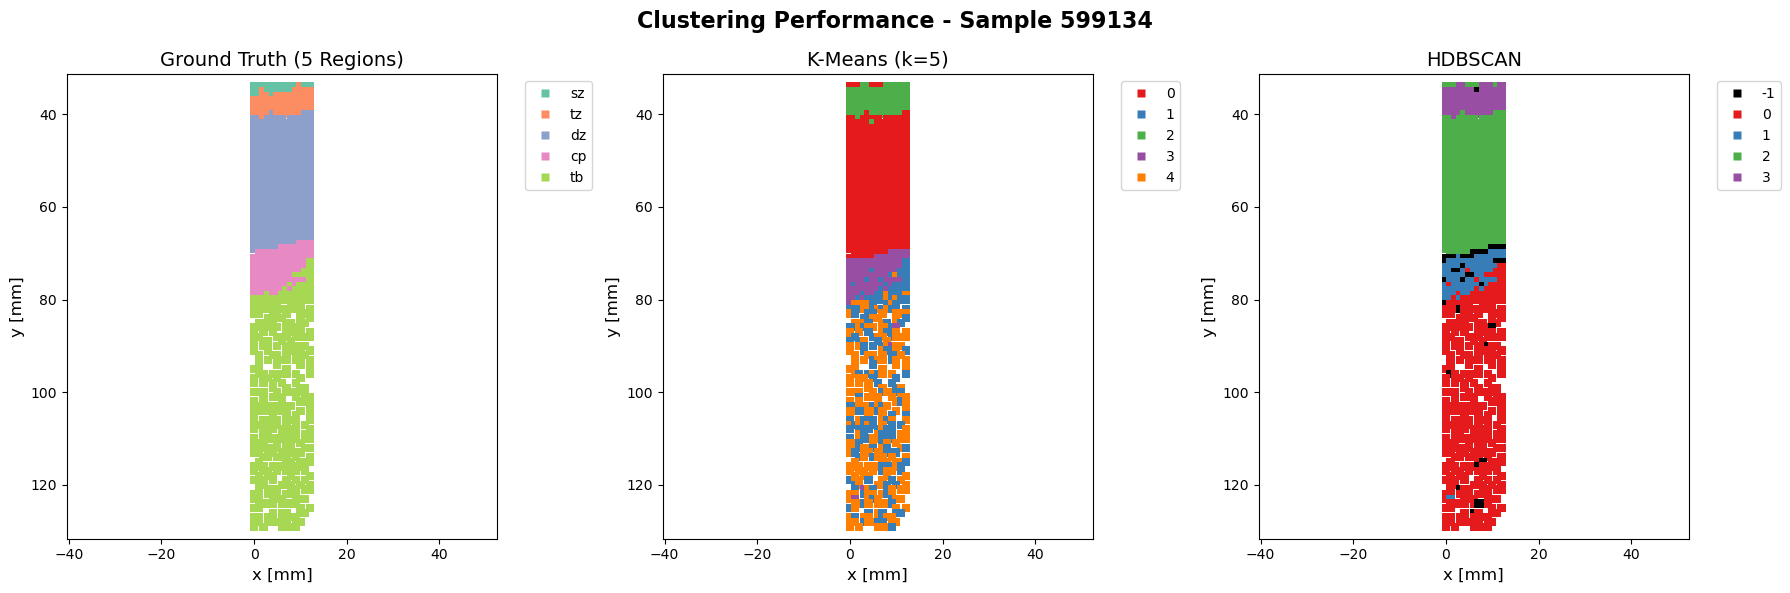

==== METRICS FOR SAMPLE 599113 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.697
Normalized Mutual Info (NMI): 0.742
Homogeneity:                  0.721
Completeness:                 0.764
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.751
Normalized Mutual Info (NMI): 0.799
Homogeneity:                  0.774
Completeness:                 0.825
Noise Percentage:             7.2%



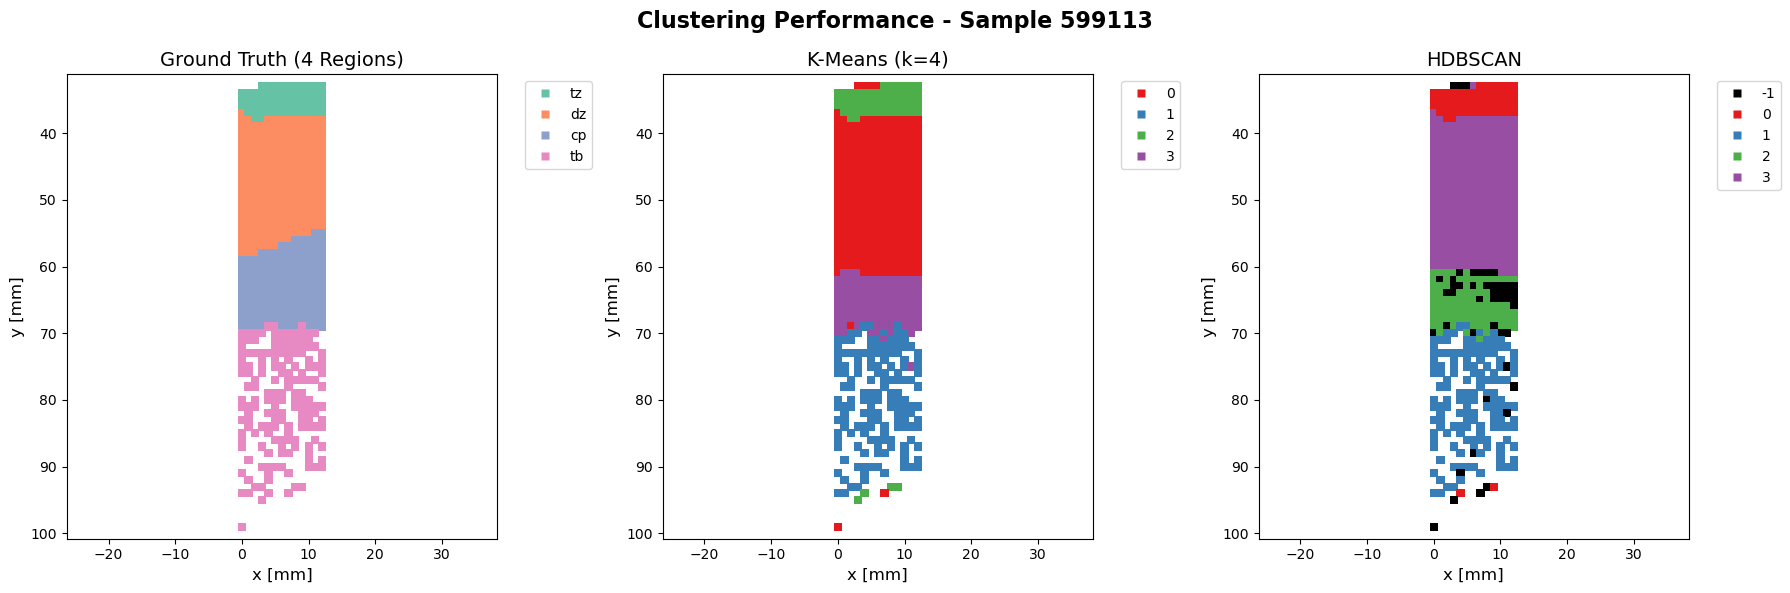

==== METRICS FOR SAMPLE 599119 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.674
Normalized Mutual Info (NMI): 0.663
Homogeneity:                  0.600
Completeness:                 0.742
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.696
Normalized Mutual Info (NMI): 0.661
Homogeneity:                  0.521
Completeness:                 0.902
Noise Percentage:             16.2%



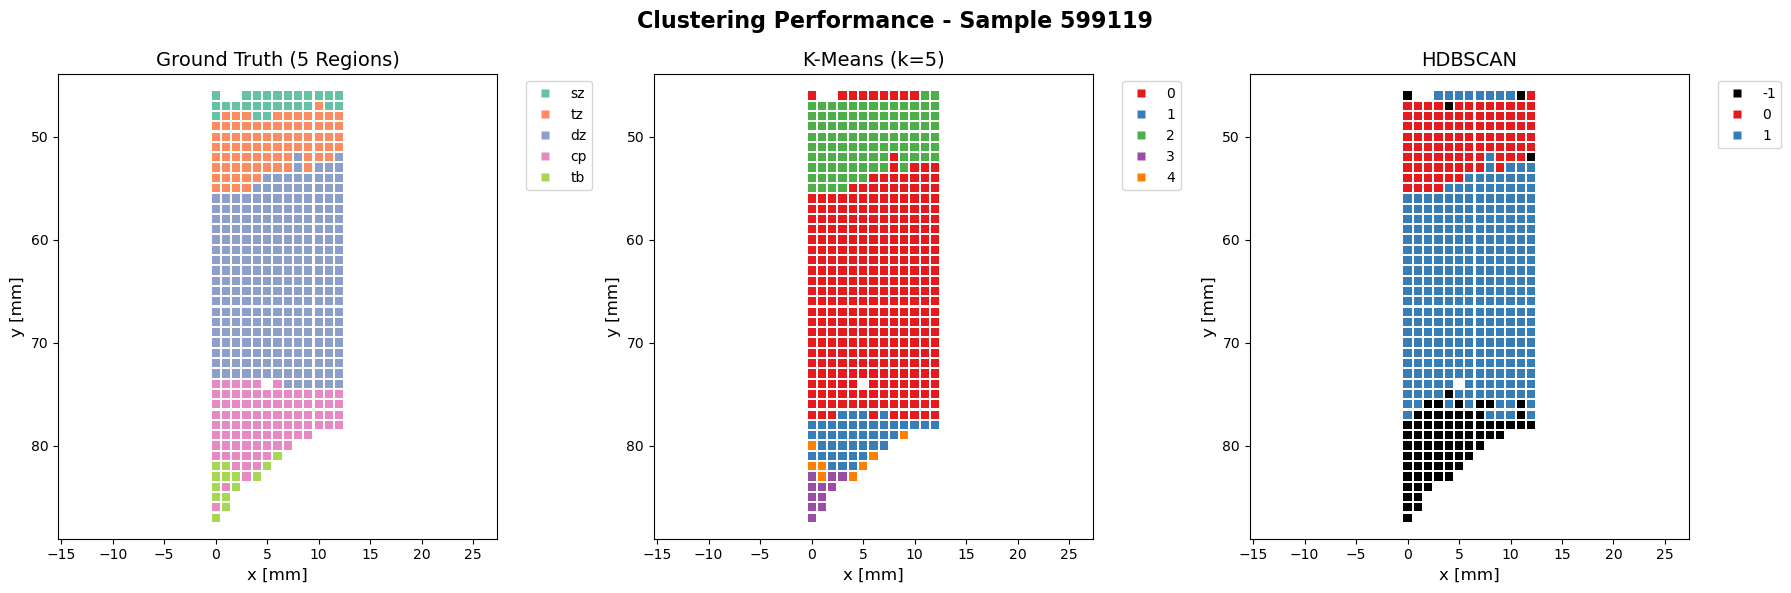

==== METRICS FOR SAMPLE 599125 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.686
Normalized Mutual Info (NMI): 0.765
Homogeneity:                  0.731
Completeness:                 0.802
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.694
Normalized Mutual Info (NMI): 0.791
Homogeneity:                  0.746
Completeness:                 0.842
Noise Percentage:             3.7%



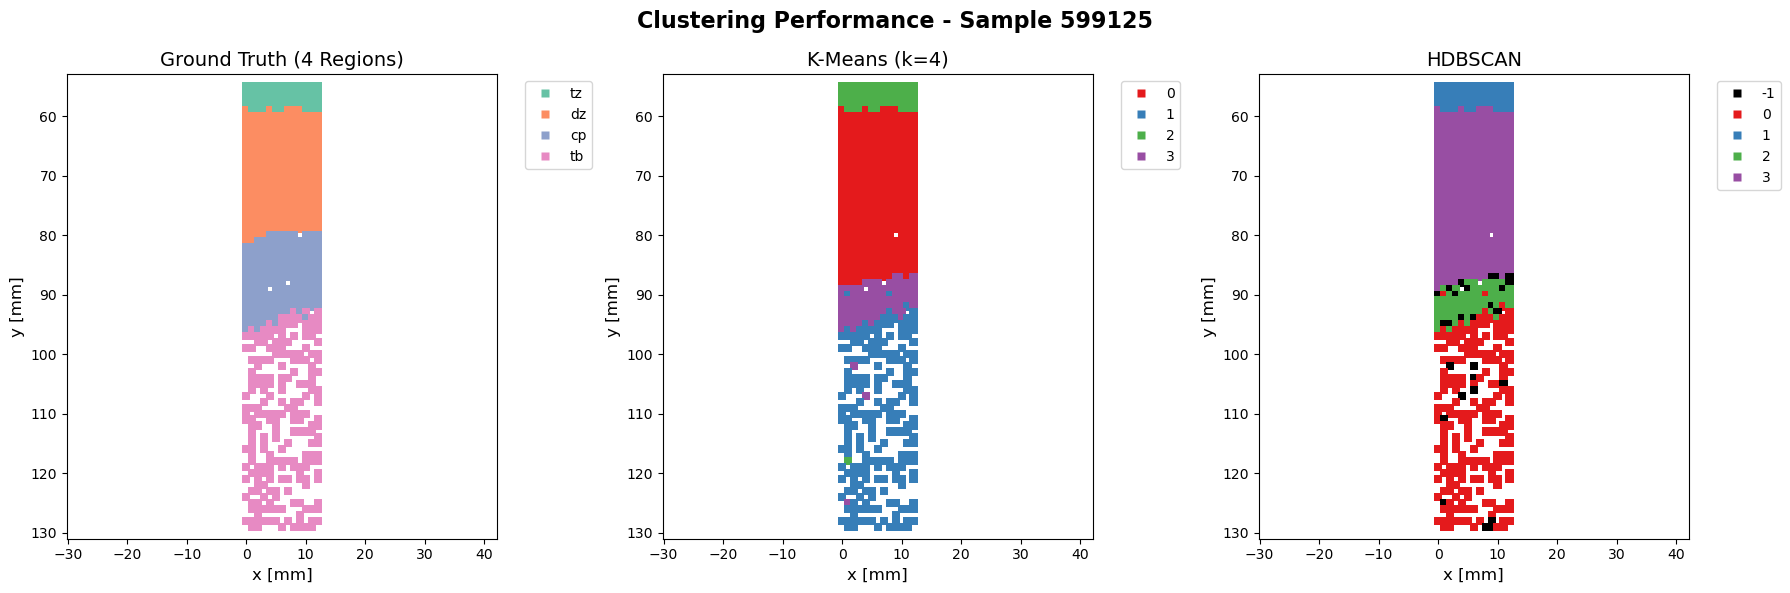

==== METRICS FOR SAMPLE 599131 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.754
Normalized Mutual Info (NMI): 0.757
Homogeneity:                  0.766
Completeness:                 0.747
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.894
Normalized Mutual Info (NMI): 0.856
Homogeneity:                  0.834
Completeness:                 0.879
Noise Percentage:             3.7%



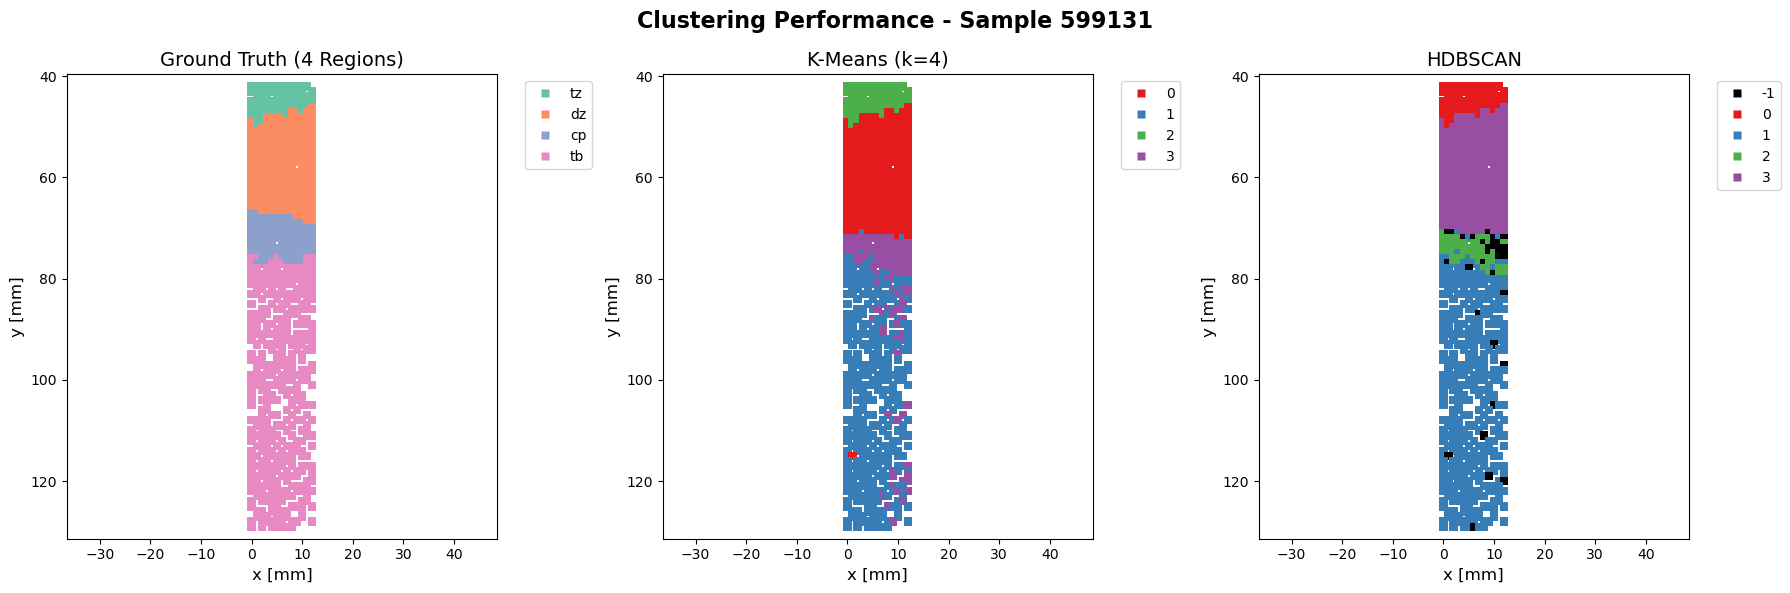

==== METRICS FOR SAMPLE 599135 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.706
Normalized Mutual Info (NMI): 0.767
Homogeneity:                  0.843
Completeness:                 0.704
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.943
Normalized Mutual Info (NMI): 0.897
Homogeneity:                  0.875
Completeness:                 0.921
Noise Percentage:             5.2%



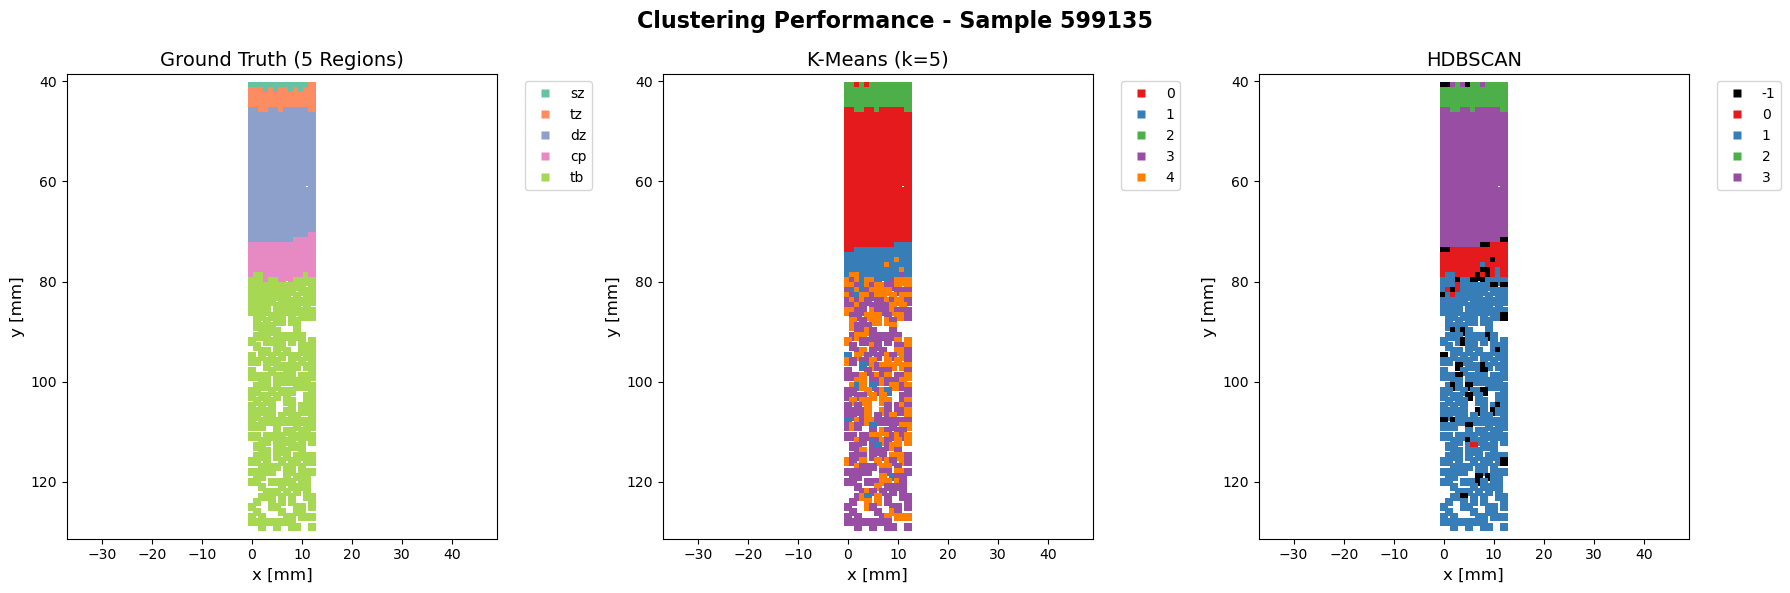

==== METRICS FOR SAMPLE 599114 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.681
Normalized Mutual Info (NMI): 0.680
Homogeneity:                  0.694
Completeness:                 0.666
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.859
Normalized Mutual Info (NMI): 0.828
Homogeneity:                  0.748
Completeness:                 0.928
Noise Percentage:             1.7%



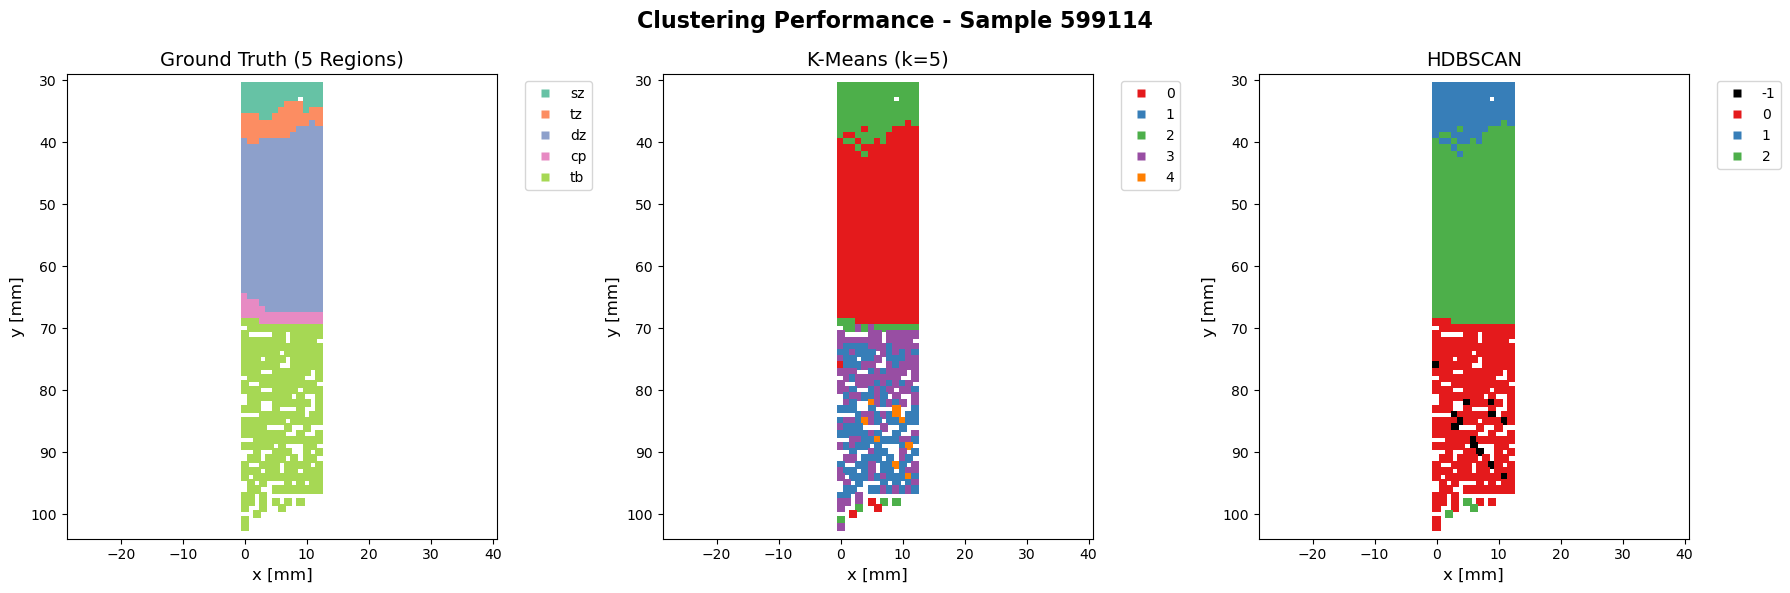

==== METRICS FOR SAMPLE 599120 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.634
Normalized Mutual Info (NMI): 0.673
Homogeneity:                  0.677
Completeness:                 0.669
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.772
Normalized Mutual Info (NMI): 0.777
Homogeneity:                  0.682
Completeness:                 0.901
Noise Percentage:             1.7%



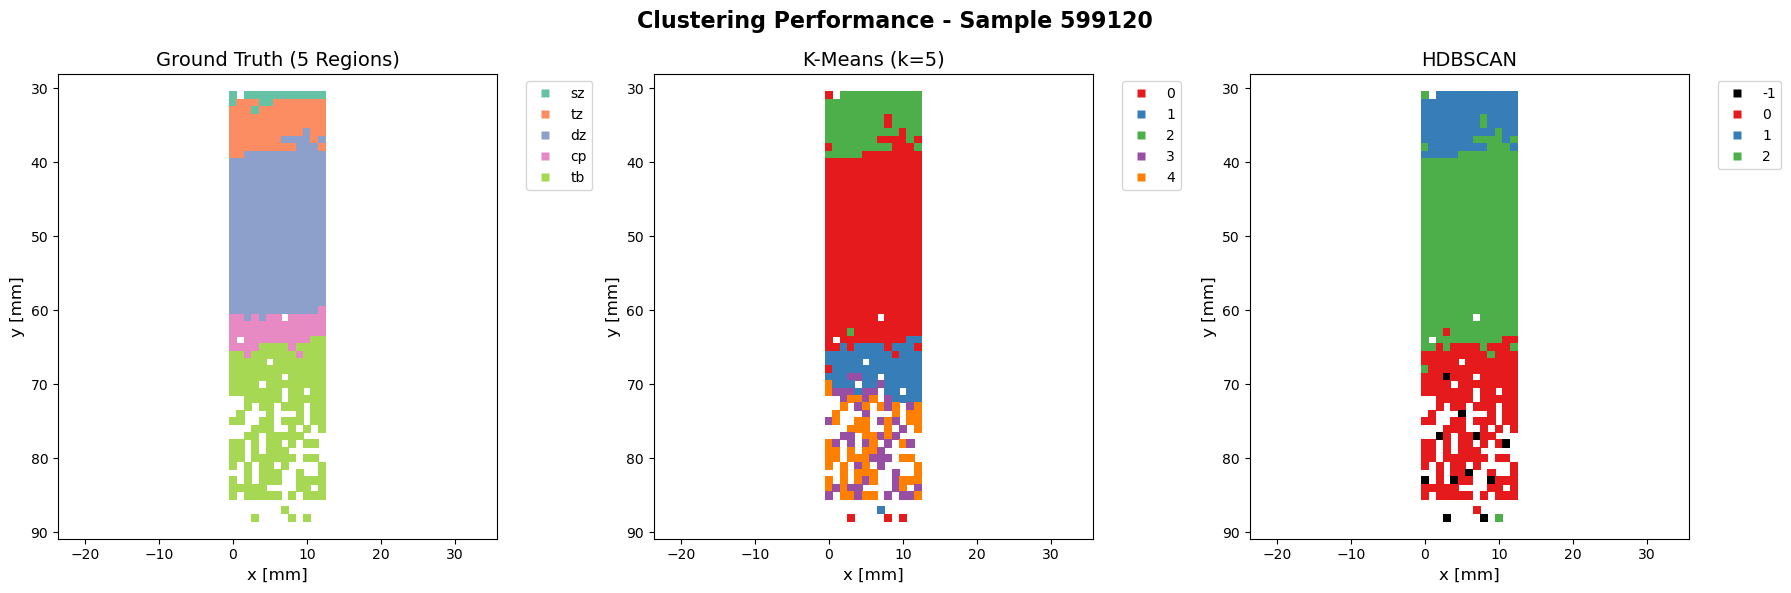

==== METRICS FOR SAMPLE 599126 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.596
Normalized Mutual Info (NMI): 0.709
Homogeneity:                  0.748
Completeness:                 0.673
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.816
Normalized Mutual Info (NMI): 0.797
Homogeneity:                  0.907
Completeness:                 0.711
Noise Percentage:             28.7%



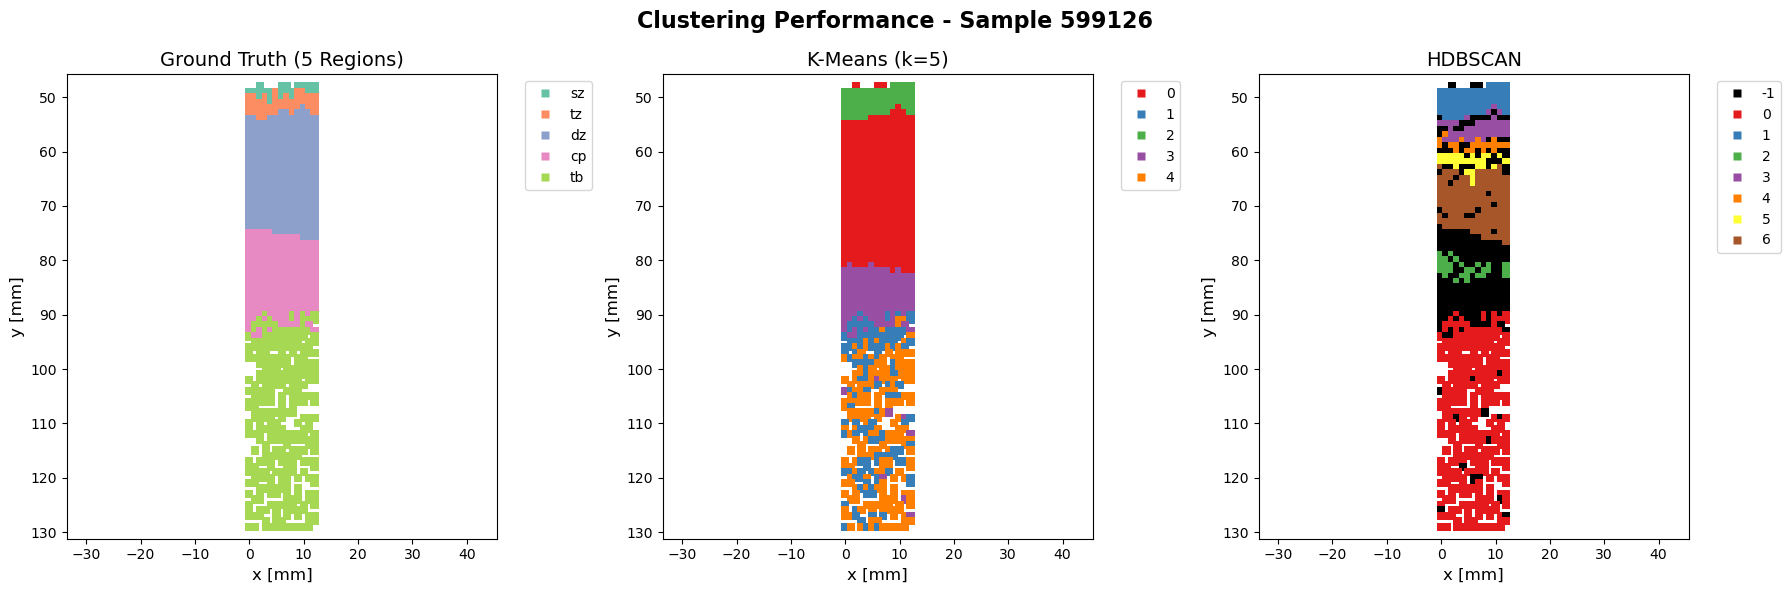

==== METRICS FOR SAMPLE 599132 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.639
Normalized Mutual Info (NMI): 0.724
Homogeneity:                  0.766
Completeness:                 0.686
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.908
Normalized Mutual Info (NMI): 0.850
Homogeneity:                  0.844
Completeness:                 0.856
Noise Percentage:             9.8%



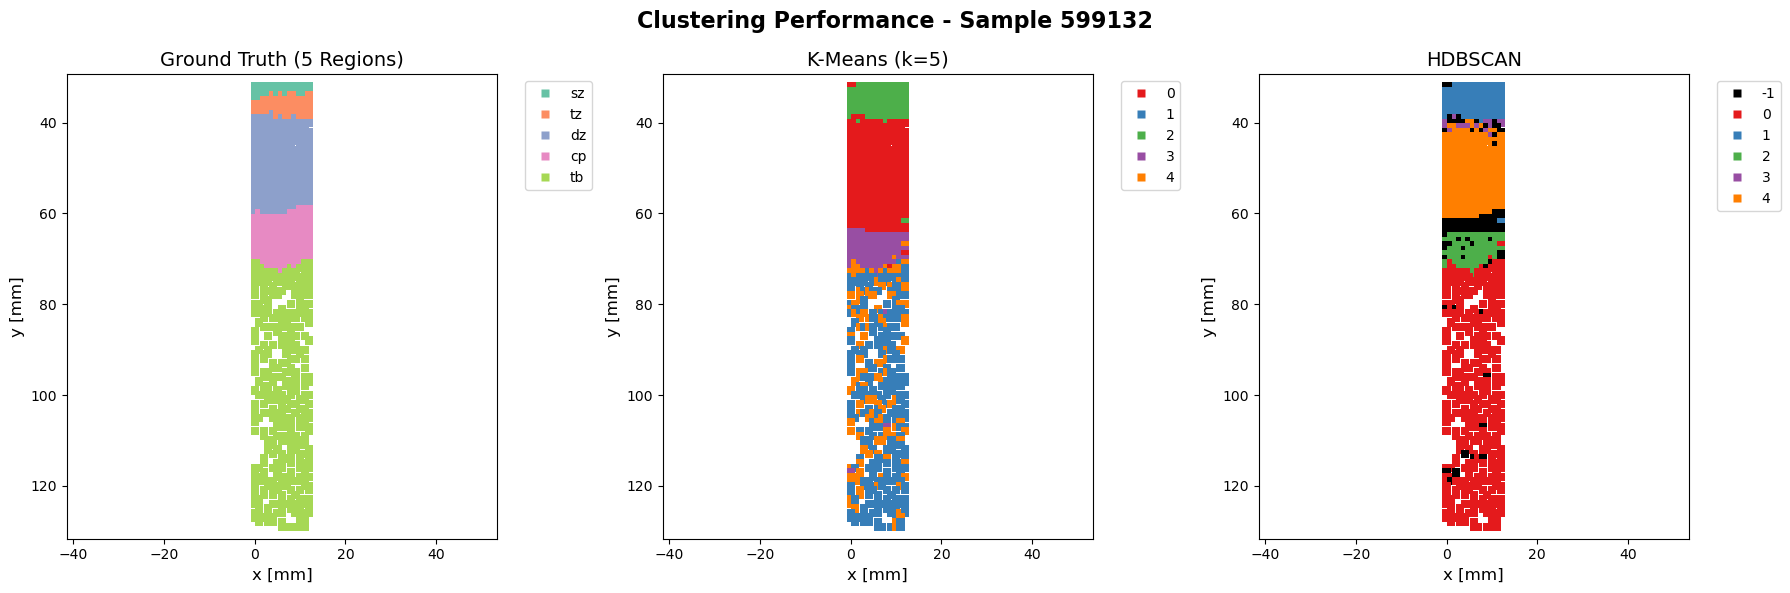

==== METRICS FOR SAMPLE 599143 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.627
Normalized Mutual Info (NMI): 0.691
Homogeneity:                  0.663
Completeness:                 0.721
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.641
Normalized Mutual Info (NMI): 0.722
Homogeneity:                  0.686
Completeness:                 0.761
Noise Percentage:             4.3%



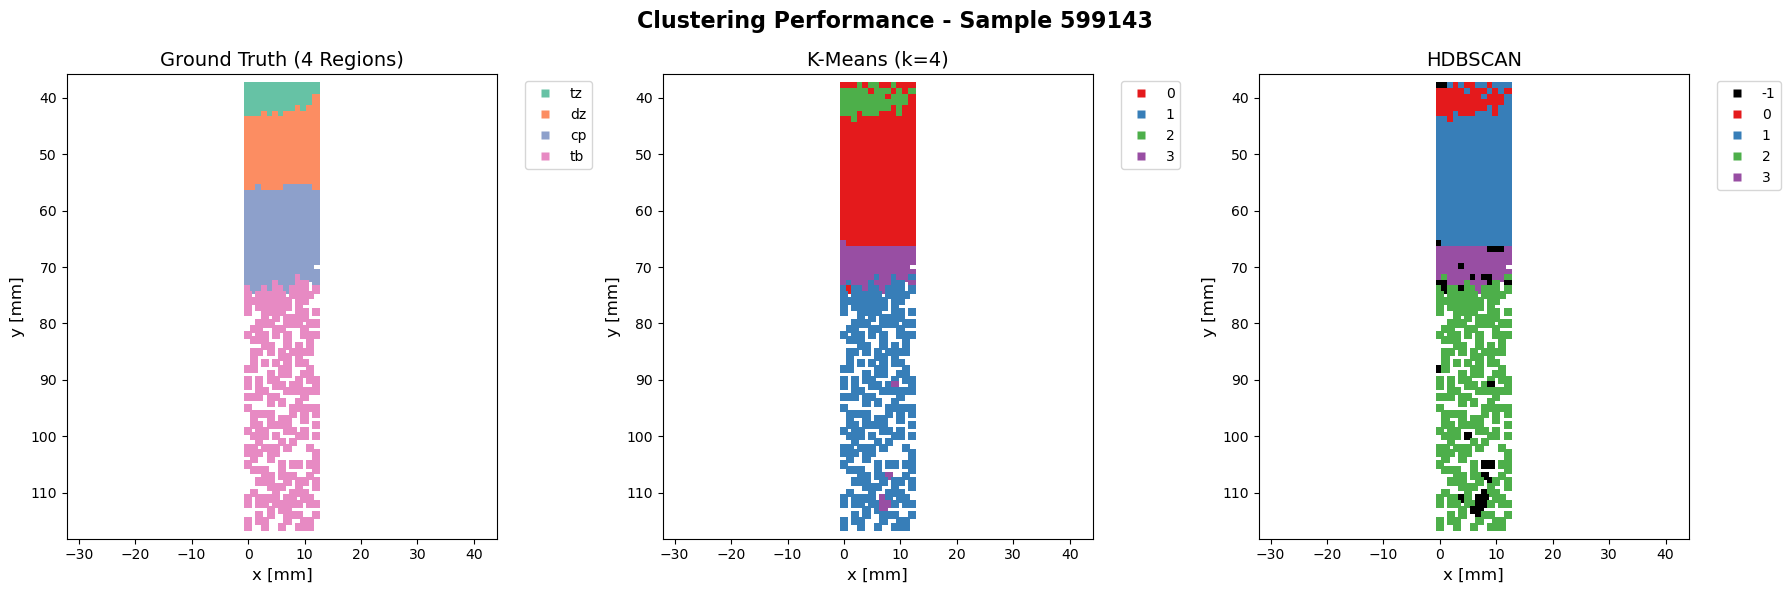

==== METRICS FOR SAMPLE 599115 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.576
Normalized Mutual Info (NMI): 0.630
Homogeneity:                  0.625
Completeness:                 0.635
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.727
Normalized Mutual Info (NMI): 0.749
Homogeneity:                  0.699
Completeness:                 0.807
Noise Percentage:             20.6%



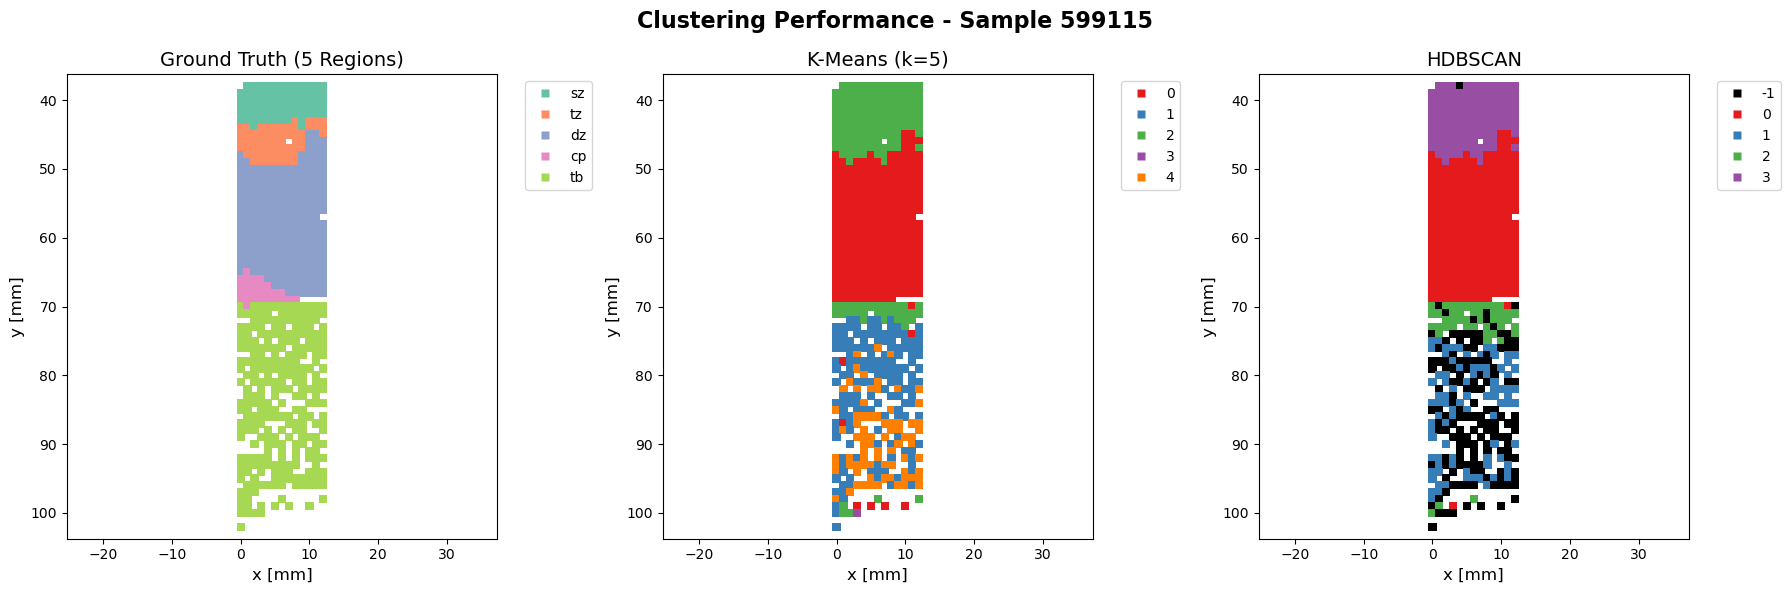

==== METRICS FOR SAMPLE 599121 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.587
Normalized Mutual Info (NMI): 0.692
Homogeneity:                  0.685
Completeness:                 0.700
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.762
Normalized Mutual Info (NMI): 0.805
Homogeneity:                  0.696
Completeness:                 0.957
Noise Percentage:             2.2%



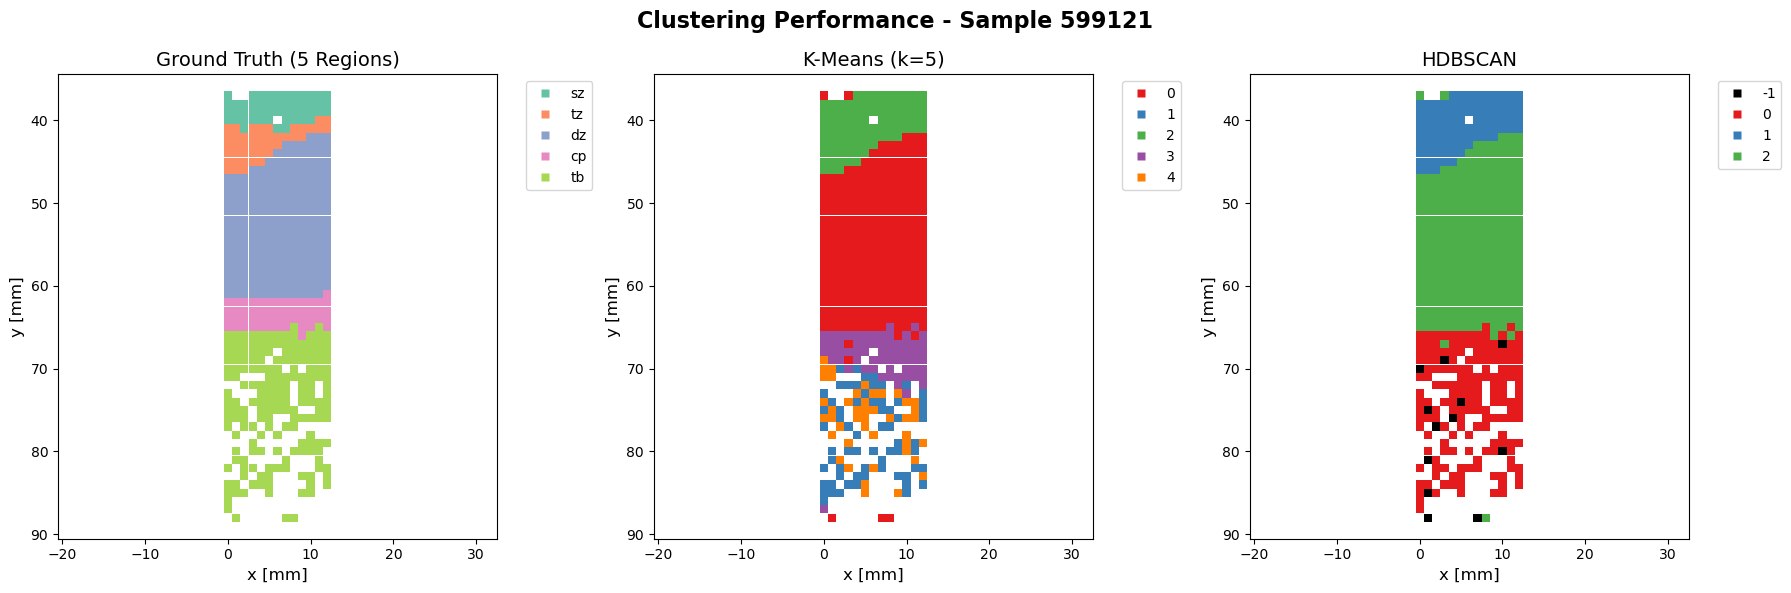

==== METRICS FOR SAMPLE 599127 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.535
Normalized Mutual Info (NMI): 0.682
Homogeneity:                  0.719
Completeness:                 0.648
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.884
Normalized Mutual Info (NMI): 0.832
Homogeneity:                  0.791
Completeness:                 0.876
Noise Percentage:             20.4%



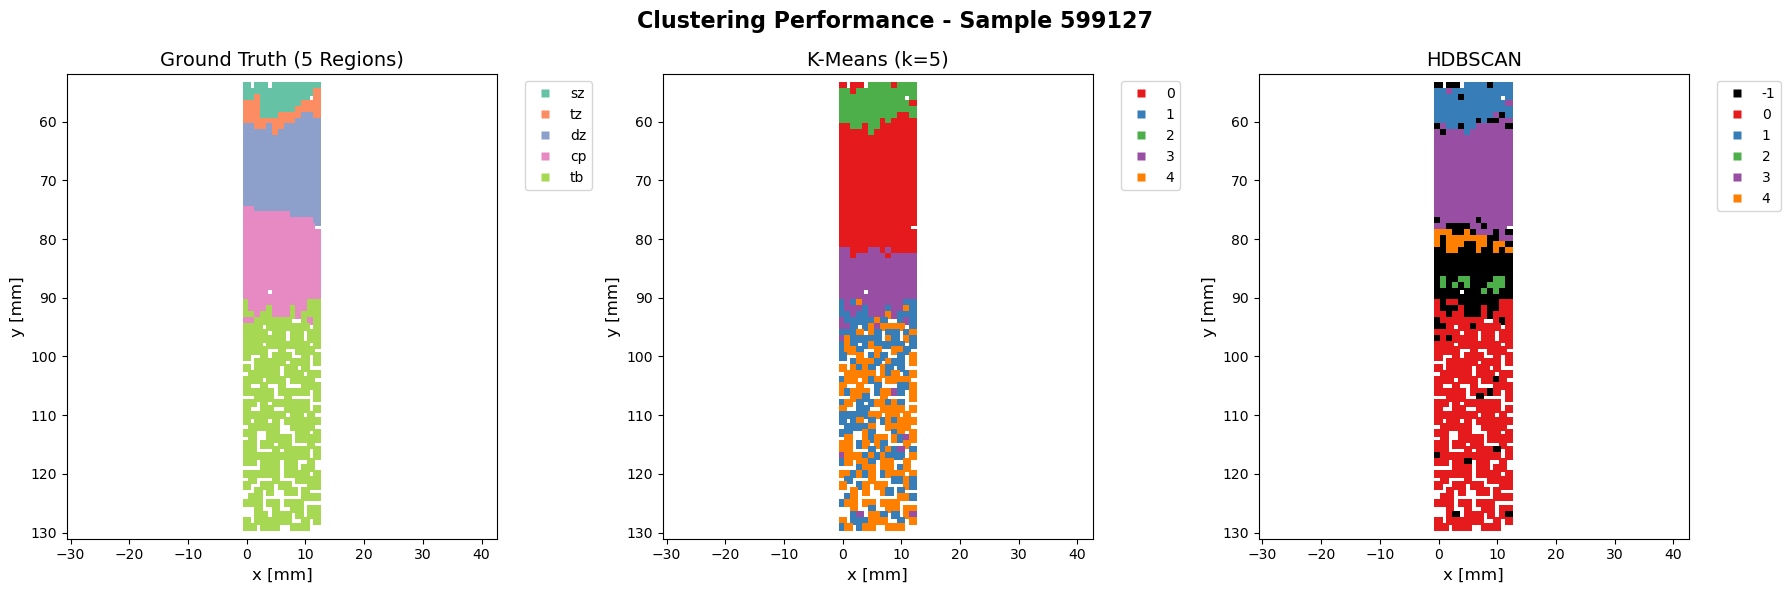

==== METRICS FOR SAMPLE 599133 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.568
Normalized Mutual Info (NMI): 0.711
Homogeneity:                  0.766
Completeness:                 0.664
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.862
Normalized Mutual Info (NMI): 0.835
Homogeneity:                  0.793
Completeness:                 0.882
Noise Percentage:             4.9%



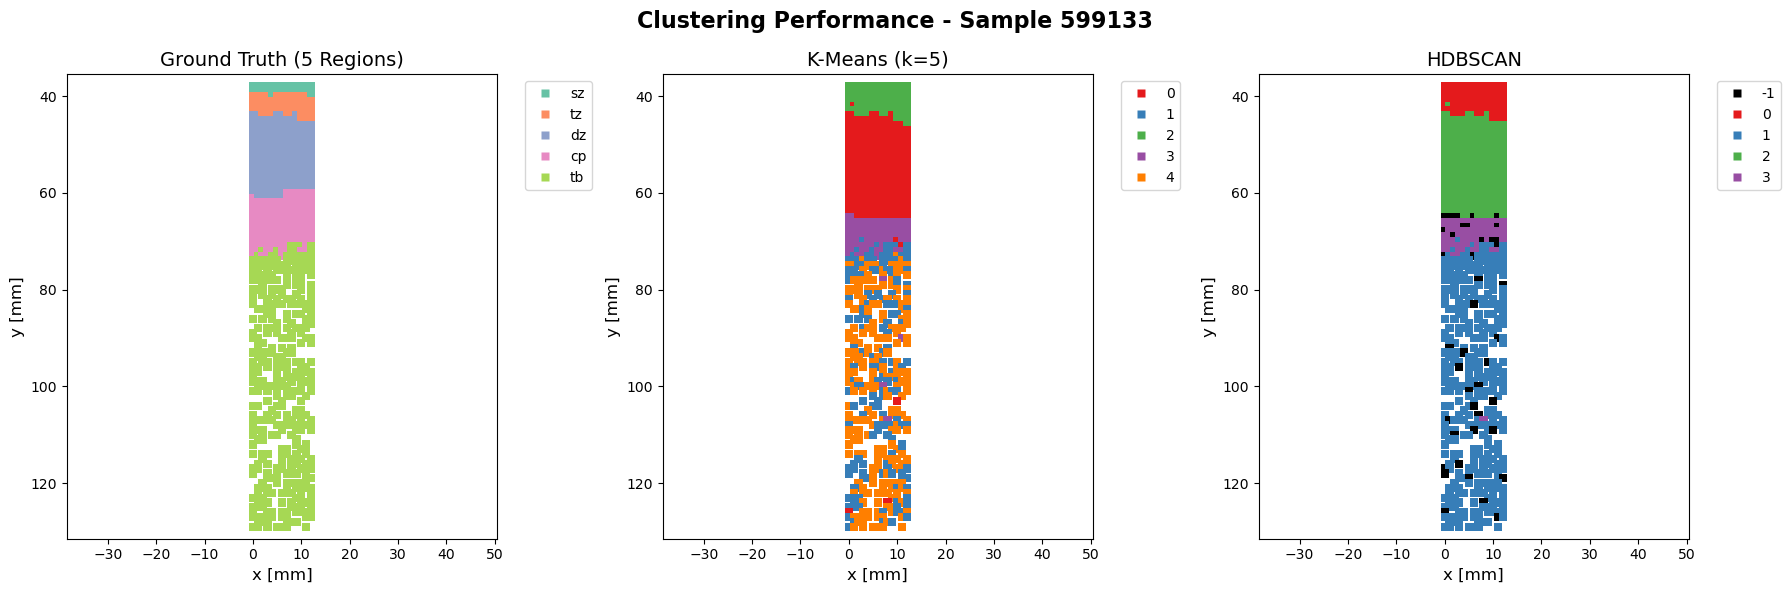

==== METRICS FOR SAMPLE 599144 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.705
Normalized Mutual Info (NMI): 0.709
Homogeneity:                  0.687
Completeness:                 0.733
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.745
Normalized Mutual Info (NMI): 0.771
Homogeneity:                  0.735
Completeness:                 0.810
Noise Percentage:             6.1%



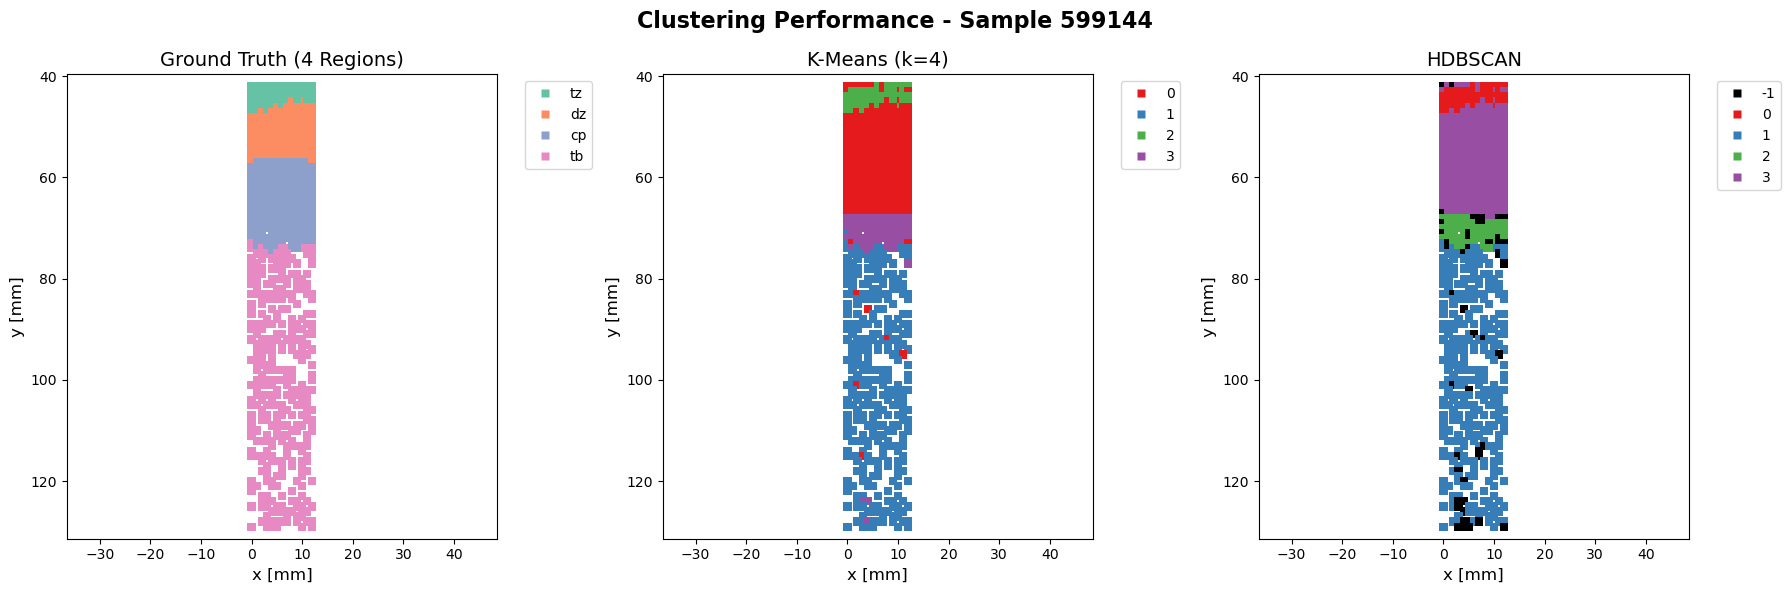

==== METRICS FOR SAMPLE 599116 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.541
Normalized Mutual Info (NMI): 0.582
Homogeneity:                  0.577
Completeness:                 0.587
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.850
Normalized Mutual Info (NMI): 0.813
Homogeneity:                  0.826
Completeness:                 0.801
Noise Percentage:             19.7%



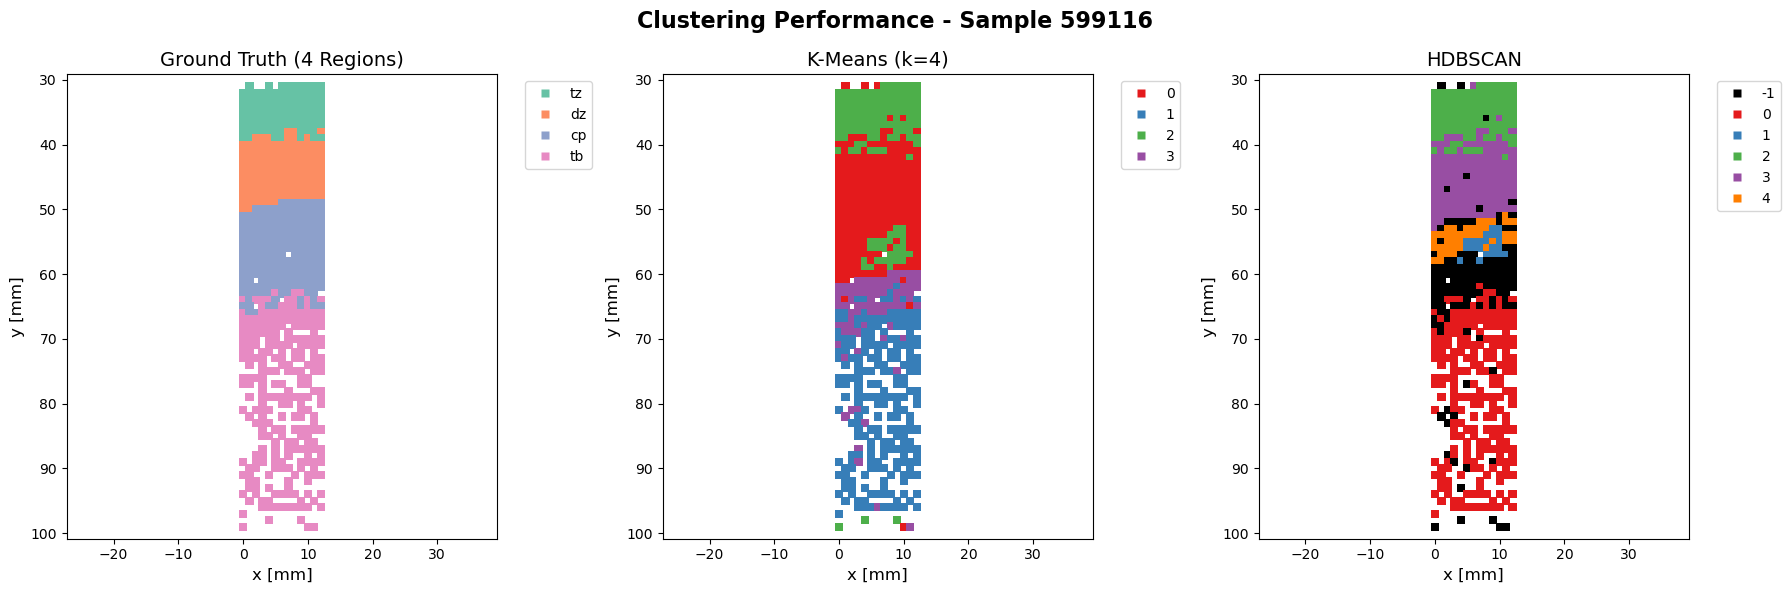

==== METRICS FOR SAMPLE 599122 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.804
Normalized Mutual Info (NMI): 0.749
Homogeneity:                  0.781
Completeness:                 0.720
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.823
Normalized Mutual Info (NMI): 0.800
Homogeneity:                  0.749
Completeness:                 0.858
Noise Percentage:             5.3%



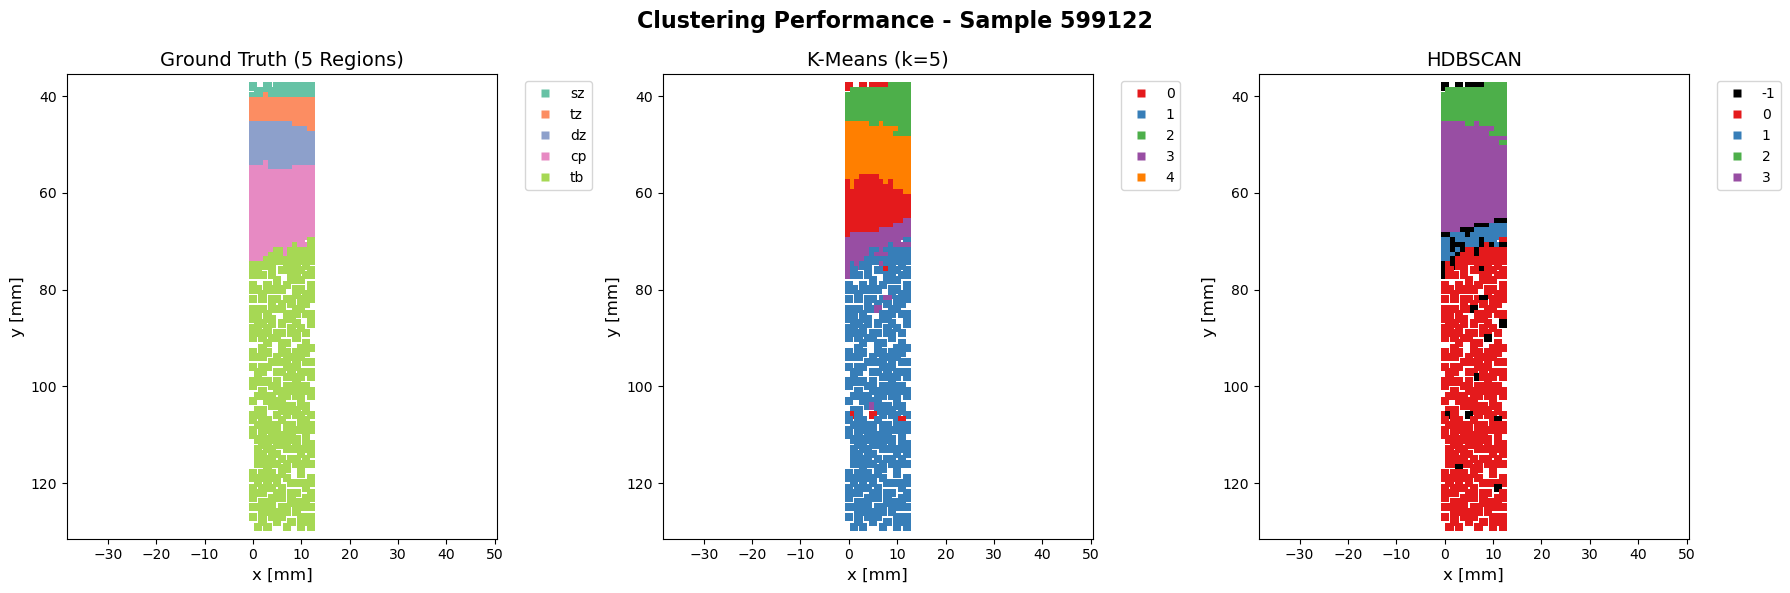

==== METRICS FOR SAMPLE 599128 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.267
Normalized Mutual Info (NMI): 0.510
Homogeneity:                  0.593
Completeness:                 0.448
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.784
Normalized Mutual Info (NMI): 0.755
Homogeneity:                  0.648
Completeness:                 0.905
Noise Percentage:             17.2%



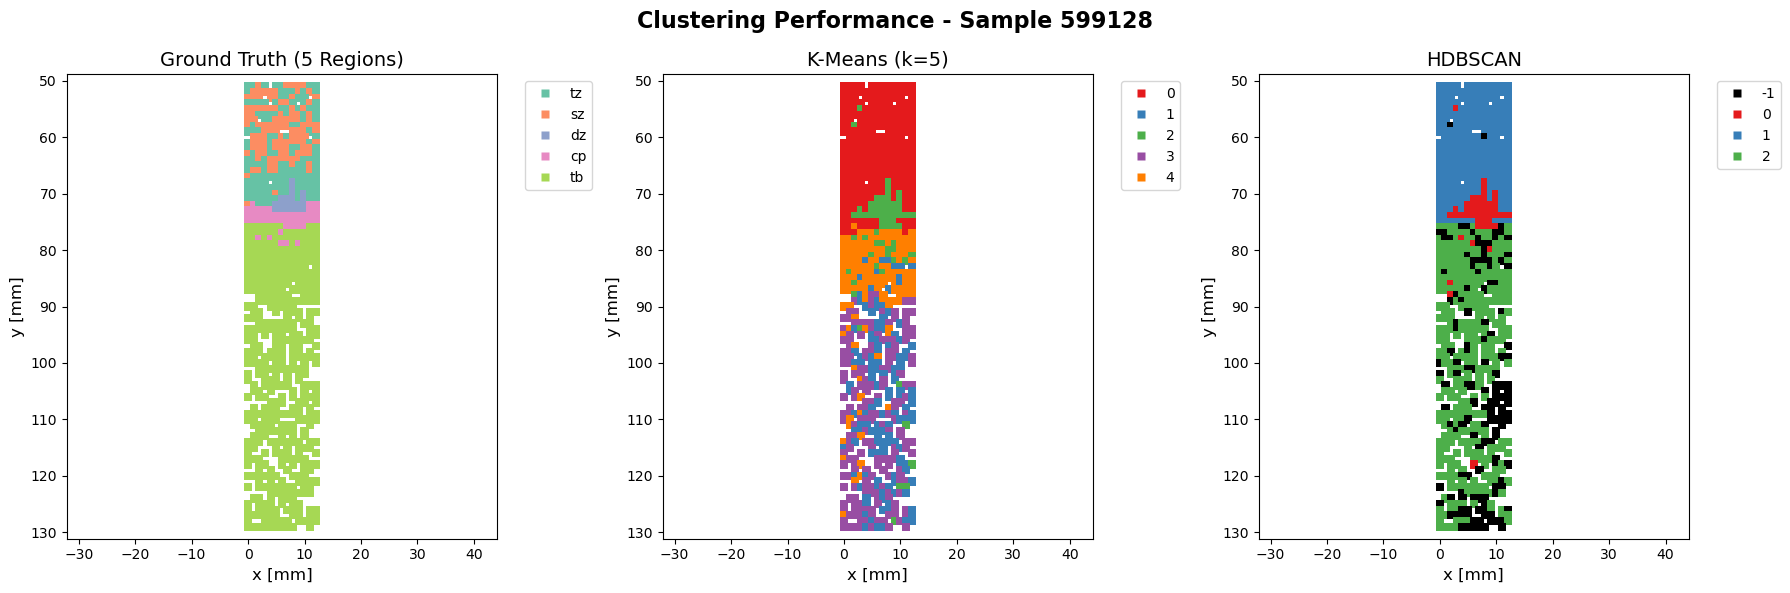

==== METRICS FOR SAMPLE 599145 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.341
Normalized Mutual Info (NMI): 0.425
Homogeneity:                  0.405
Completeness:                 0.447
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.667
Normalized Mutual Info (NMI): 0.619
Homogeneity:                  0.552
Completeness:                 0.703
Noise Percentage:             7.7%



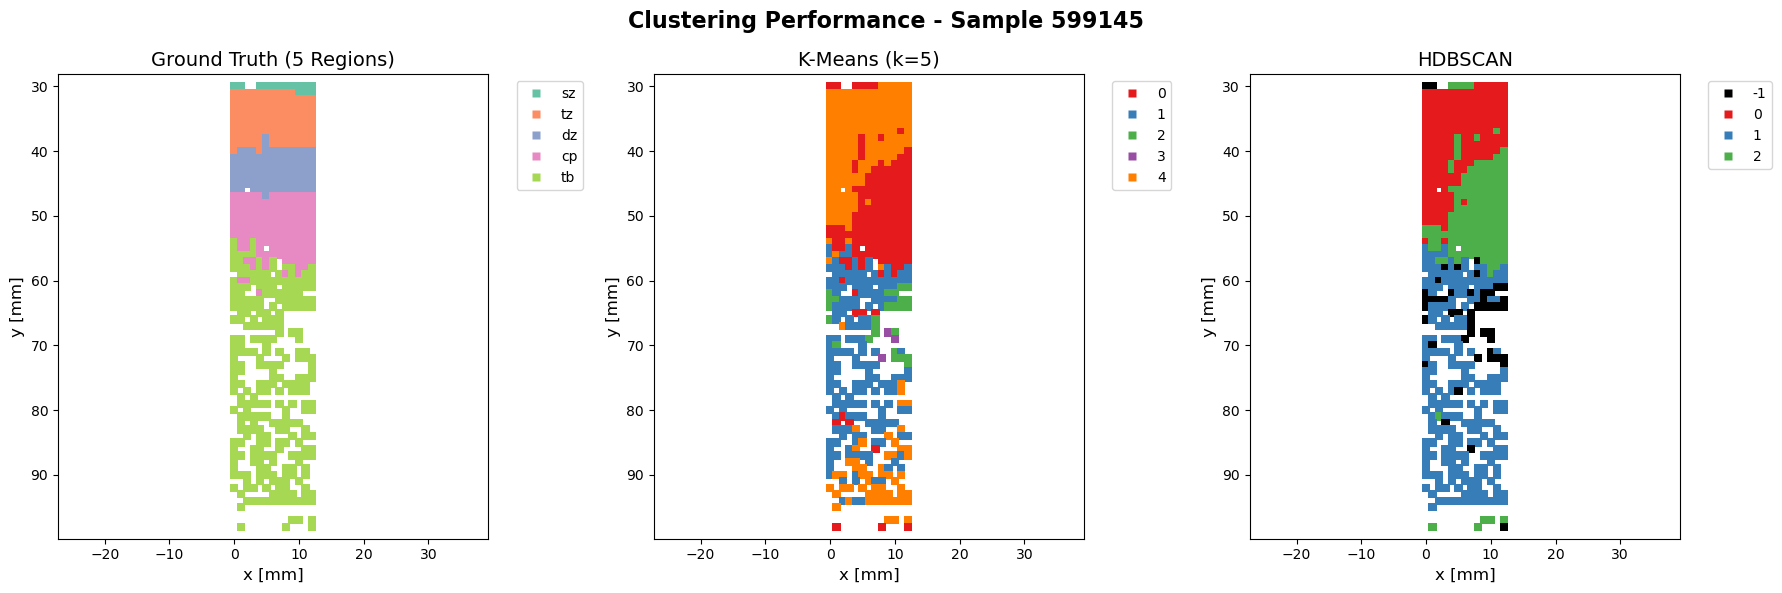

==== METRICS FOR SAMPLE 599147 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.434
Normalized Mutual Info (NMI): 0.586
Homogeneity:                  0.650
Completeness:                 0.534
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.866
Normalized Mutual Info (NMI): 0.762
Homogeneity:                  0.726
Completeness:                 0.801
Noise Percentage:             8.7%



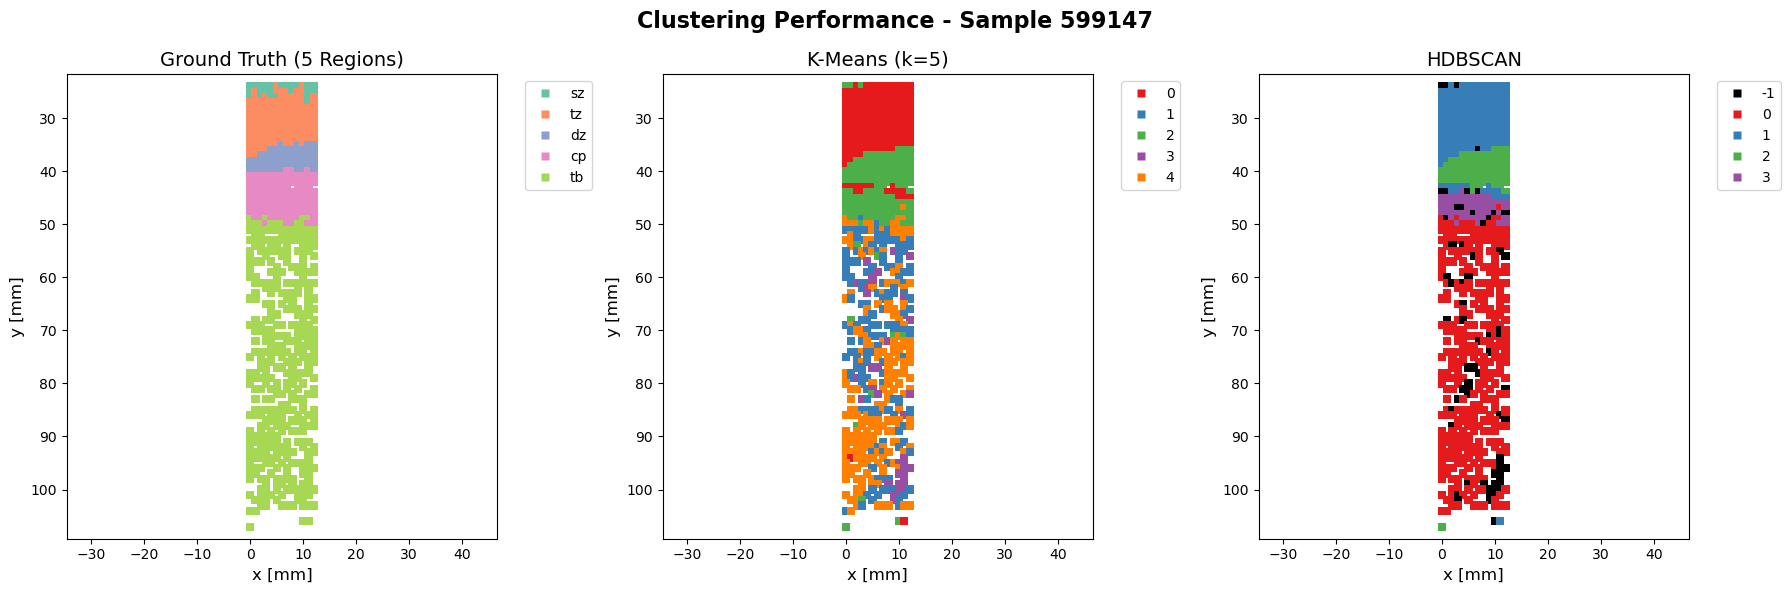

==== METRICS FOR SAMPLE 599117 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.543
Normalized Mutual Info (NMI): 0.574
Homogeneity:                  0.577
Completeness:                 0.572
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.685
Normalized Mutual Info (NMI): 0.746
Homogeneity:                  0.748
Completeness:                 0.744
Noise Percentage:             16.1%



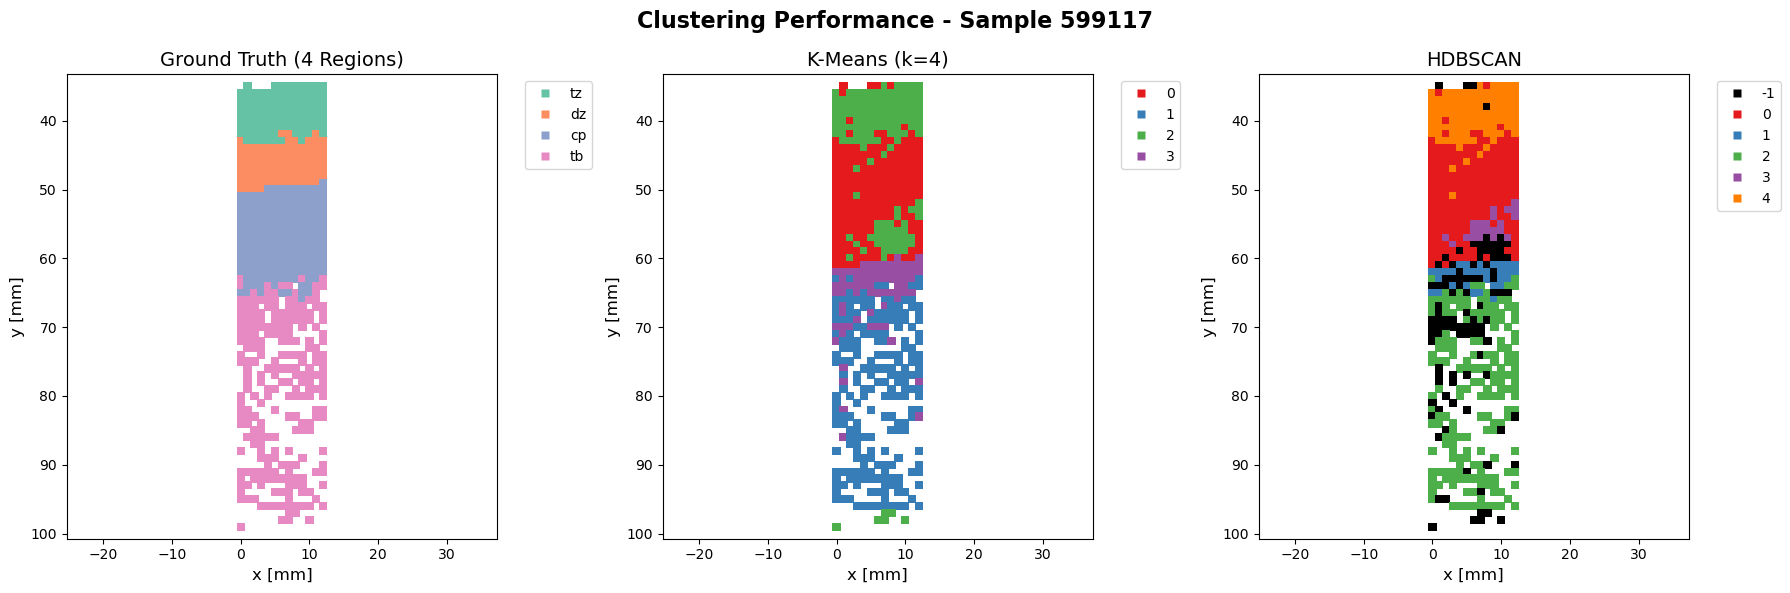

==== METRICS FOR SAMPLE 599123 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.825
Normalized Mutual Info (NMI): 0.773
Homogeneity:                  0.810
Completeness:                 0.740
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.832
Normalized Mutual Info (NMI): 0.798
Homogeneity:                  0.770
Completeness:                 0.828
Noise Percentage:             1.7%



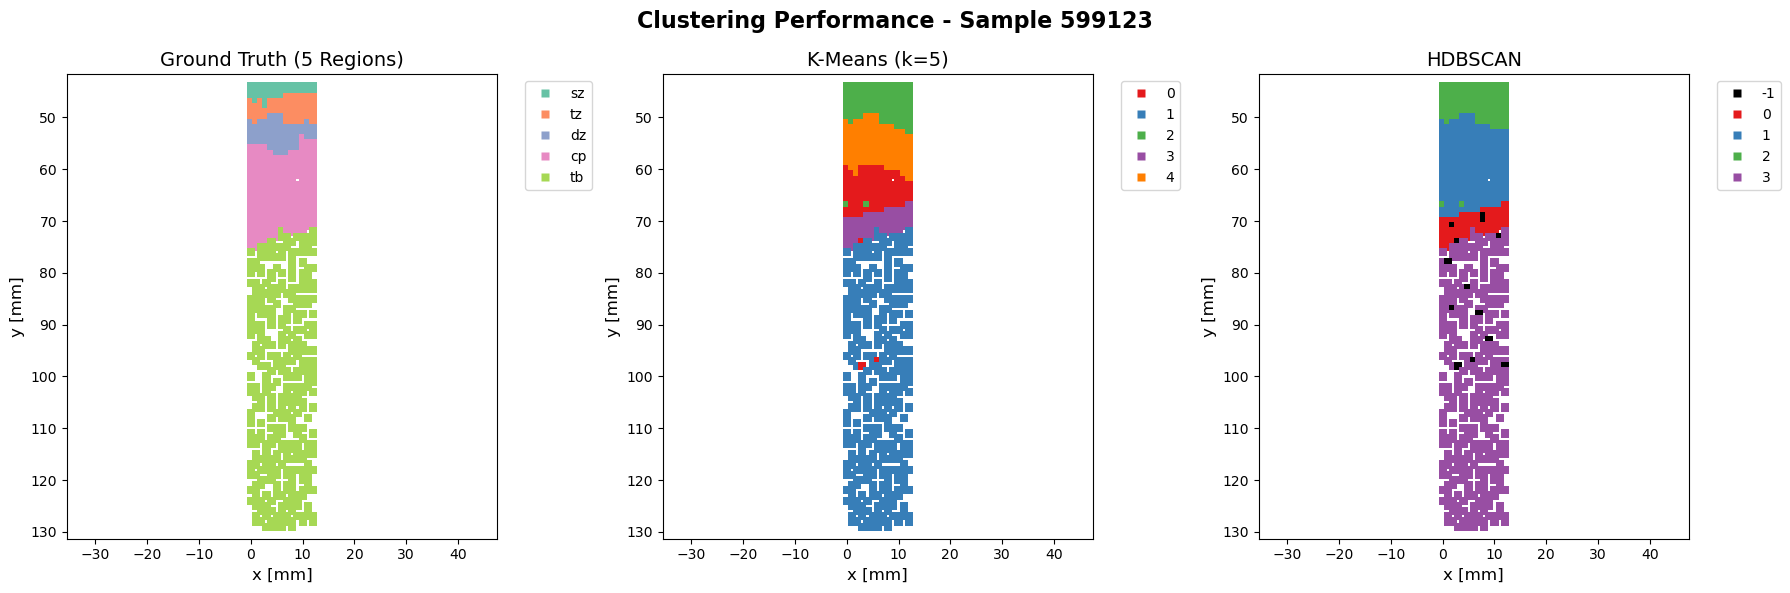

==== METRICS FOR SAMPLE 599129 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.224
Normalized Mutual Info (NMI): 0.439
Homogeneity:                  0.546
Completeness:                 0.367
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.799
Normalized Mutual Info (NMI): 0.740
Homogeneity:                  0.628
Completeness:                 0.902
Noise Percentage:             27.7%



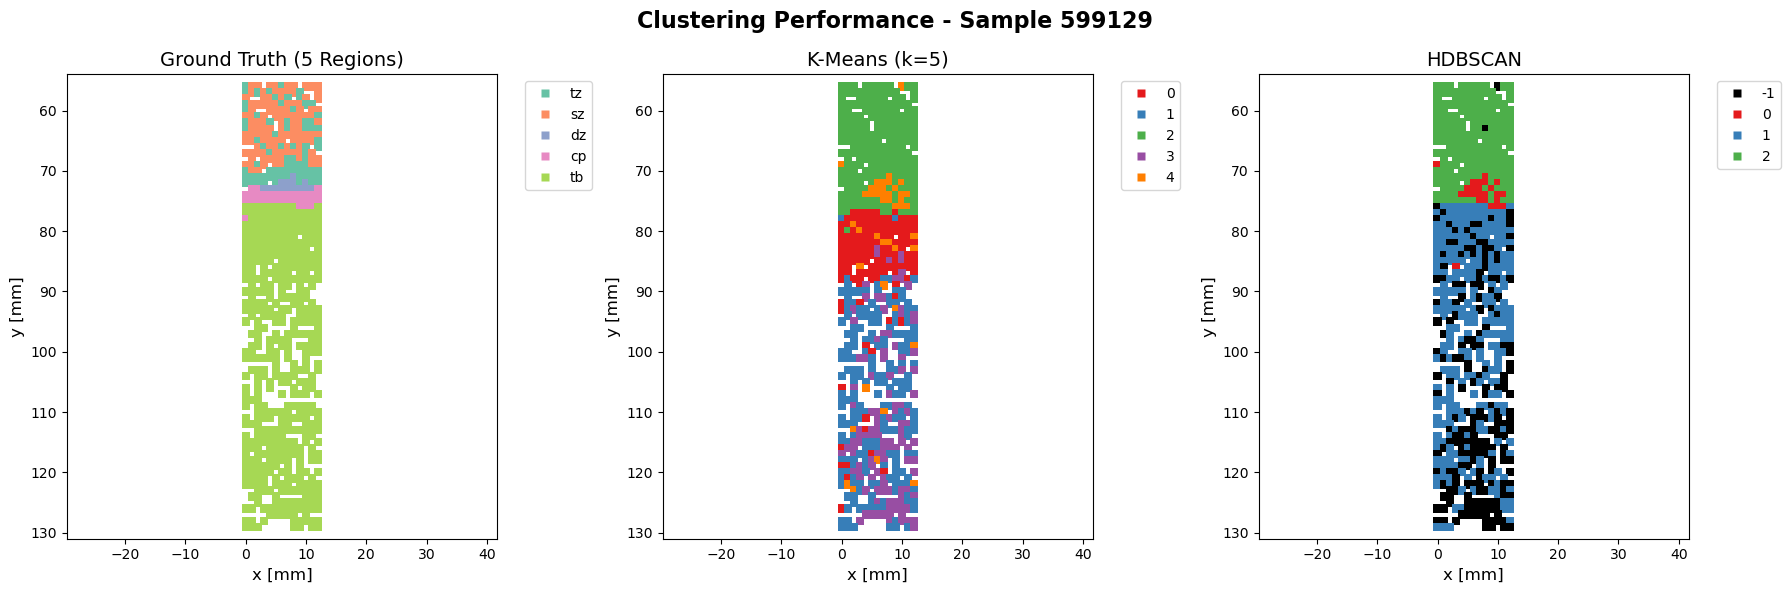

==== METRICS FOR SAMPLE 599146 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.193
Normalized Mutual Info (NMI): 0.319
Homogeneity:                  0.263
Completeness:                 0.407
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.665
Normalized Mutual Info (NMI): 0.658
Homogeneity:                  0.579
Completeness:                 0.761
Noise Percentage:             16.5%



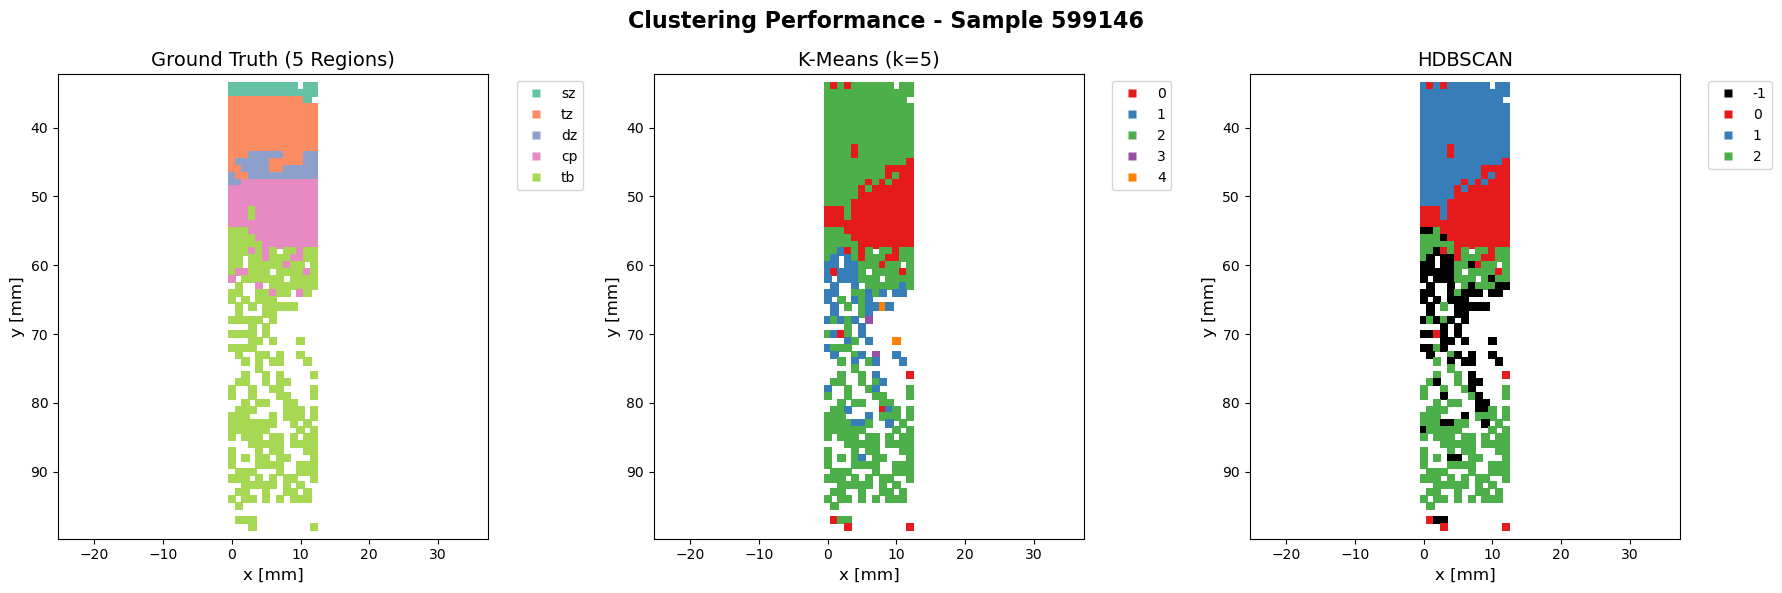

==== METRICS FOR SAMPLE 599148 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.341
Normalized Mutual Info (NMI): 0.565
Homogeneity:                  0.654
Completeness:                 0.497
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.855
Normalized Mutual Info (NMI): 0.747
Homogeneity:                  0.709
Completeness:                 0.790
Noise Percentage:             12.4%



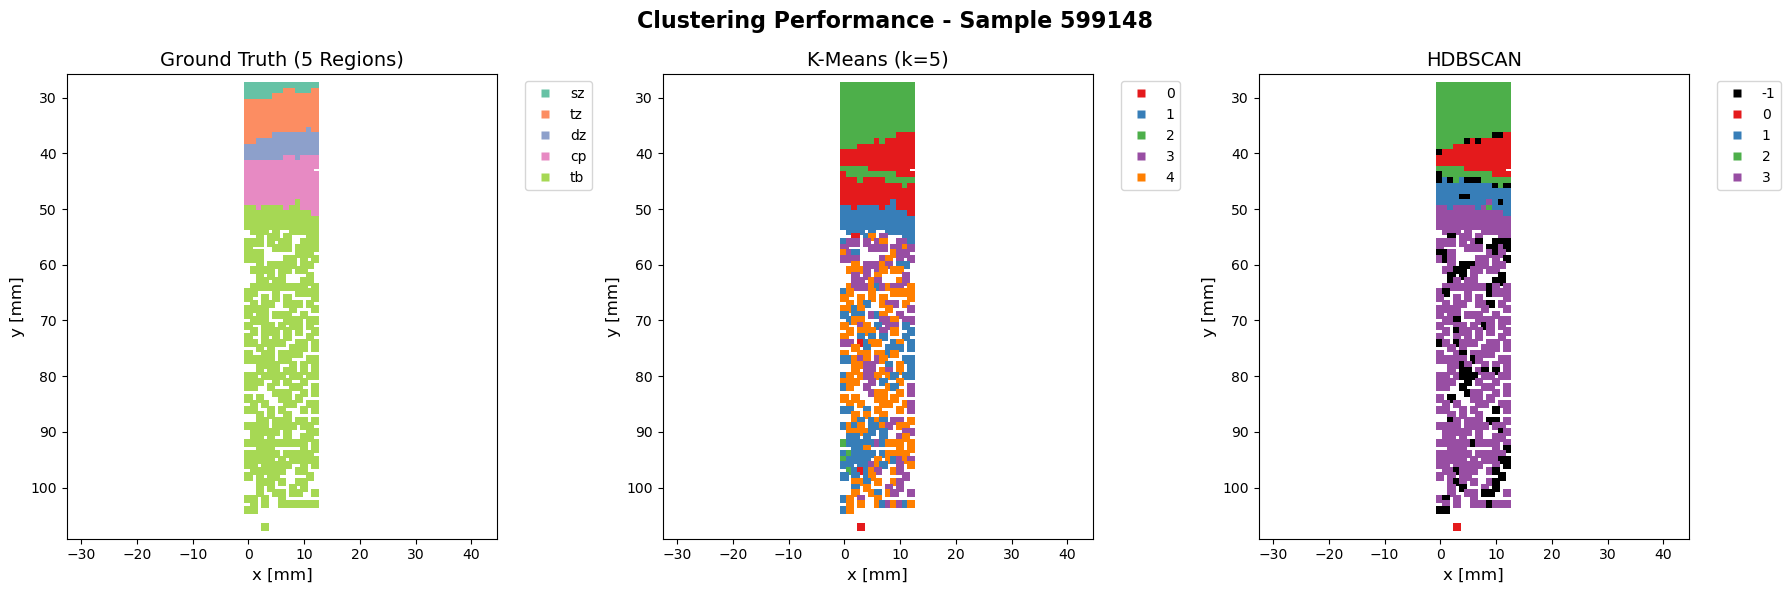

==== METRICS FOR SAMPLE 599170 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.437
Normalized Mutual Info (NMI): 0.524
Homogeneity:                  0.514
Completeness:                 0.534
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.738
Normalized Mutual Info (NMI): 0.684
Homogeneity:                  0.666
Completeness:                 0.702
Noise Percentage:             32.2%



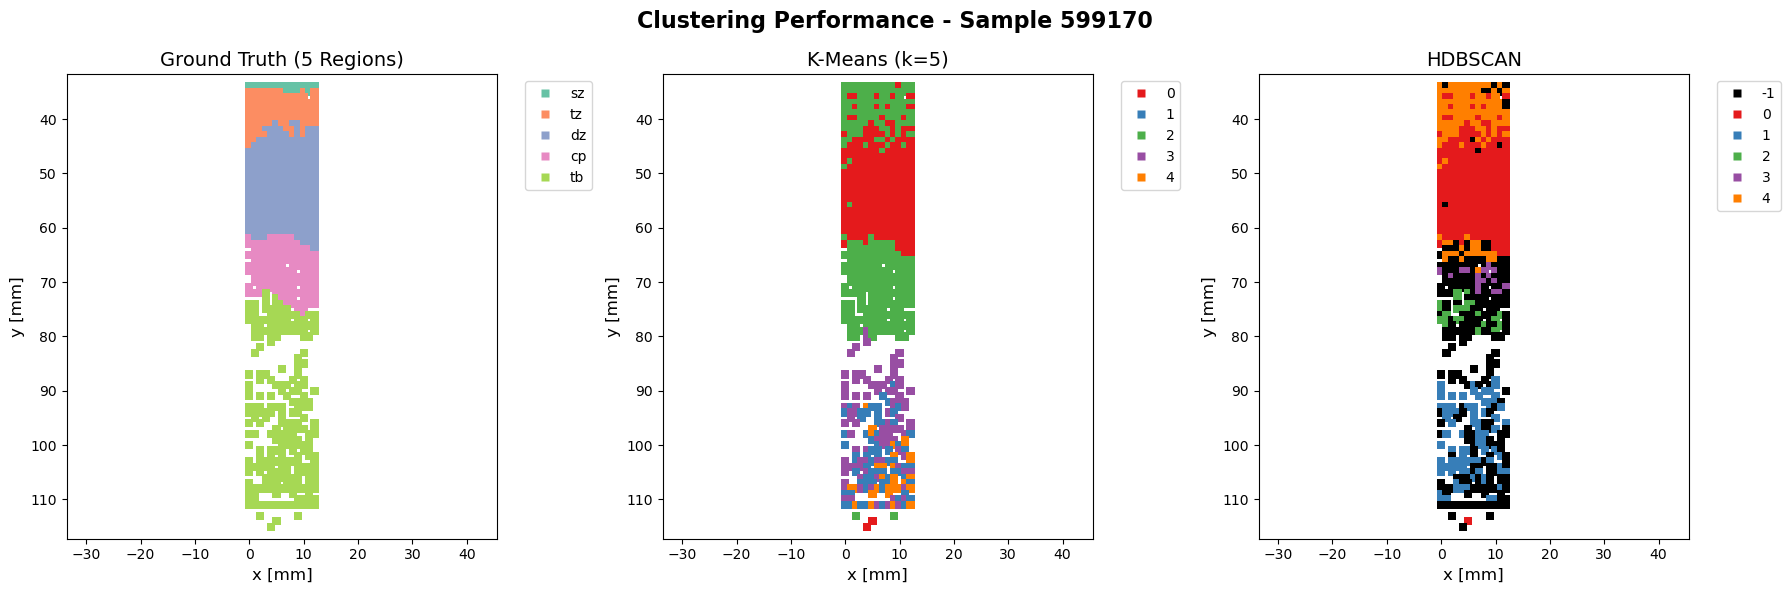

==== METRICS FOR SAMPLE 599177 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.532
Normalized Mutual Info (NMI): 0.570
Homogeneity:                  0.648
Completeness:                 0.508
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.897
Normalized Mutual Info (NMI): 0.838
Homogeneity:                  0.776
Completeness:                 0.911
Noise Percentage:             11.9%



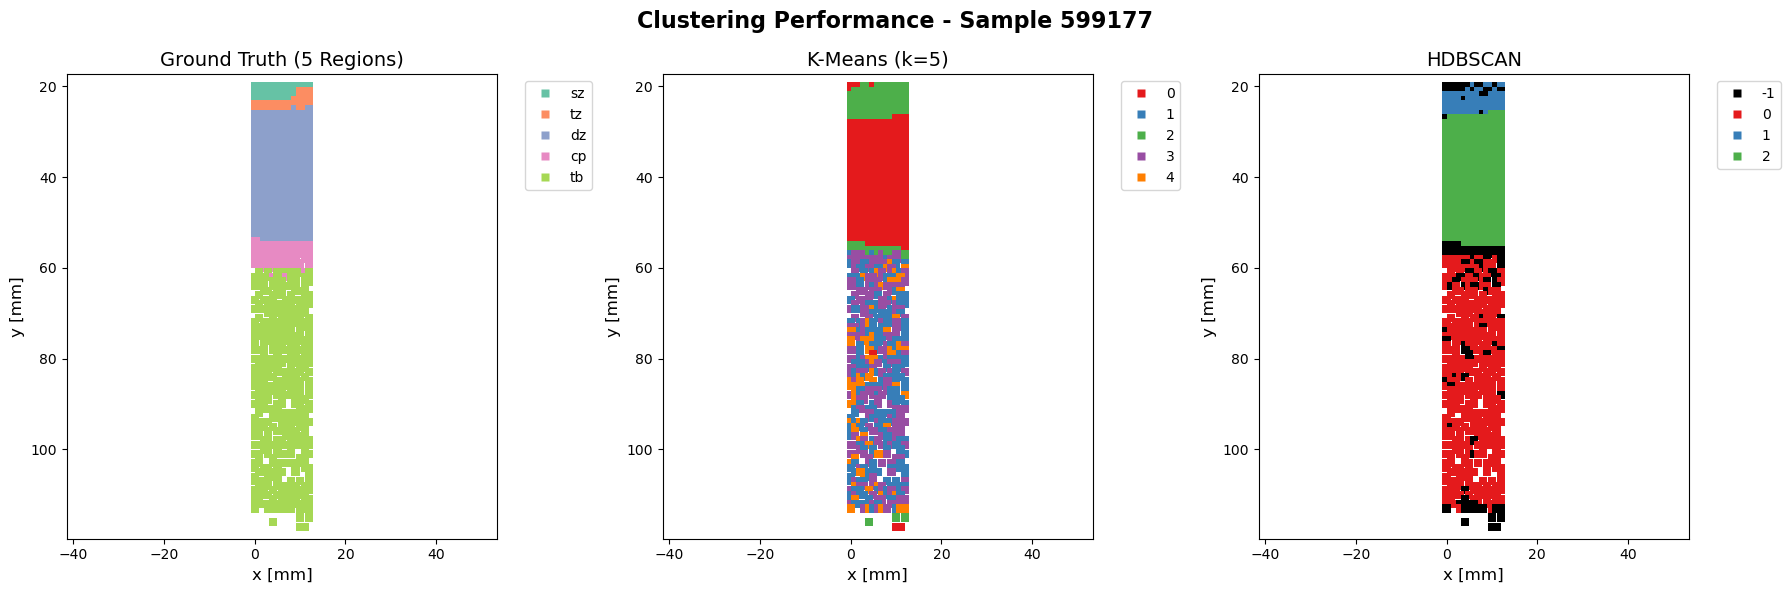

==== METRICS FOR SAMPLE 599196 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.450
Normalized Mutual Info (NMI): 0.615
Homogeneity:                  0.744
Completeness:                 0.525
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.909
Normalized Mutual Info (NMI): 0.842
Homogeneity:                  0.767
Completeness:                 0.933
Noise Percentage:             2.3%



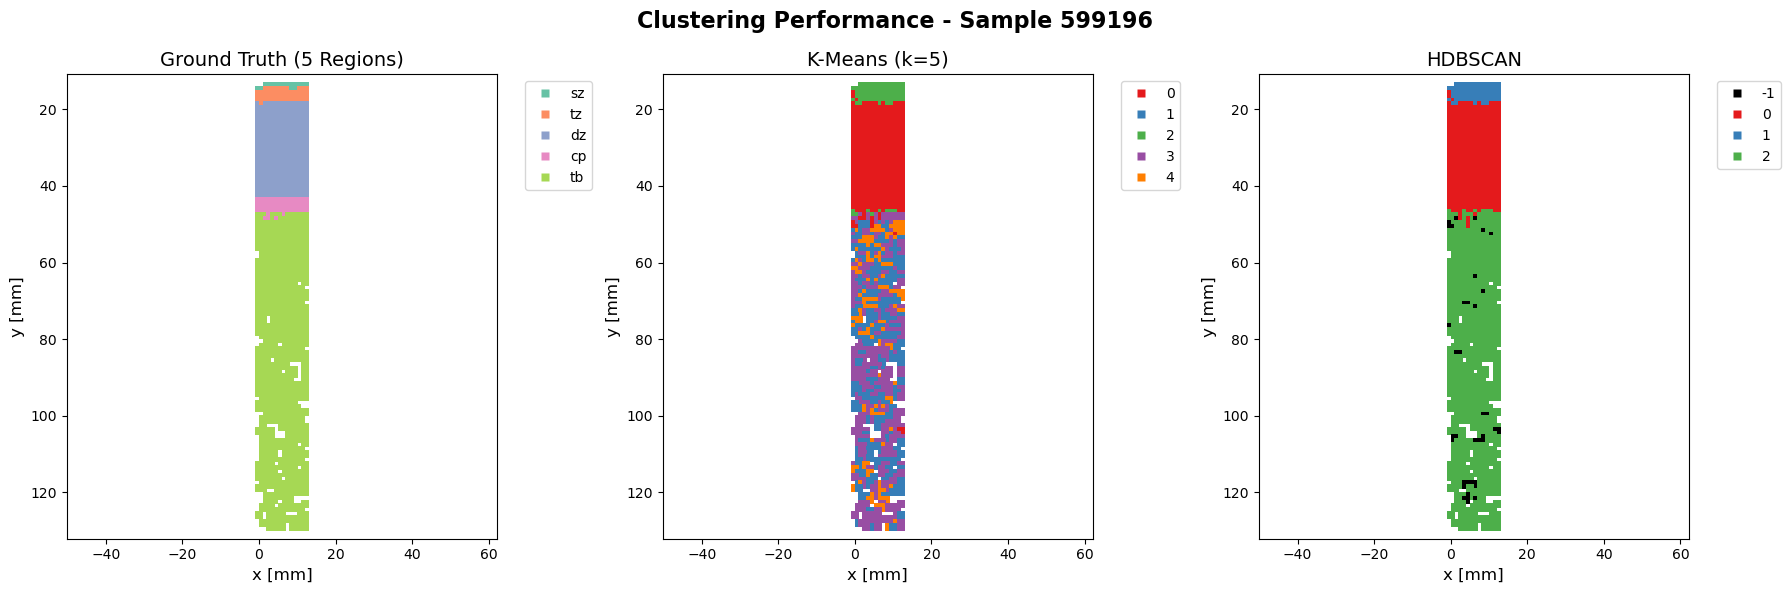

==== METRICS FOR SAMPLE 599202 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.584
Normalized Mutual Info (NMI): 0.633
Homogeneity:                  0.738
Completeness:                 0.554
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.908
Normalized Mutual Info (NMI): 0.826
Homogeneity:                  0.782
Completeness:                 0.876
Noise Percentage:             12.4%



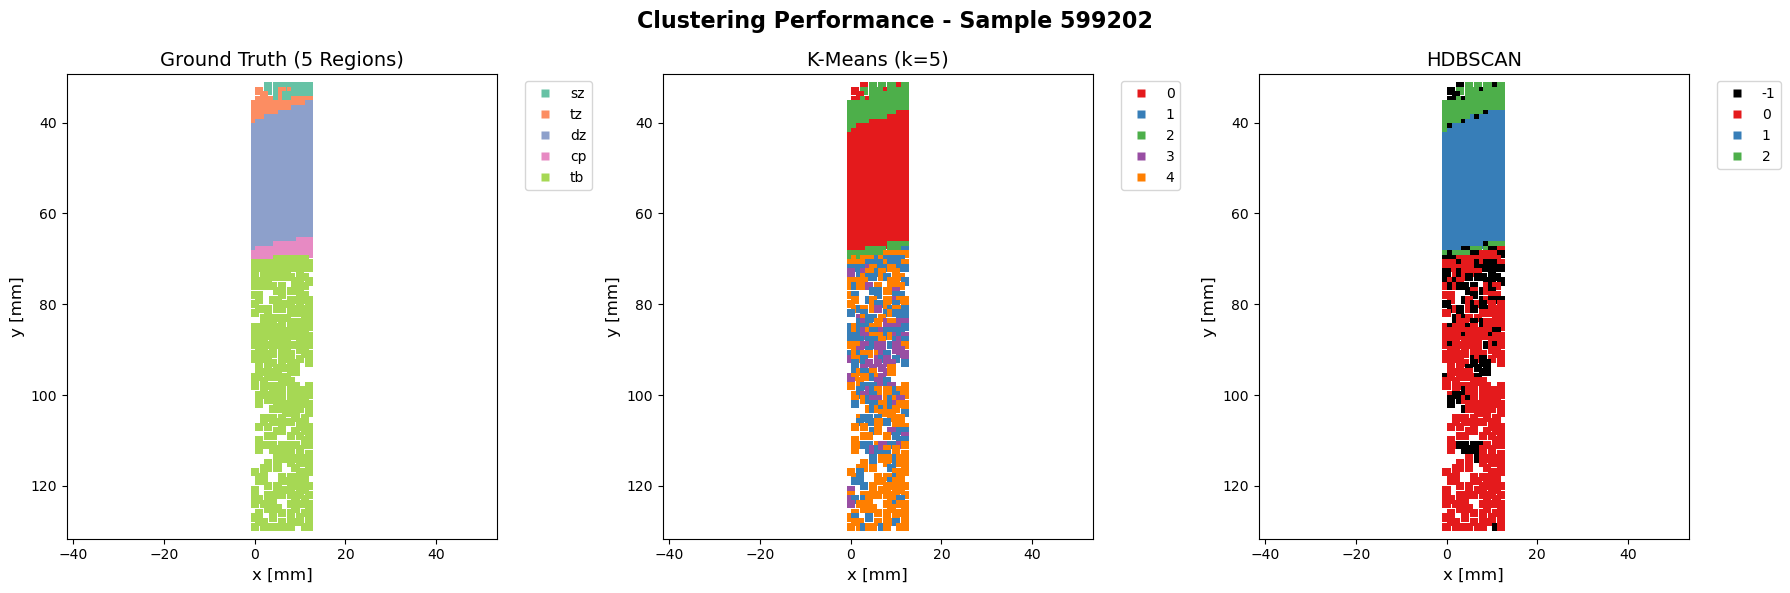

==== METRICS FOR SAMPLE 599204 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.601
Normalized Mutual Info (NMI): 0.639
Homogeneity:                  0.635
Completeness:                 0.642
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.579
Normalized Mutual Info (NMI): 0.634
Homogeneity:                  0.541
Completeness:                 0.764
Noise Percentage:             11.9%



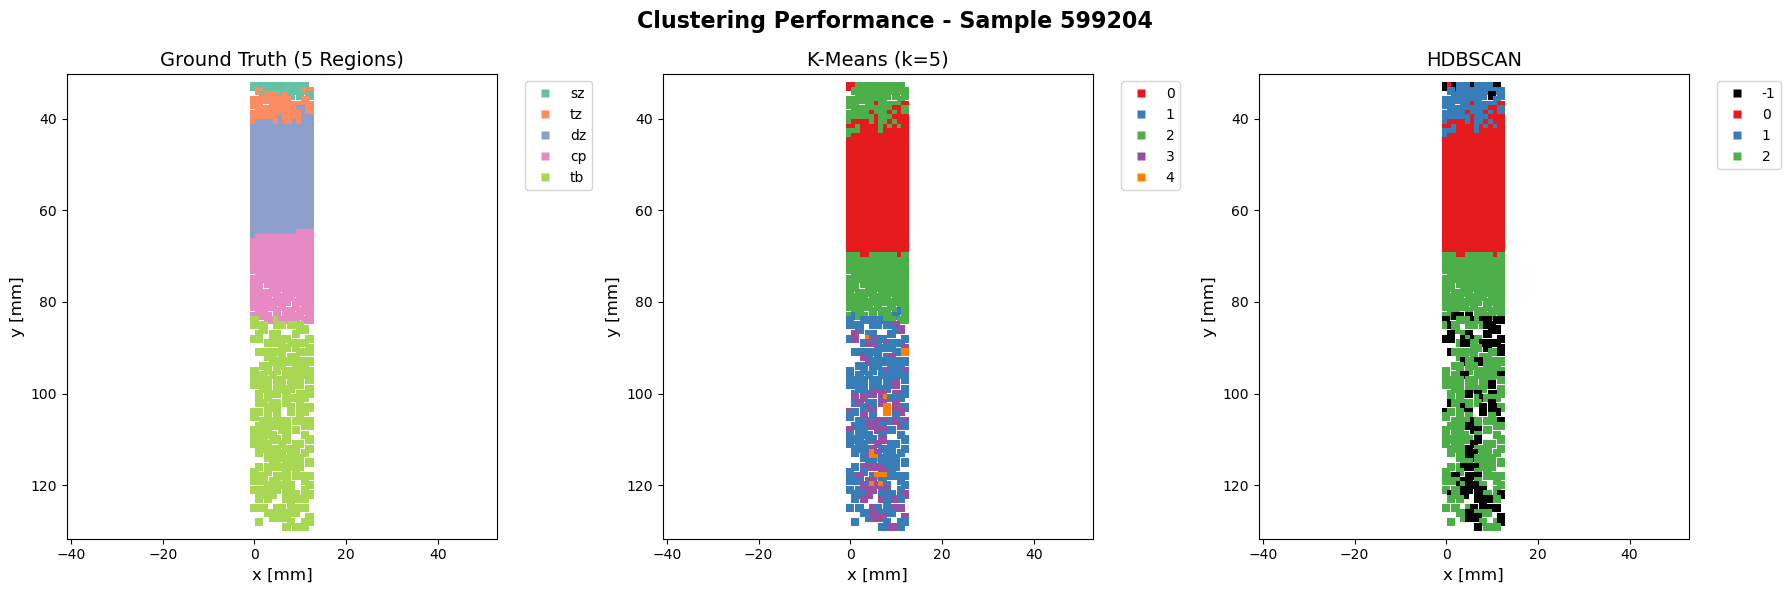

==== METRICS FOR SAMPLE 599171 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.472
Normalized Mutual Info (NMI): 0.584
Homogeneity:                  0.617
Completeness:                 0.554
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.438
Normalized Mutual Info (NMI): 0.545
Homogeneity:                  0.467
Completeness:                 0.655
Noise Percentage:             14.5%



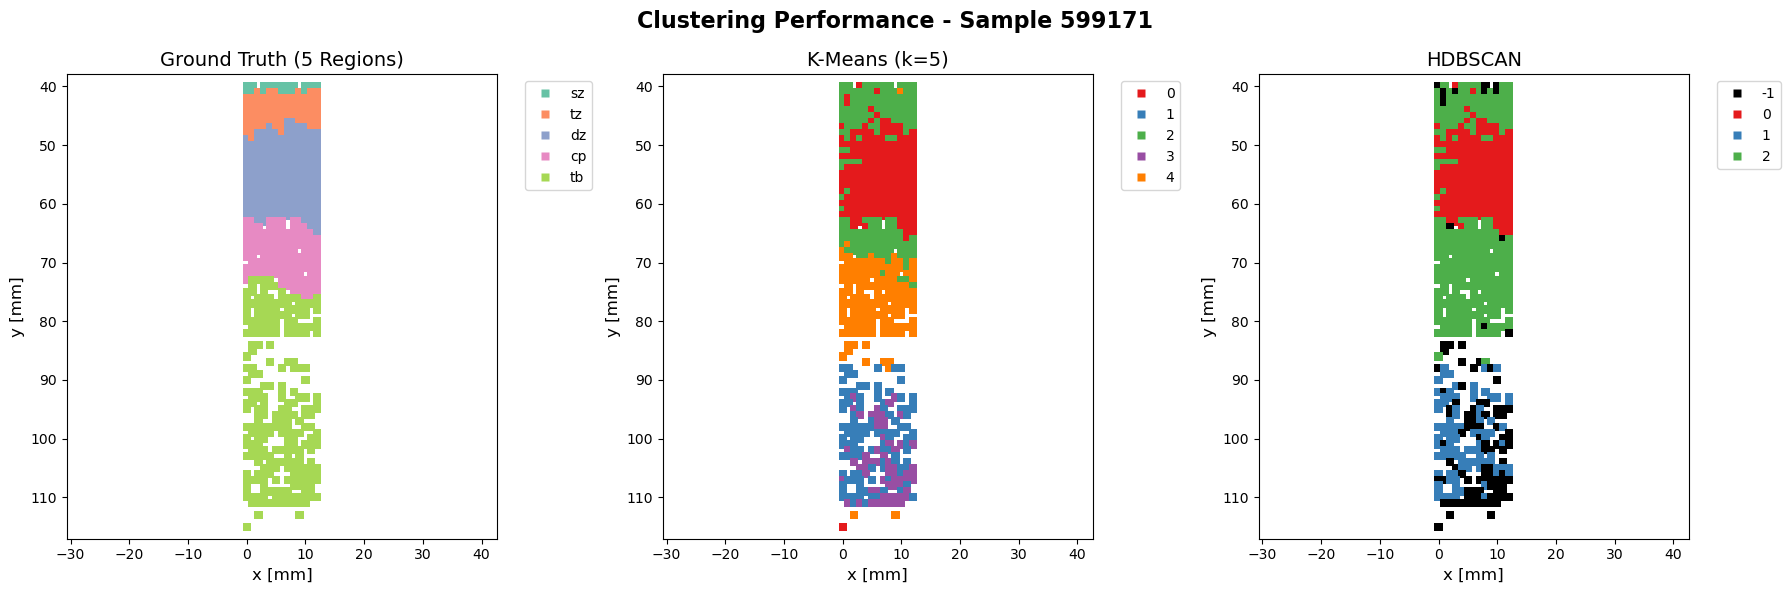

==== METRICS FOR SAMPLE 599178 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.509
Normalized Mutual Info (NMI): 0.602
Homogeneity:                  0.721
Completeness:                 0.516
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.904
Normalized Mutual Info (NMI): 0.842
Homogeneity:                  0.834
Completeness:                 0.850
Noise Percentage:             14.1%



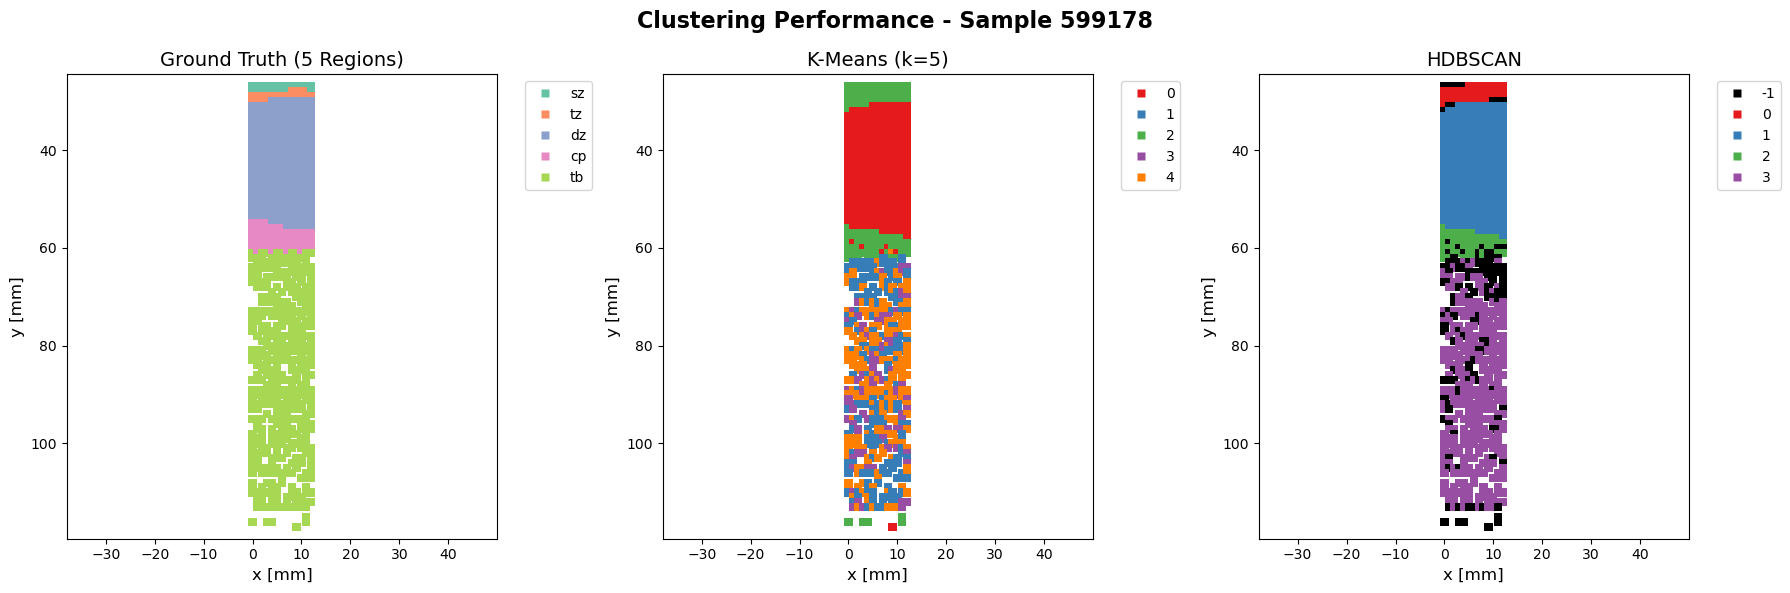

==== METRICS FOR SAMPLE 599197 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.520
Normalized Mutual Info (NMI): 0.657
Homogeneity:                  0.763
Completeness:                 0.577
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.908
Normalized Mutual Info (NMI): 0.854
Homogeneity:                  0.772
Completeness:                 0.955
Noise Percentage:             3.6%



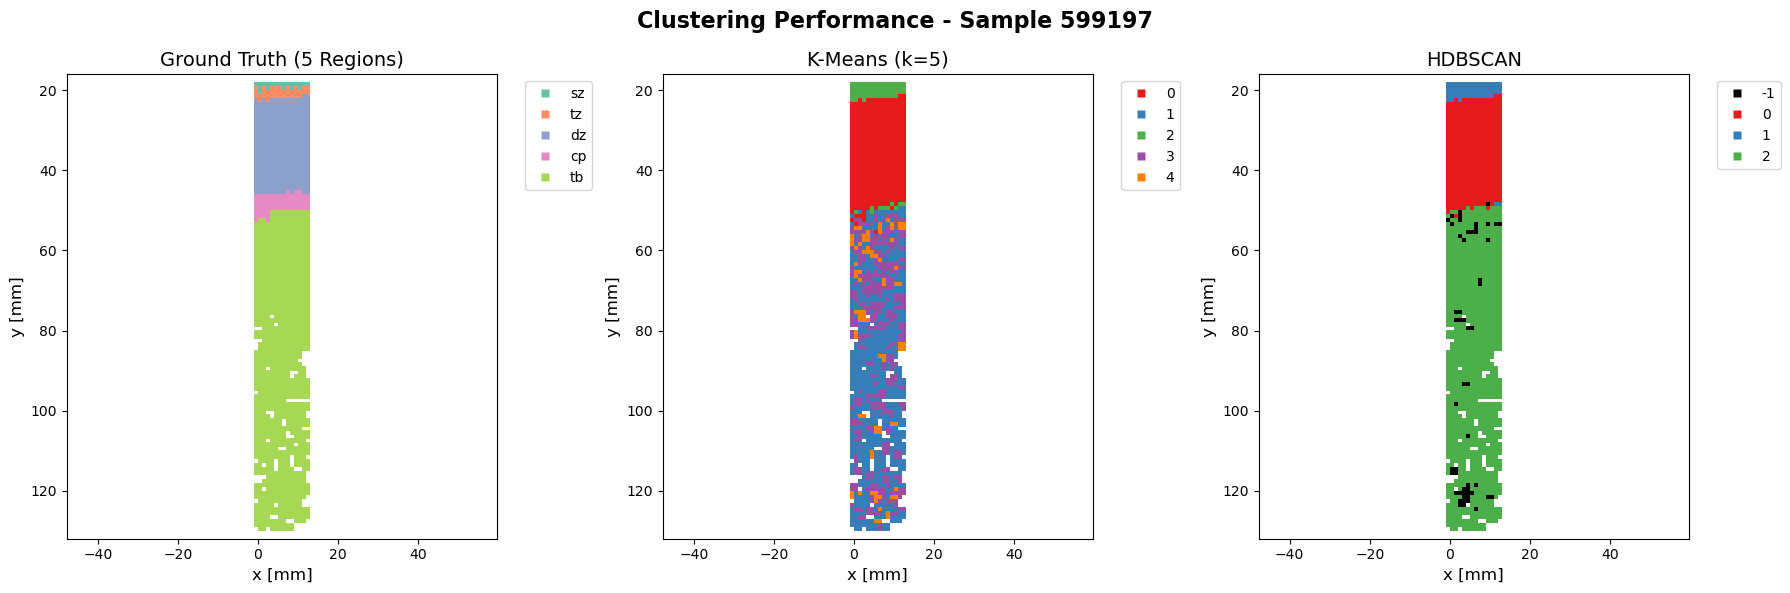

==== METRICS FOR SAMPLE 599203 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.610
Normalized Mutual Info (NMI): 0.658
Homogeneity:                  0.769
Completeness:                 0.574
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.935
Normalized Mutual Info (NMI): 0.866
Homogeneity:                  0.825
Completeness:                 0.911
Noise Percentage:             15.9%



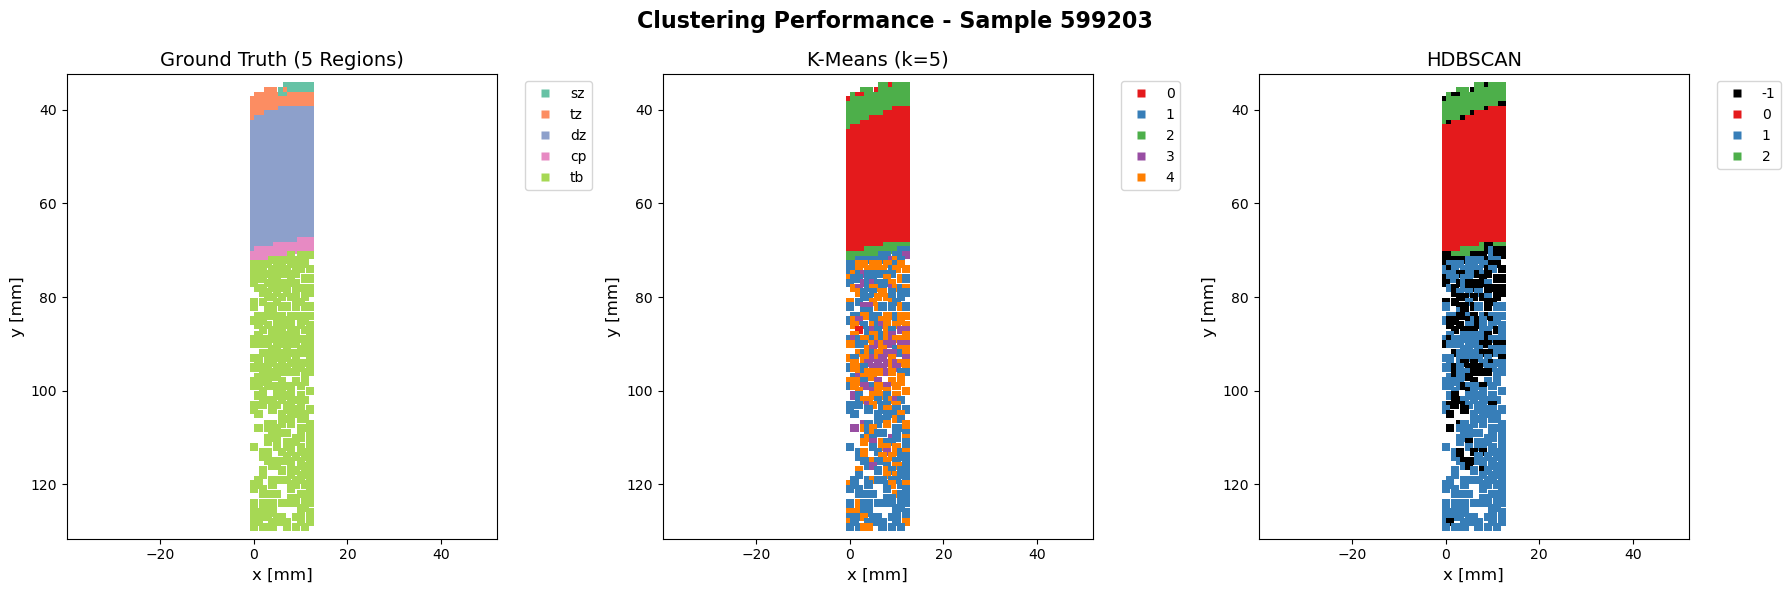

==== METRICS FOR SAMPLE 599205 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.541
Normalized Mutual Info (NMI): 0.608
Homogeneity:                  0.634
Completeness:                 0.584
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.748
Normalized Mutual Info (NMI): 0.768
Homogeneity:                  0.742
Completeness:                 0.796
Noise Percentage:             13.5%



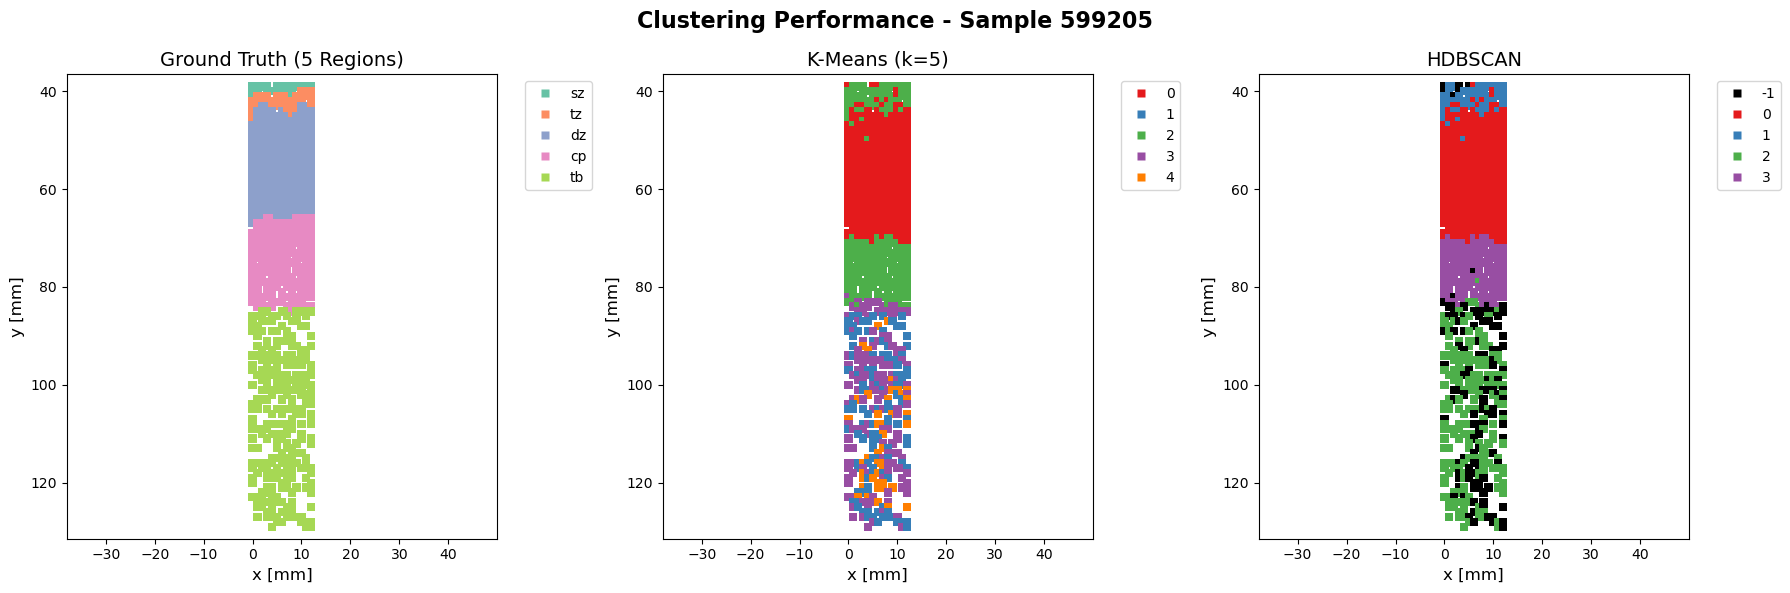

==== METRICS FOR SAMPLE 599161 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.613
Normalized Mutual Info (NMI): 0.584
Homogeneity:                  0.606
Completeness:                 0.563
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.854
Normalized Mutual Info (NMI): 0.770
Homogeneity:                  0.821
Completeness:                 0.725
Noise Percentage:             28.6%



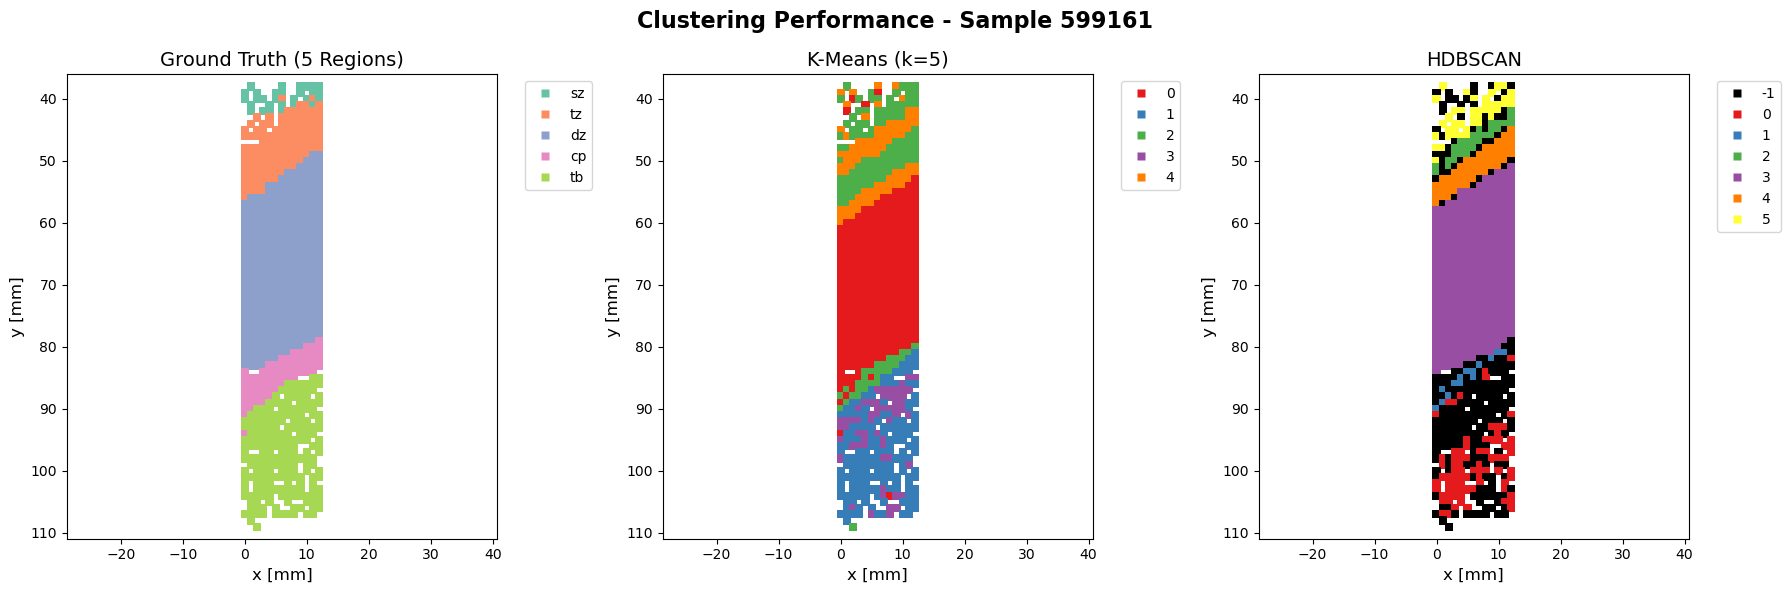

==== METRICS FOR SAMPLE 599173 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.455
Normalized Mutual Info (NMI): 0.556
Homogeneity:                  0.599
Completeness:                 0.518
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.802
Normalized Mutual Info (NMI): 0.764
Homogeneity:                  0.689
Completeness:                 0.858
Noise Percentage:             13.1%



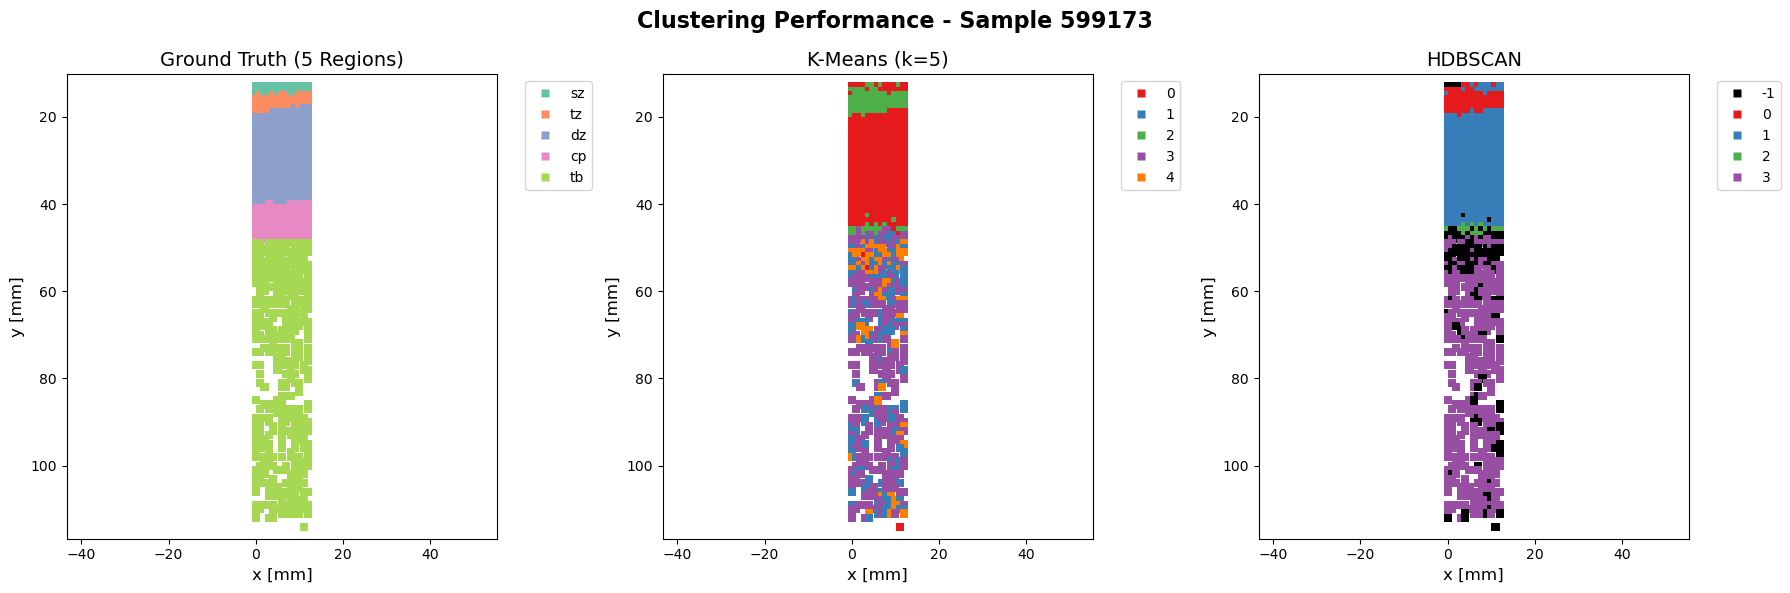

==== METRICS FOR SAMPLE 599179 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.528
Normalized Mutual Info (NMI): 0.663
Homogeneity:                  0.782
Completeness:                 0.575
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.901
Normalized Mutual Info (NMI): 0.833
Homogeneity:                  0.754
Completeness:                 0.932
Noise Percentage:             14.0%



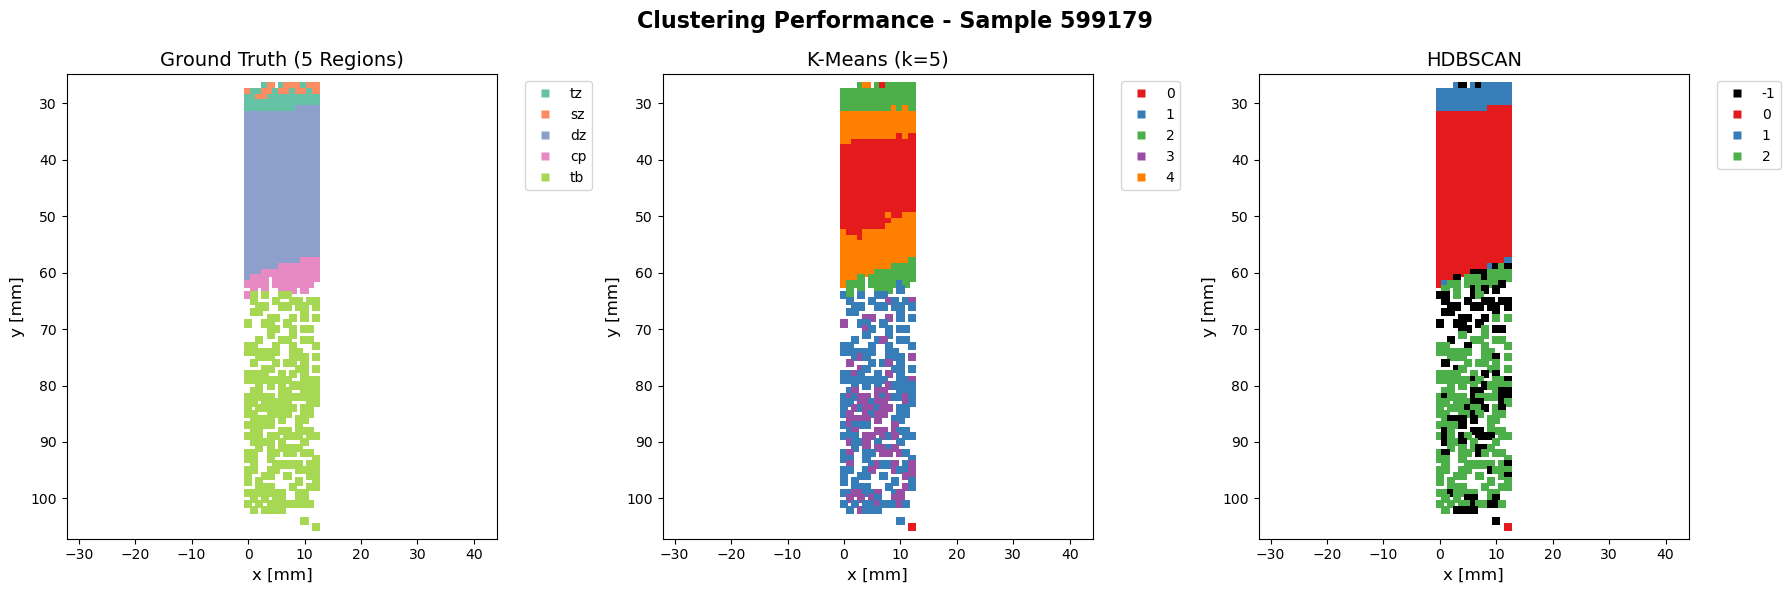

==== METRICS FOR SAMPLE 599192 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.534
Normalized Mutual Info (NMI): 0.604
Homogeneity:                  0.619
Completeness:                 0.589
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.895
Normalized Mutual Info (NMI): 0.855
Homogeneity:                  0.800
Completeness:                 0.918
Noise Percentage:             11.9%



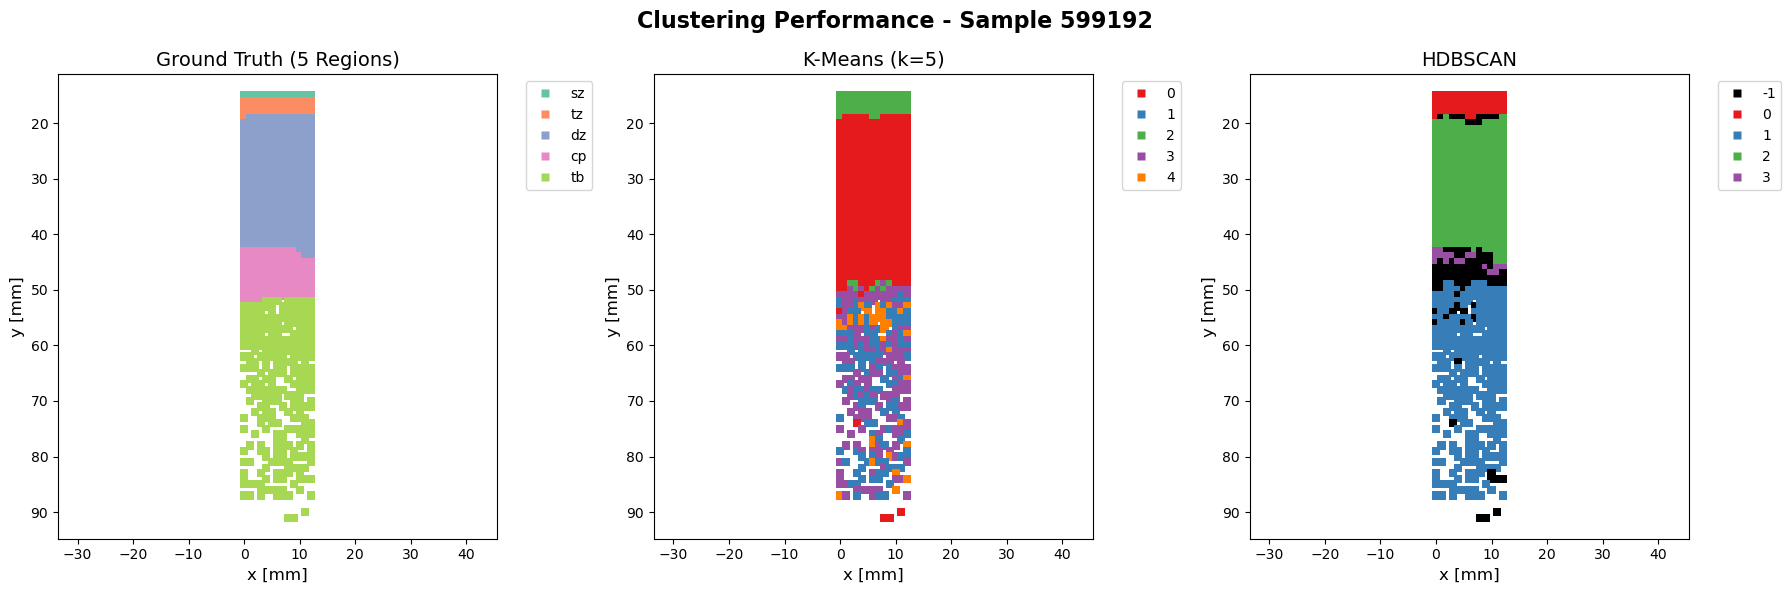

==== METRICS FOR SAMPLE 599198 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.582
Normalized Mutual Info (NMI): 0.684
Homogeneity:                  0.747
Completeness:                 0.630
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.826
Normalized Mutual Info (NMI): 0.775
Homogeneity:                  0.721
Completeness:                 0.839
Noise Percentage:             6.2%



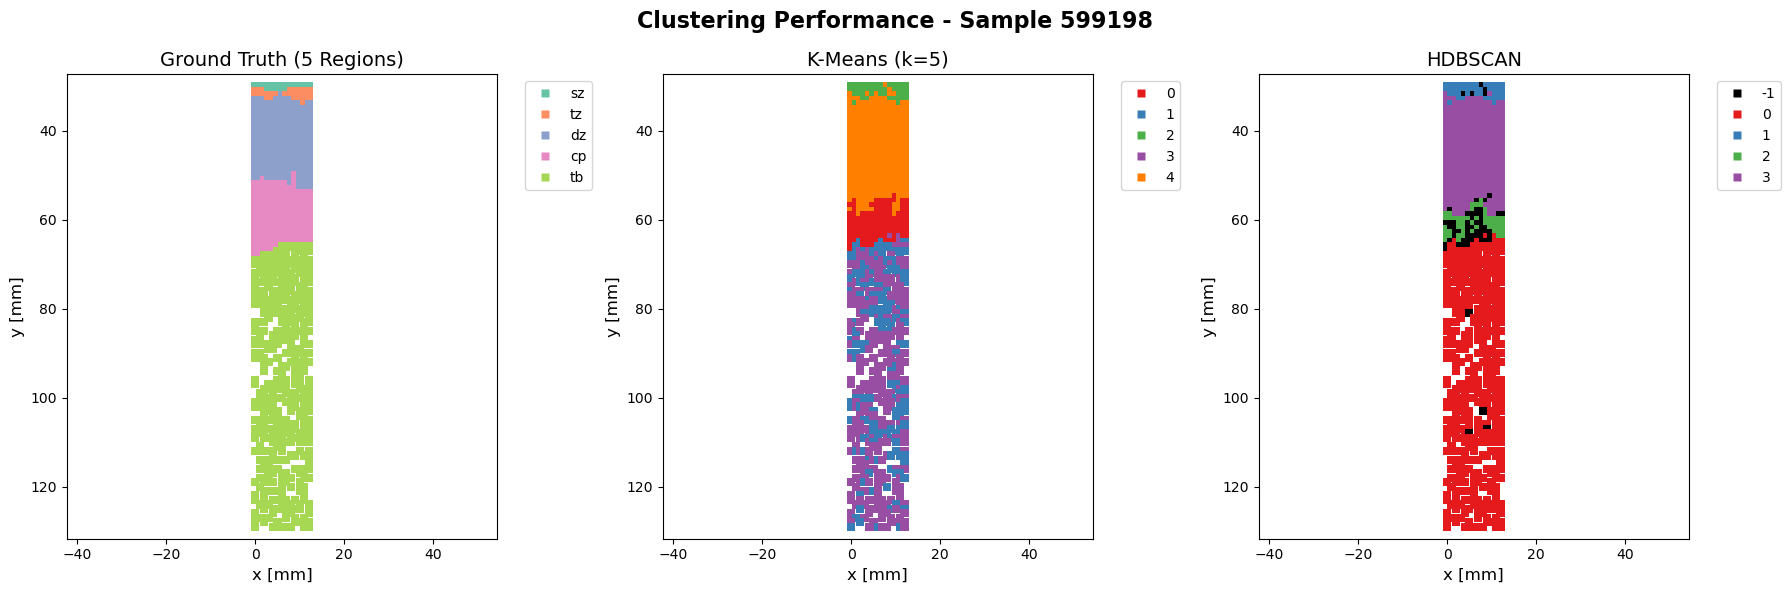

==== METRICS FOR SAMPLE 599166 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.614
Normalized Mutual Info (NMI): 0.559
Homogeneity:                  0.538
Completeness:                 0.581
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.693
Normalized Mutual Info (NMI): 0.637
Homogeneity:                  0.621
Completeness:                 0.654
Noise Percentage:             22.1%



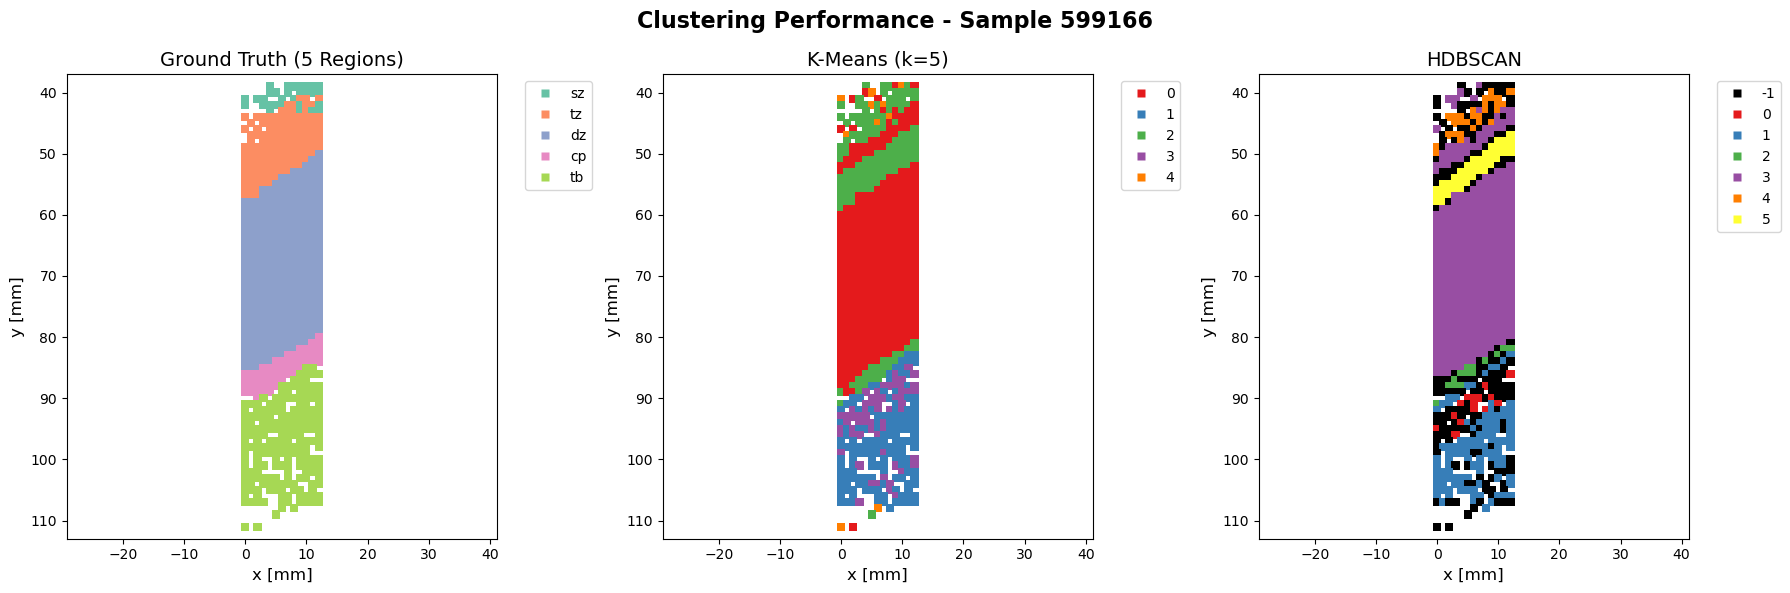

==== METRICS FOR SAMPLE 599174 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.502
Normalized Mutual Info (NMI): 0.605
Homogeneity:                  0.636
Completeness:                 0.577
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.764
Normalized Mutual Info (NMI): 0.736
Homogeneity:                  0.637
Completeness:                 0.872
Noise Percentage:             4.3%



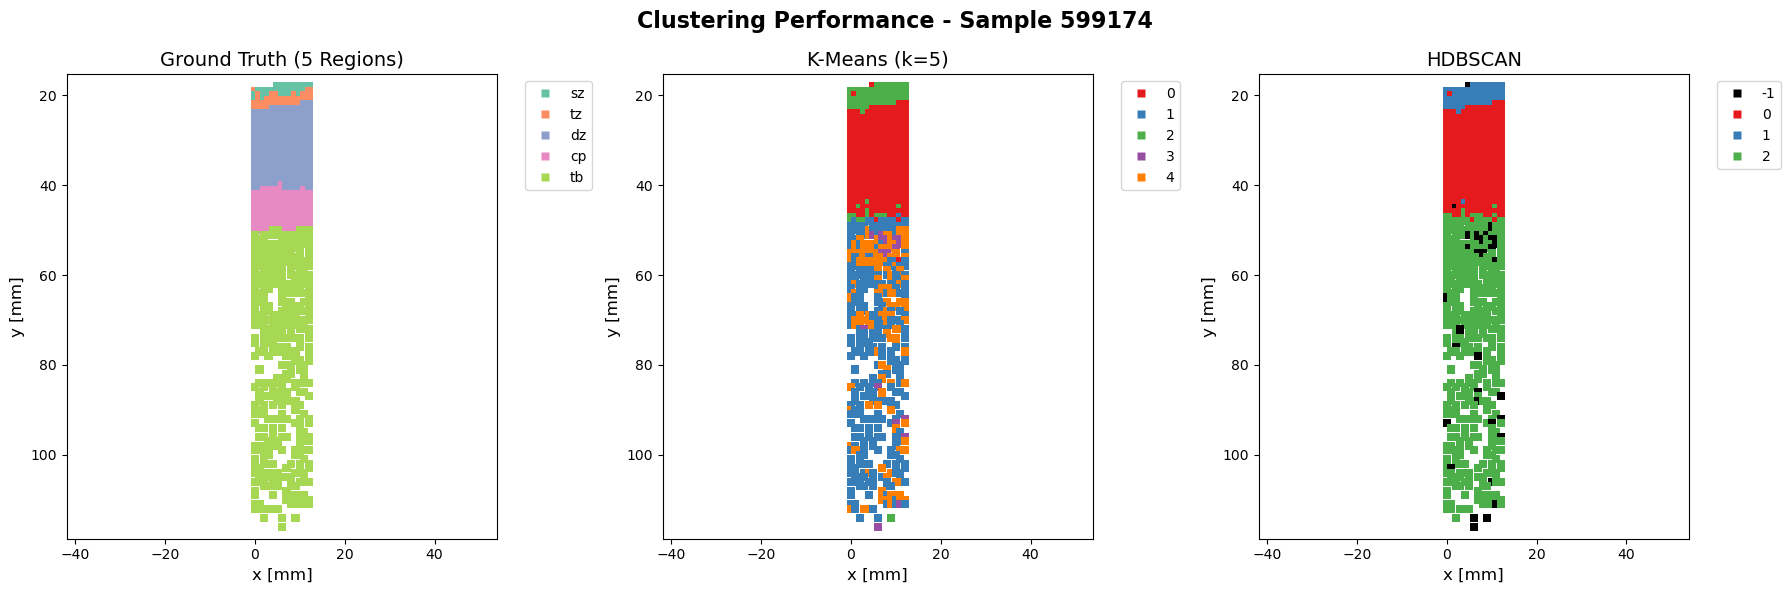

==== METRICS FOR SAMPLE 599180 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.802
Normalized Mutual Info (NMI): 0.761
Homogeneity:                  0.787
Completeness:                 0.736
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.942
Normalized Mutual Info (NMI): 0.879
Homogeneity:                  0.812
Completeness:                 0.958
Noise Percentage:             9.0%



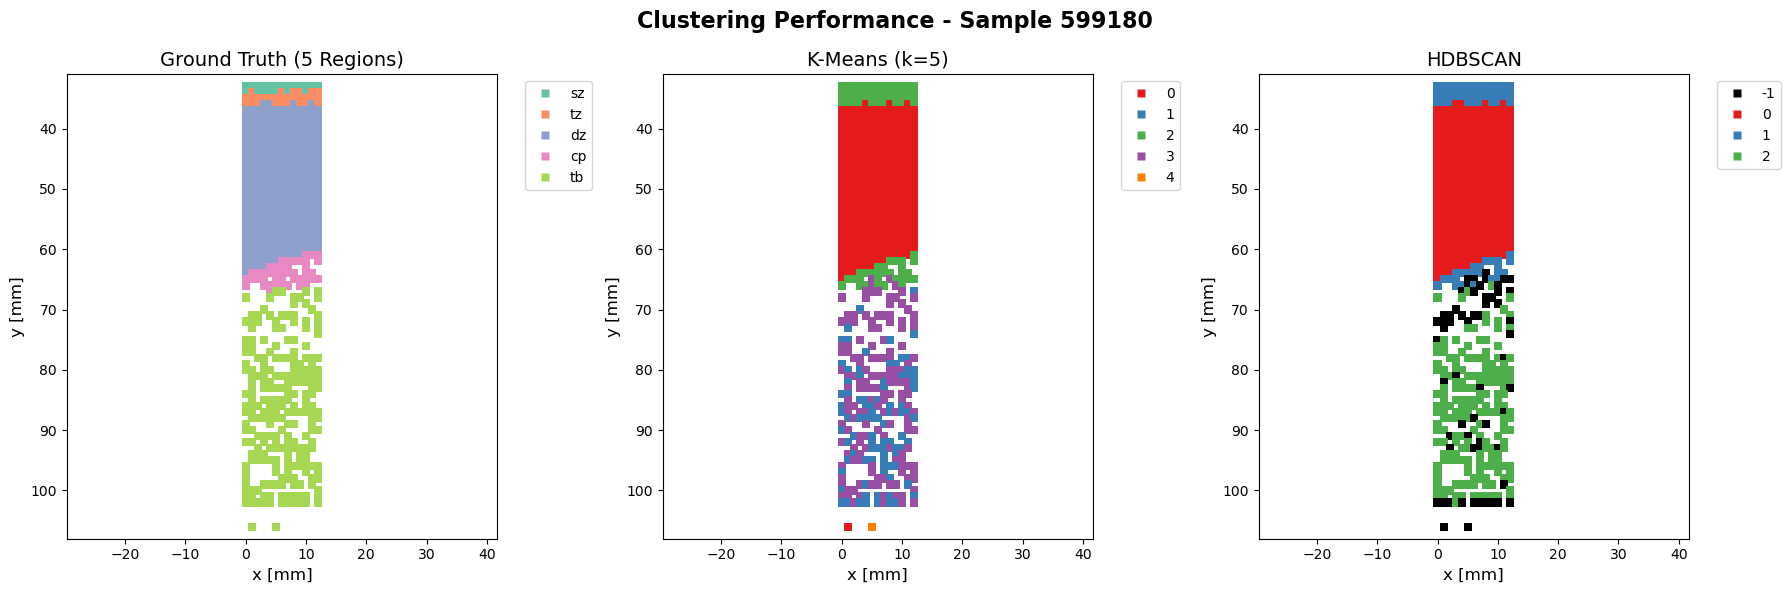

==== METRICS FOR SAMPLE 599193 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.518
Normalized Mutual Info (NMI): 0.632
Homogeneity:                  0.644
Completeness:                 0.621
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.896
Normalized Mutual Info (NMI): 0.859
Homogeneity:                  0.800
Completeness:                 0.928
Noise Percentage:             11.9%



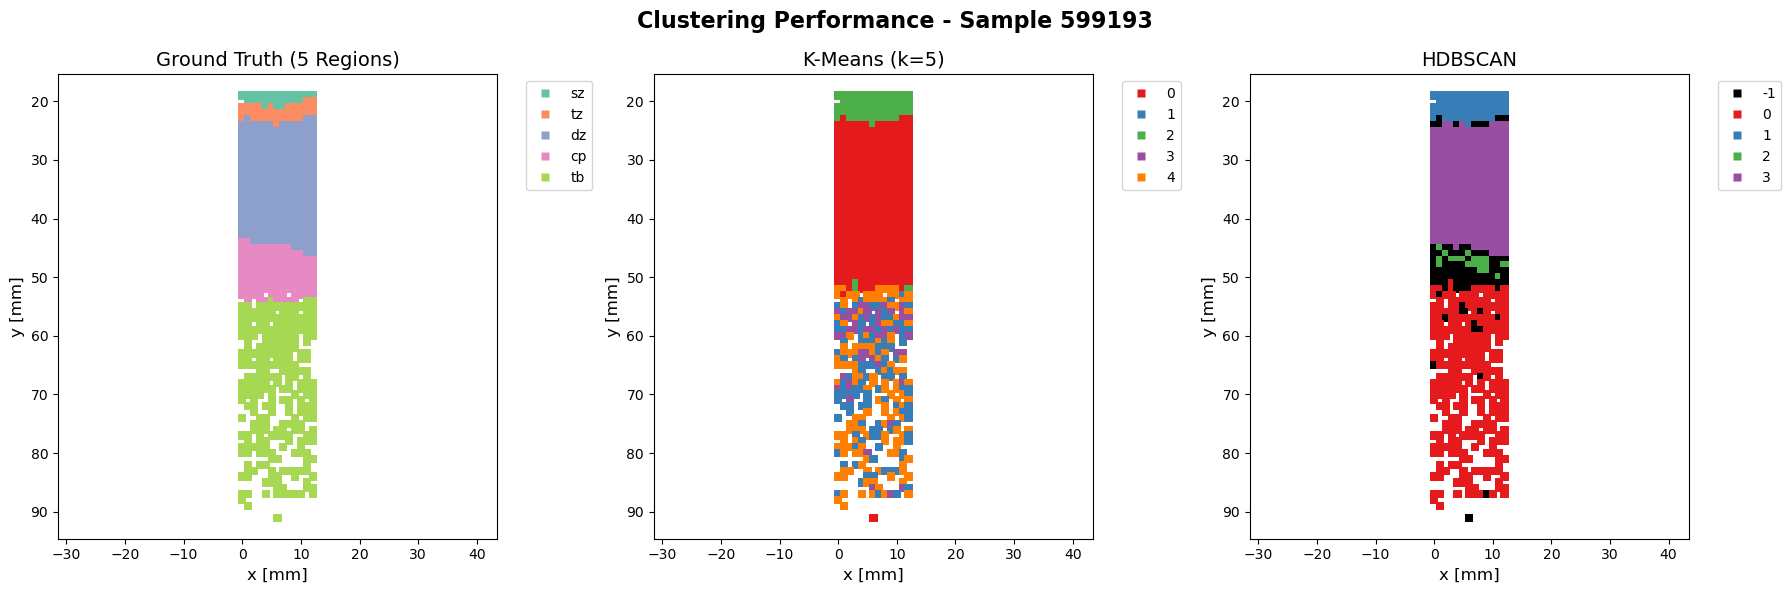

==== METRICS FOR SAMPLE 599199 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.418
Normalized Mutual Info (NMI): 0.579
Homogeneity:                  0.671
Completeness:                 0.510
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.753
Normalized Mutual Info (NMI): 0.772
Homogeneity:                  0.660
Completeness:                 0.929
Noise Percentage:             0.3%



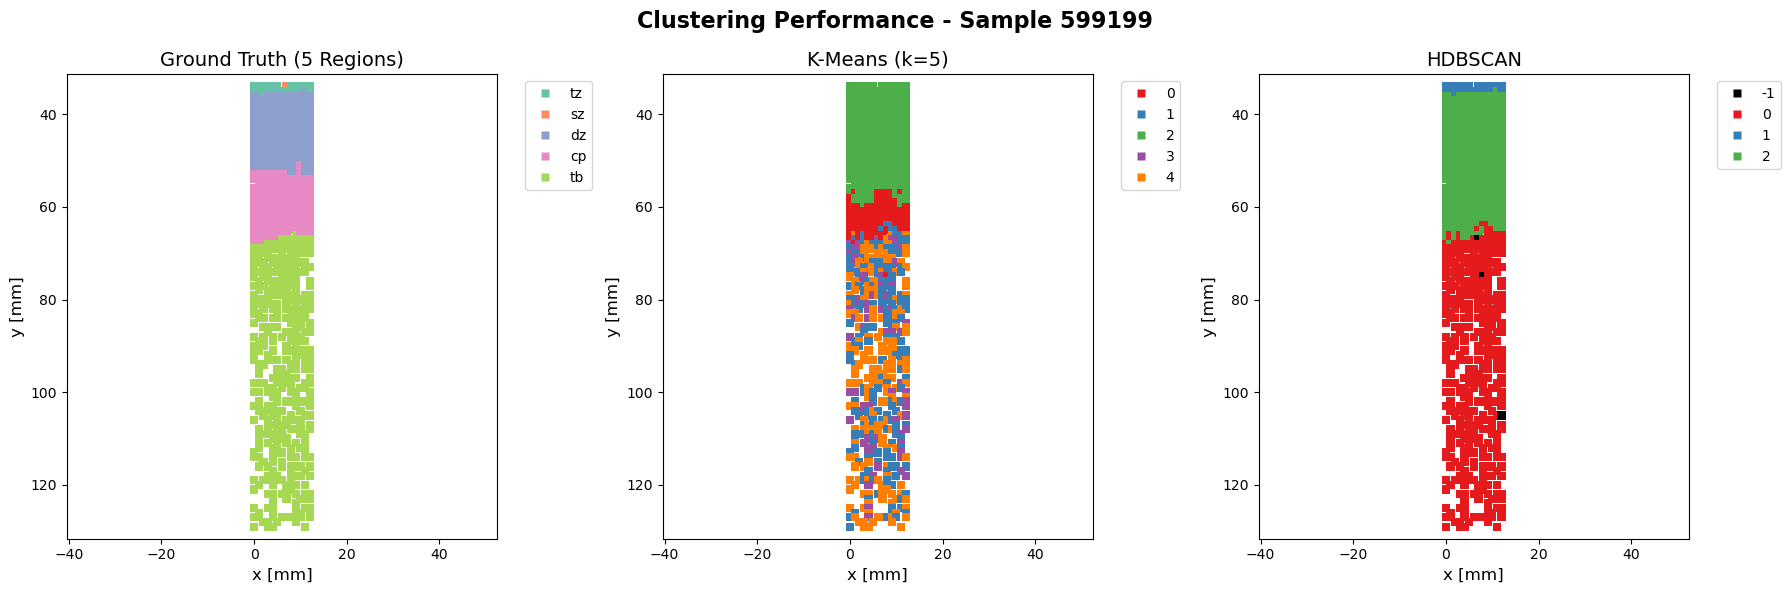

==== METRICS FOR SAMPLE 599167 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.520
Normalized Mutual Info (NMI): 0.567
Homogeneity:                  0.579
Completeness:                 0.556
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.735
Normalized Mutual Info (NMI): 0.714
Homogeneity:                  0.628
Completeness:                 0.828
Noise Percentage:             5.1%



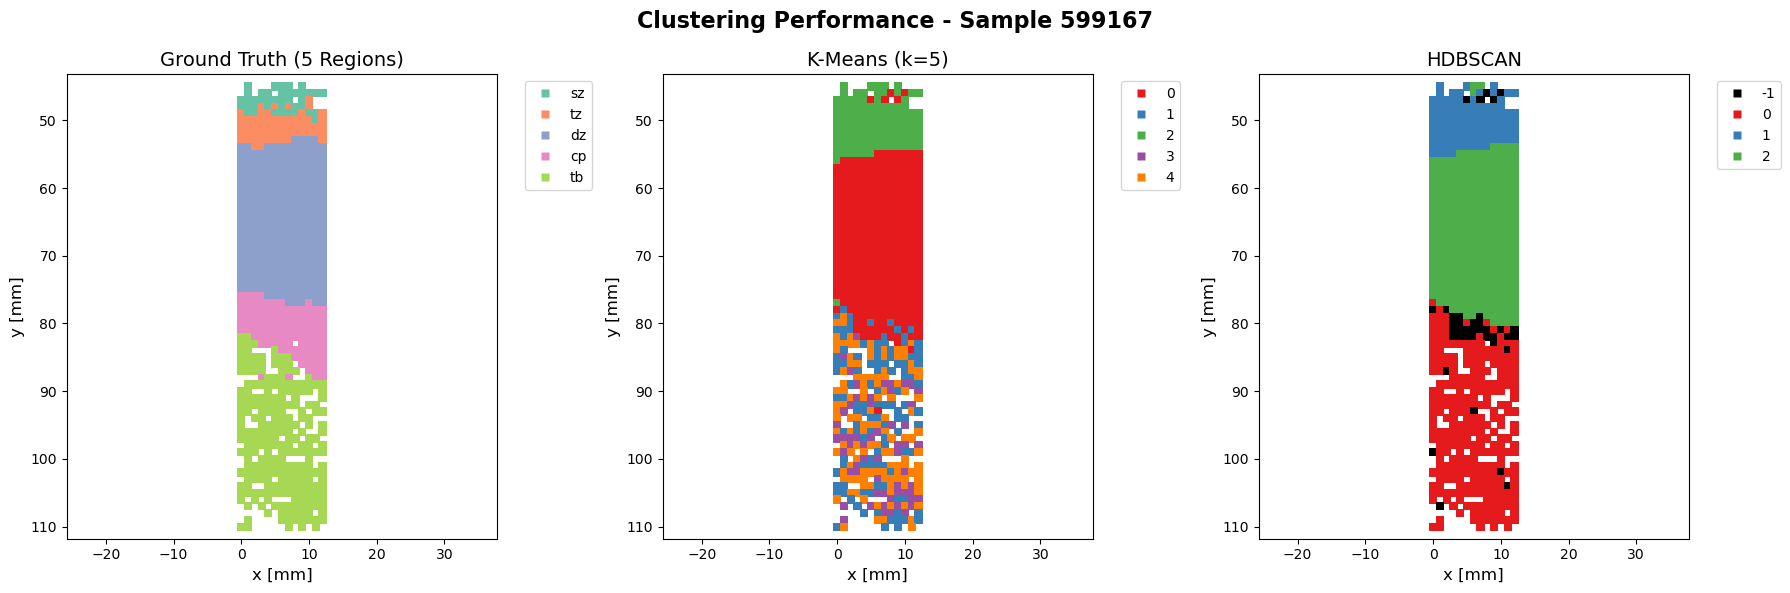

==== METRICS FOR SAMPLE 599175 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.601
Normalized Mutual Info (NMI): 0.662
Homogeneity:                  0.712
Completeness:                 0.619
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.873
Normalized Mutual Info (NMI): 0.802
Homogeneity:                  0.732
Completeness:                 0.887
Noise Percentage:             7.7%



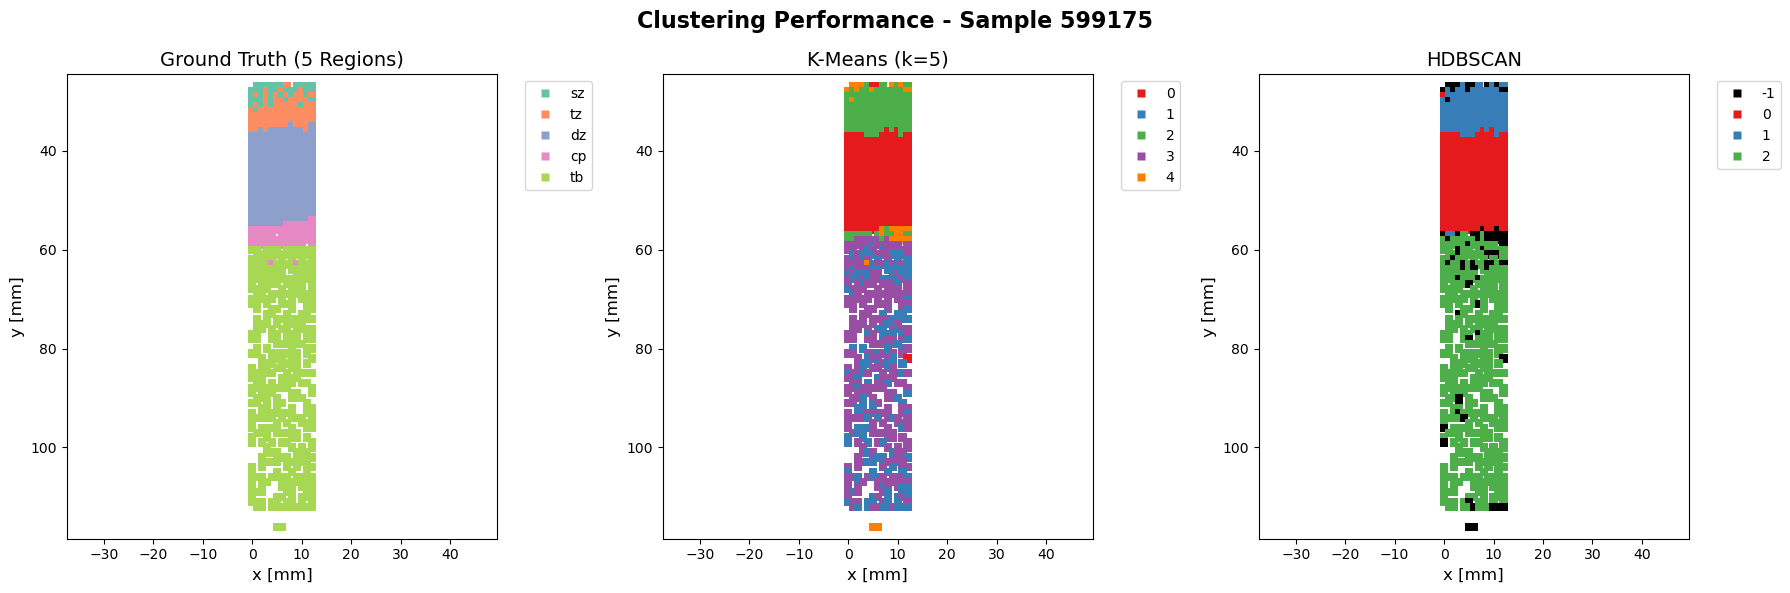

==== METRICS FOR SAMPLE 599181 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.512
Normalized Mutual Info (NMI): 0.624
Homogeneity:                  0.682
Completeness:                 0.575
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.853
Normalized Mutual Info (NMI): 0.827
Homogeneity:                  0.784
Completeness:                 0.875
Noise Percentage:             21.1%



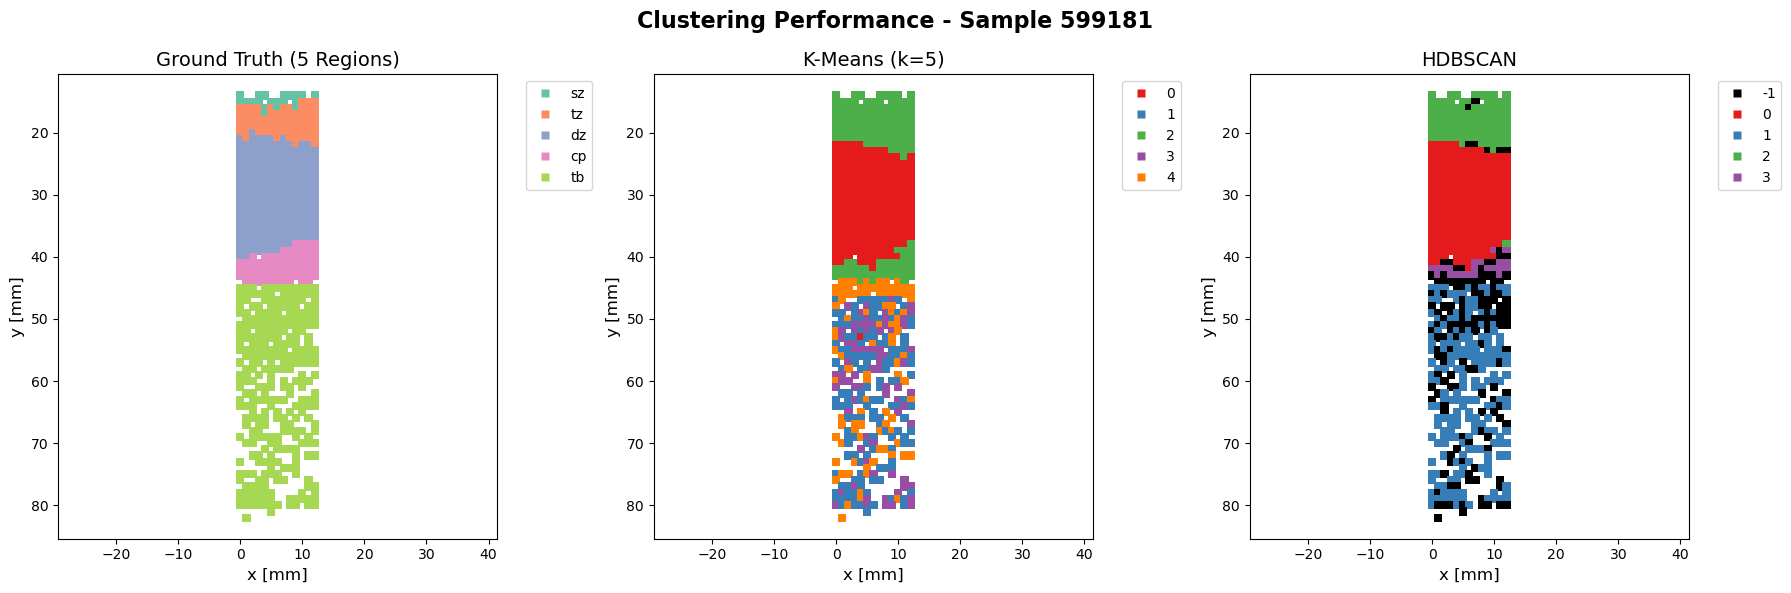

==== METRICS FOR SAMPLE 599194 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.570
Normalized Mutual Info (NMI): 0.628
Homogeneity:                  0.644
Completeness:                 0.612
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.757
Normalized Mutual Info (NMI): 0.710
Homogeneity:                  0.649
Completeness:                 0.785
Noise Percentage:             7.6%



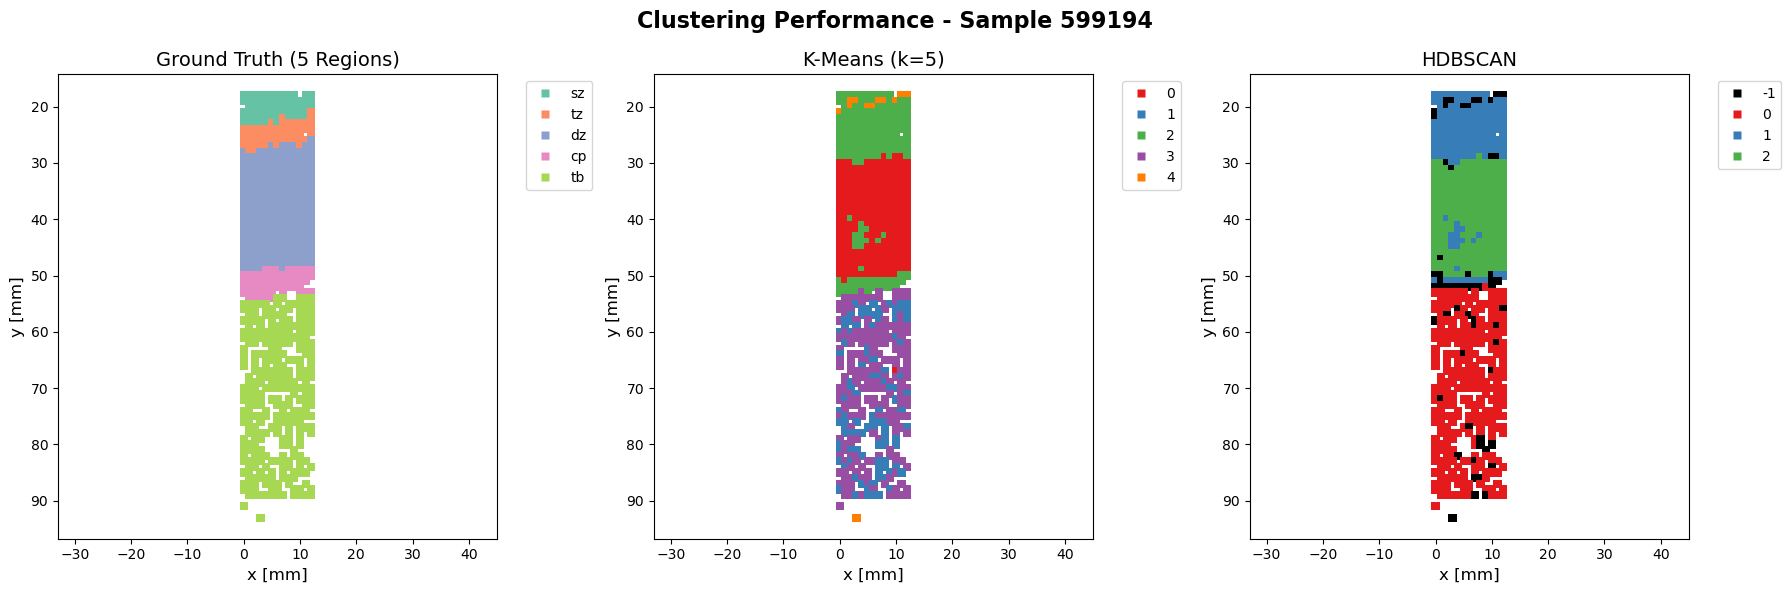

==== METRICS FOR SAMPLE 599200 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.380
Normalized Mutual Info (NMI): 0.583
Homogeneity:                  0.636
Completeness:                 0.539
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.869
Normalized Mutual Info (NMI): 0.833
Homogeneity:                  0.797
Completeness:                 0.872
Noise Percentage:             20.1%



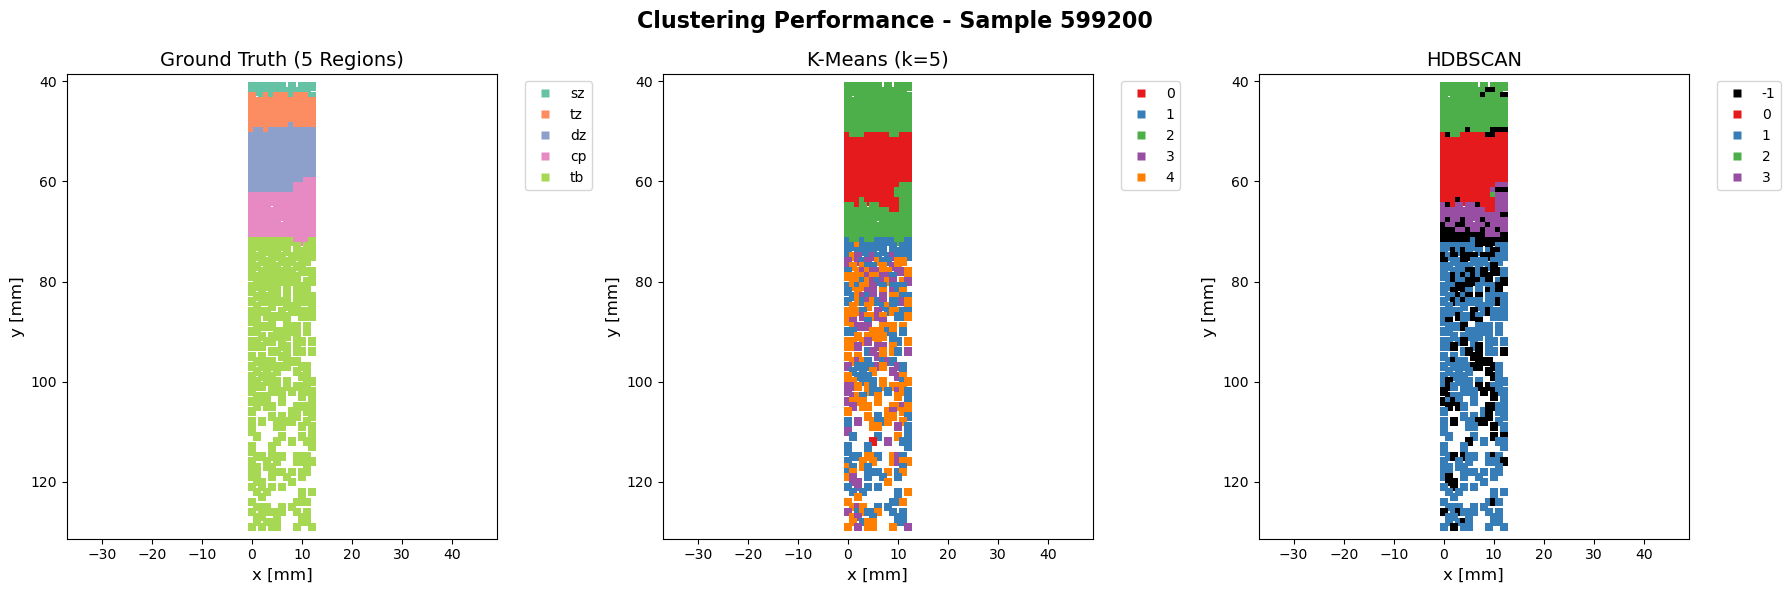

==== METRICS FOR SAMPLE 599168 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.547
Normalized Mutual Info (NMI): 0.580
Homogeneity:                  0.596
Completeness:                 0.565
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.713
Normalized Mutual Info (NMI): 0.697
Homogeneity:                  0.611
Completeness:                 0.810
Noise Percentage:             3.5%



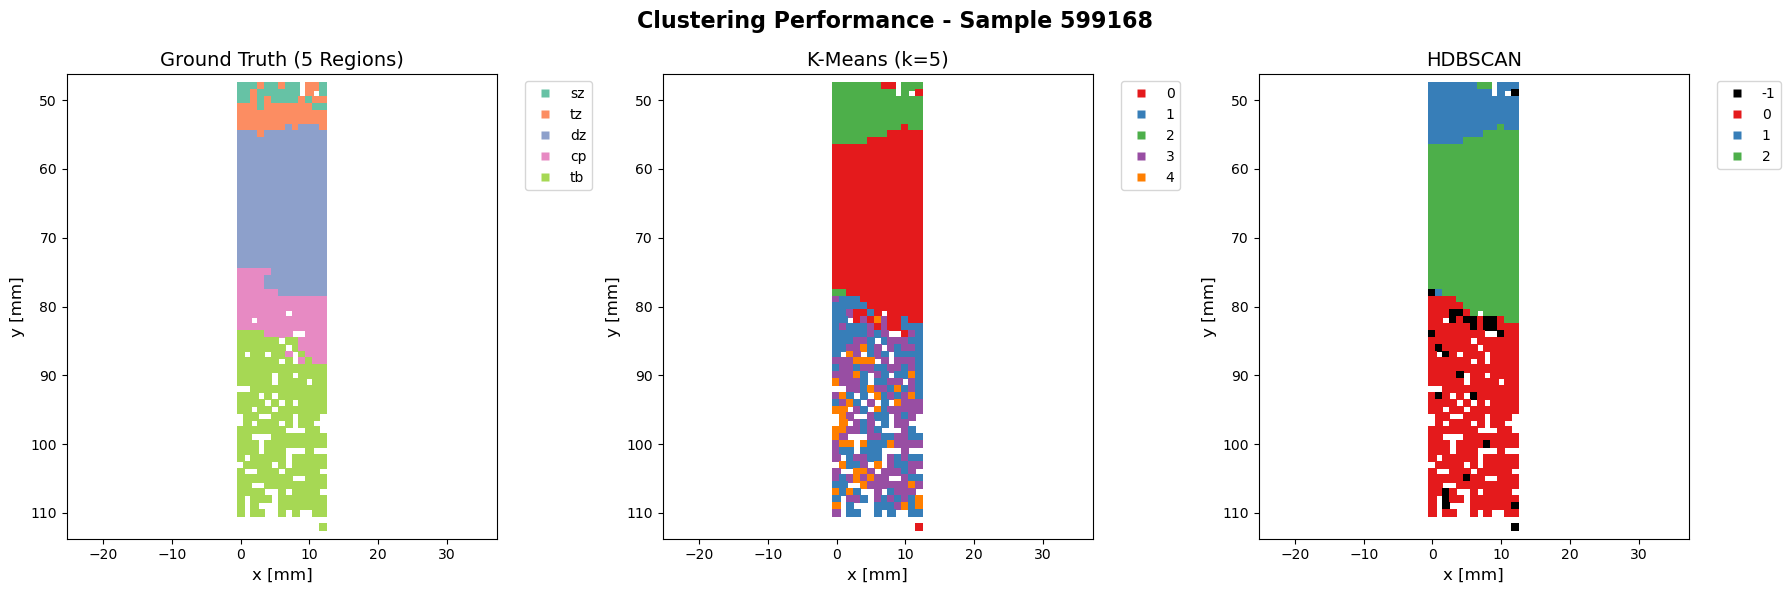

==== METRICS FOR SAMPLE 599176 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.348
Normalized Mutual Info (NMI): 0.406
Homogeneity:                  0.484
Completeness:                 0.349
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.436
Normalized Mutual Info (NMI): 0.549
Homogeneity:                  0.621
Completeness:                 0.492
Noise Percentage:             12.0%



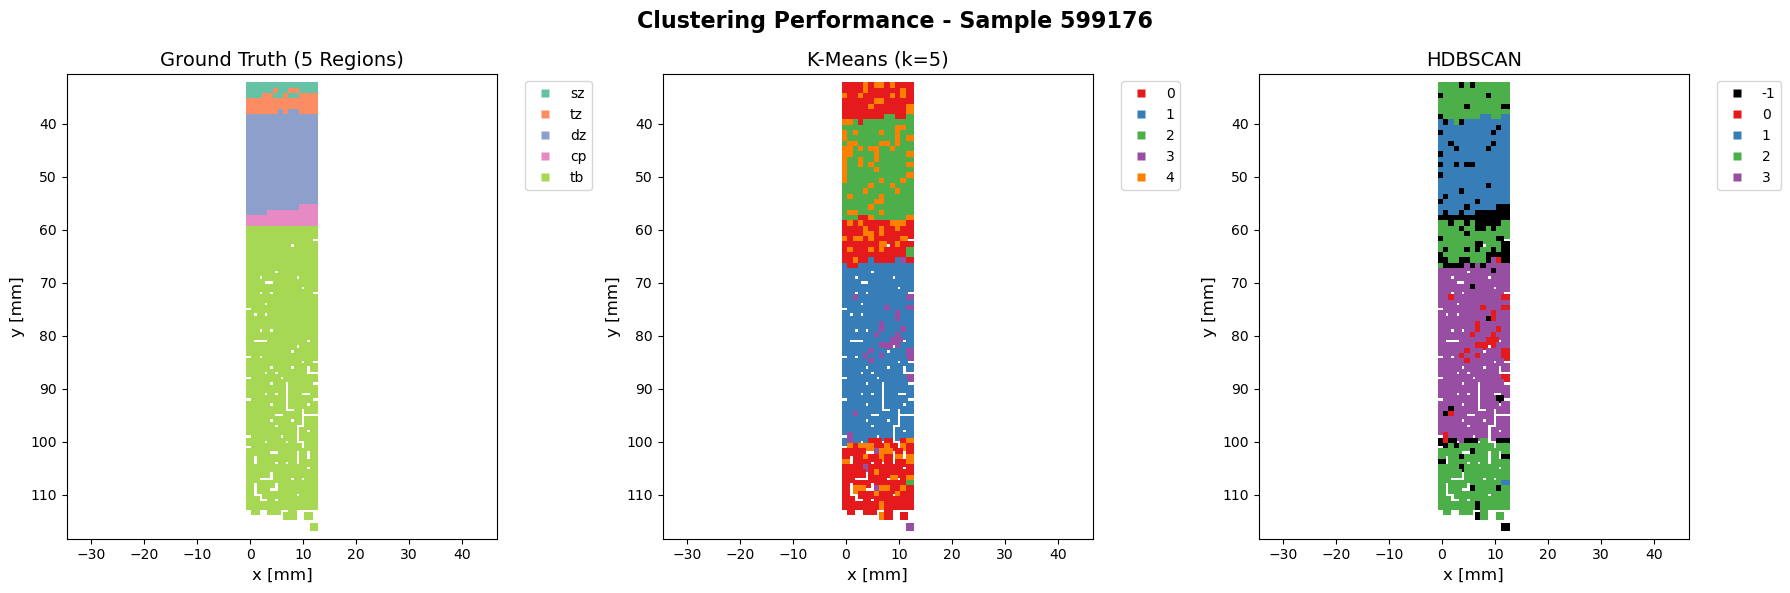

==== METRICS FOR SAMPLE 599182 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.496
Normalized Mutual Info (NMI): 0.605
Homogeneity:                  0.653
Completeness:                 0.563
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.769
Normalized Mutual Info (NMI): 0.742
Homogeneity:                  0.668
Completeness:                 0.835
Noise Percentage:             16.2%



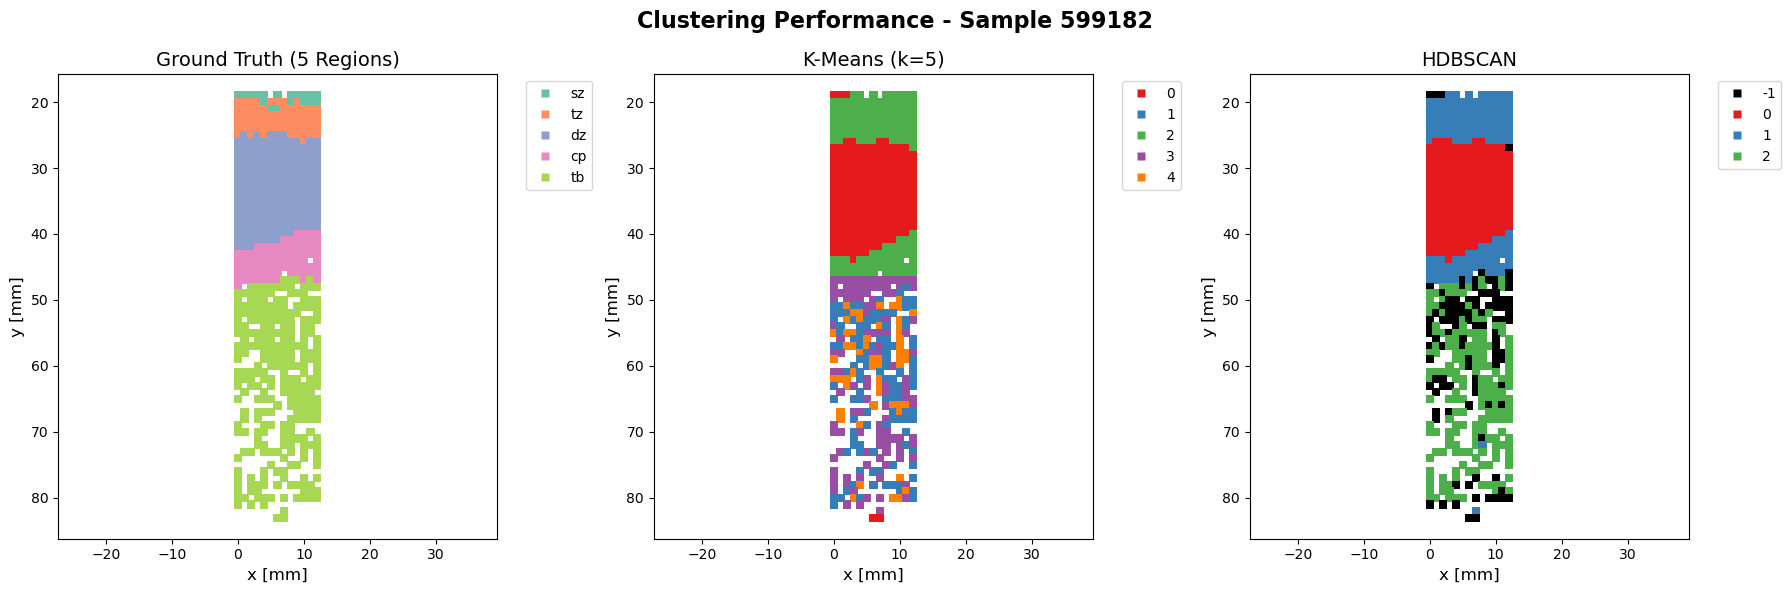

==== METRICS FOR SAMPLE 599195 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.517
Normalized Mutual Info (NMI): 0.586
Homogeneity:                  0.604
Completeness:                 0.569
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.684
Normalized Mutual Info (NMI): 0.688
Homogeneity:                  0.672
Completeness:                 0.704
Noise Percentage:             18.4%



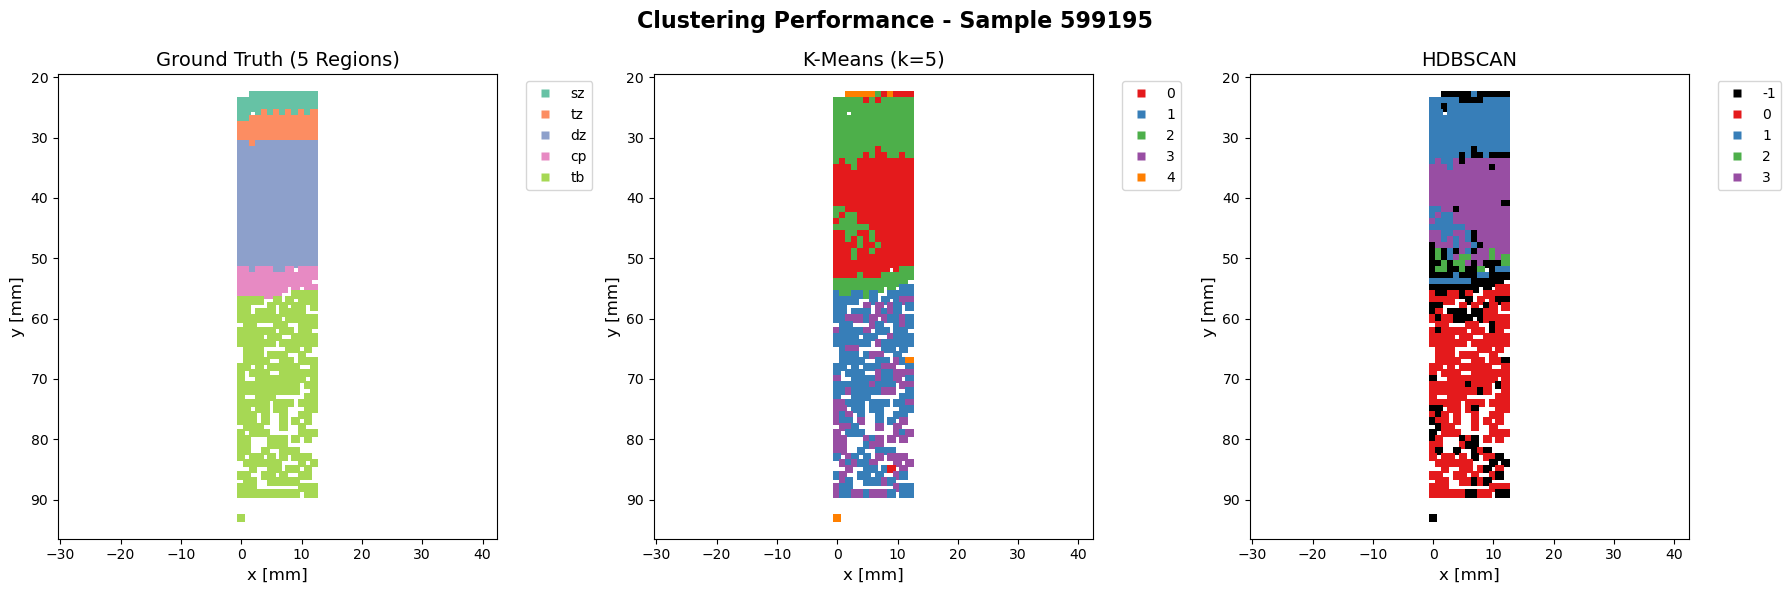

==== METRICS FOR SAMPLE 599201 ====
K-MEANS:
Adjusted Rand Index (ARI):    0.413
Normalized Mutual Info (NMI): 0.587
Homogeneity:                  0.640
Completeness:                 0.542
Noise Percentage:             0.0%

HDBSCAN:
Adjusted Rand Index (ARI):    0.882
Normalized Mutual Info (NMI): 0.818
Homogeneity:                  0.787
Completeness:                 0.852
Noise Percentage:             16.8%



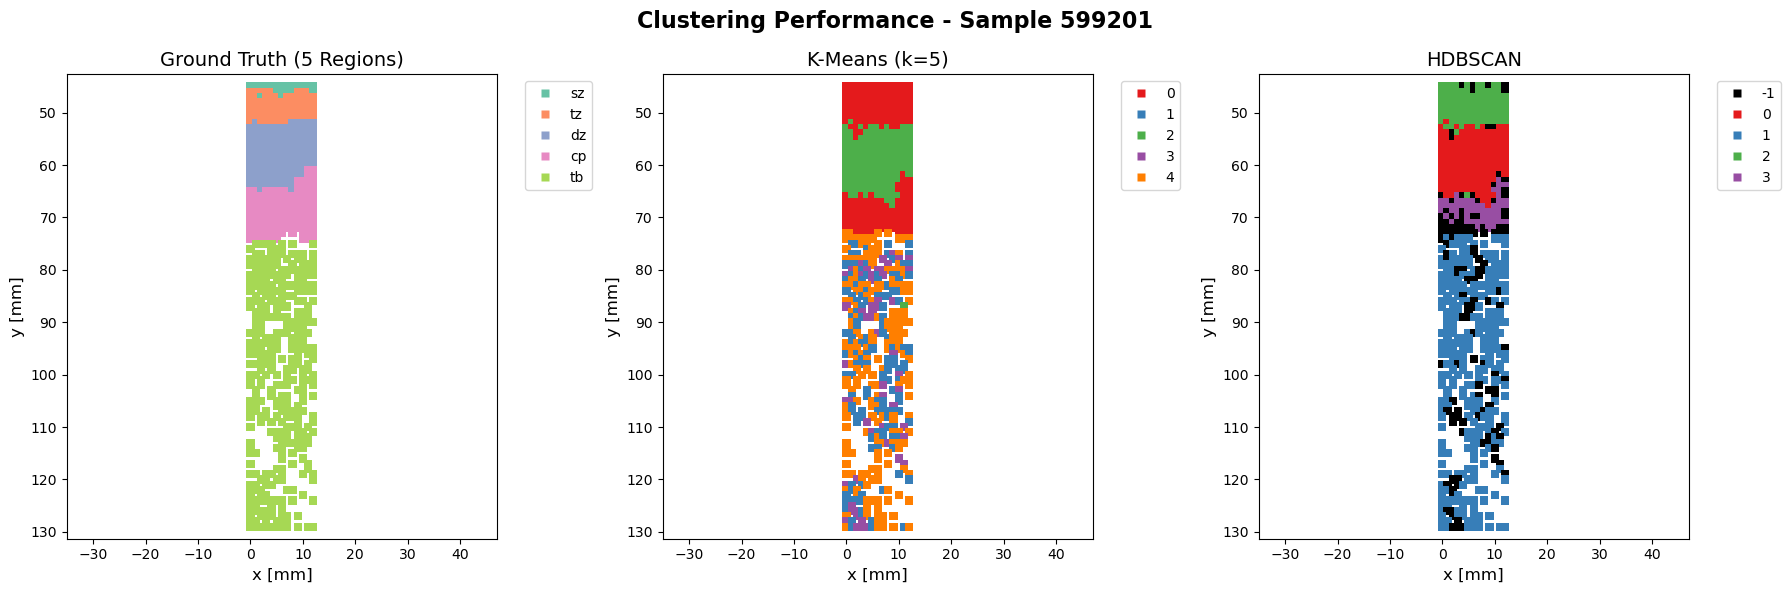


     OVERALL AVERAGES ACROSS ALL SAMPLES

--- K-MEANS AVERAGE ---


,Mean Score
ARI,0.560
NMI,0.632
Homogeneity,0.664
Completeness,0.610
Noise_%,0.000



--- HDBSCAN AVERAGE ---


,Mean Score
ARI,0.799
NMI,0.776
Homogeneity,0.732
Completeness,0.834
Noise_%,11.632


In [9]:
# ==========================================
# Selecting the sampples to run
# ==========================================

# Run ALL 60 samples (for stage 1, 2 and 3)
samples_to_run = df_import['sample no'].unique()

# Run ONLY Control samples (Stage 4)
#samples_to_run = df_import[df_import['Sample'] == 'control']['sample no'].unique()

# Run ONLY Low Injury samples (Stage 4)
# samples_to_run = df_import[df_import['Sample'] == 'lowinjury']['sample no'].unique()

# Run ONLY High Injury samples (Stage 4)
# samples_to_run = df_import[df_import['Sample'] == 'highinjury']['sample no'].unique()
# samples_to_run = [599133, 599134, 599135]


# ==========================================
# RUN PIPELINE
# ==========================================

# Features: 'totalint', 'totalcoll', 'rho_new', 'Dnew2', 'Diameter2', 'wa2'
z_parameters = ['rho_new', 'totalint', 'totalcoll'] 
#z_parameters = ['rho_new', 'Dnew2', 'Diameter2','wa2', 'totalint', 'totalcoll']

all_k_scores = []
all_hdb_scores = []

# Run models
for current_sample in samples_to_run:
    k_res, hdb_res = analyse_and_plot_sample(   # returns k_metrics, hdb_metrics from analyse function as k_res and hdb_res
        sample_num=current_sample, 
        df_master=df_import, 
        z_params=z_parameters, 
        hdb_csize= 13,     # min_cluster_size
        hdb_msamples= 13,   # min_samples
        scaler_k=StandardScaler(),   # StandardScaler vs MinMacScaler vs RobustScaler
        scaler_hdb=StandardScaler()

    )

    if k_res: all_k_scores.append(k_res)
    if hdb_res: all_hdb_scores.append(hdb_res)


# Overall Metrics
print("\n" + "="*40)
print("     OVERALL AVERAGES ACROSS ALL SAMPLES")
print("="*40)

print("\n--- K-MEANS AVERAGE ---")
display(pd.DataFrame(all_k_scores).mean().round(3).to_frame(name='Mean Score'))

print("\n--- HDBSCAN AVERAGE ---")
display(pd.DataFrame(all_hdb_scores).mean().round(3).to_frame(name='Mean Score'))

#### End

# plots
## 1. Kmeans (Stage 1)

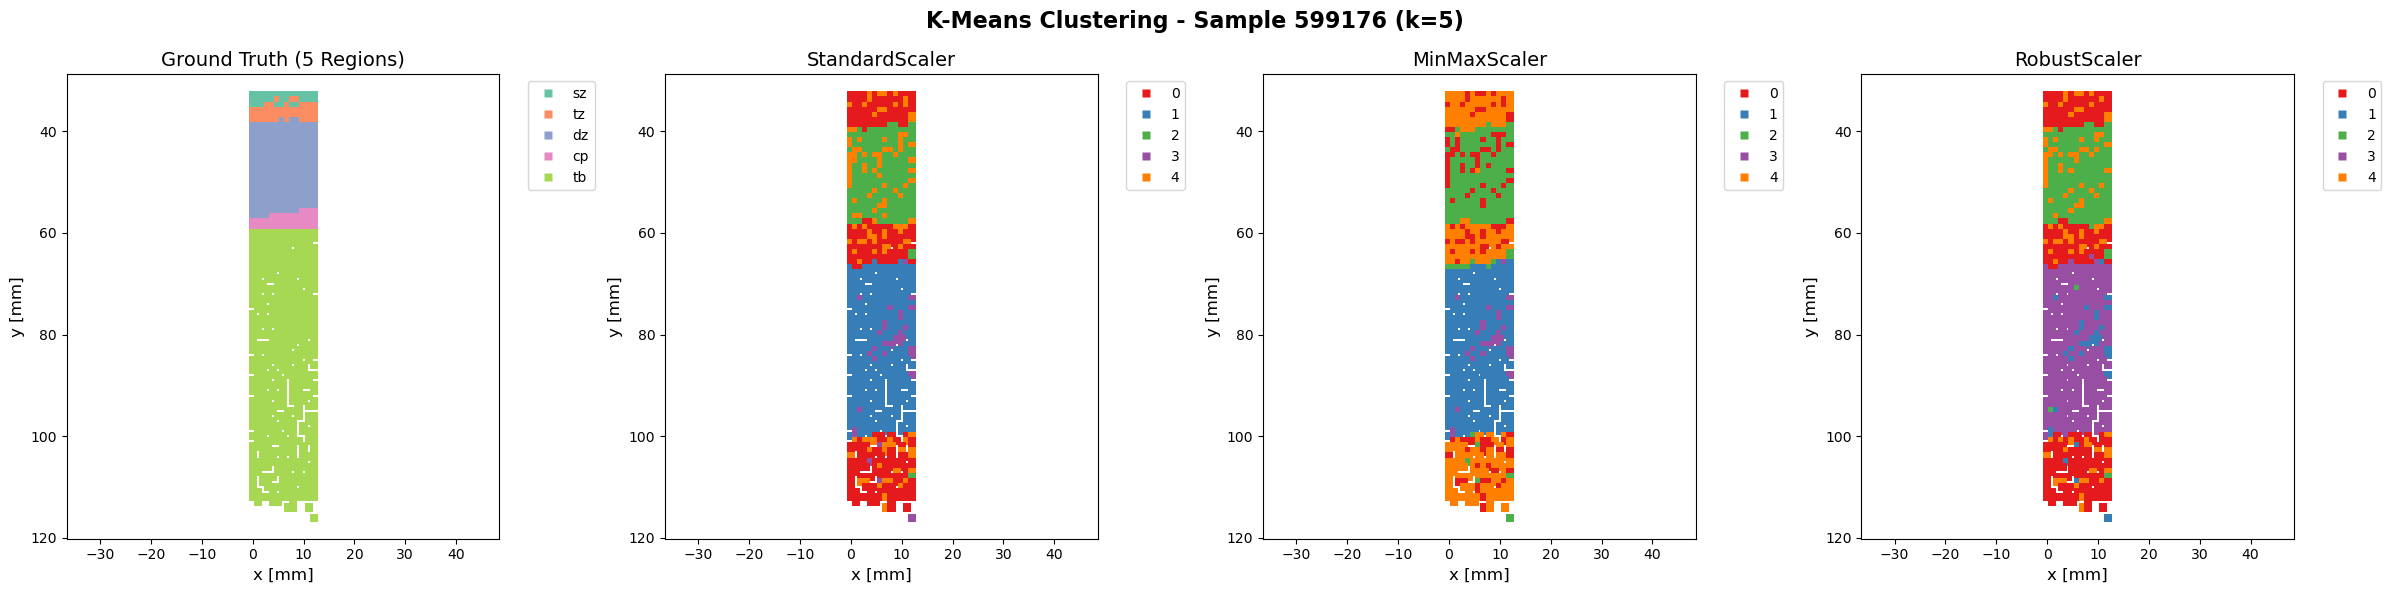

In [10]:
# ==========================================
# 1. CHOOSE YOUR SAMPLE HERE
# ==========================================
target_sample = 599176  # Swap this to a healthy 5-region control
z_params = ['rho_new', 'totalint', 'totalcoll']

# Isolate the data and drop NaNs
df_plot = df_import[df_import['sample no'] == target_sample].dropna(subset=z_params).copy()
k_val = df_plot['region'].nunique()

# ==========================================
# 2. SCALE THE DATA (3 WAYS)
# ==========================================
X_std = StandardScaler().fit_transform(df_plot[z_params])
X_minmax = MinMaxScaler().fit_transform(df_plot[z_params])
X_rob = RobustScaler().fit_transform(df_plot[z_params])

# ==========================================
# 3. RUN K-MEANS (3 TIMES)
# ==========================================
km = KMeans(n_clusters=k_val, random_state=42)

df_plot['k_std'] = km.fit_predict(X_std)
df_plot['k_minmax'] = km.fit_predict(X_minmax)
df_plot['k_rob'] = km.fit_predict(X_rob)

# ==========================================
# 4. PLOT THE 1x4 GRID
# ==========================================
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle(f'K-Means Clustering - Sample {target_sample} (k={k_val})', fontsize=16, fontweight='bold')

# --- Plot 1: Ground Truth ---
sns.scatterplot(data=df_plot, x='ix', y='iy', hue='region', palette='Set2', 
                edgecolor='none', s=35, marker='s', ax=axes[0])
axes[0].set_title(f'Ground Truth ({k_val} Regions)', fontsize=14)

# --- Plot 2: Standard Scaler ---
sns.scatterplot(data=df_plot, x='ix', y='iy', hue='k_std', palette=my_colors, 
                edgecolor='none', s=35, marker='s', ax=axes[1])
axes[1].set_title('StandardScaler', fontsize=14)

# --- Plot 3: MinMax Scaler ---
sns.scatterplot(data=df_plot, x='ix', y='iy', hue='k_minmax', palette=my_colors, 
                edgecolor='none', s=35, marker='s', ax=axes[2])
axes[2].set_title('MinMaxScaler', fontsize=14)

# --- Plot 4: Robust Scaler ---
sns.scatterplot(data=df_plot, x='ix', y='iy', hue='k_rob', palette=my_colors, 
                edgecolor='none', s=35, marker='s', ax=axes[3])
axes[3].set_title('RobustScaler', fontsize=14)

# Clean up axes
for ax in axes:
    ax.axis('equal')
    ax.invert_yaxis()
    ax.set_xlabel('x [mm]', fontsize=12)
    ax.set_ylabel('y [mm]', fontsize=12)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## HDBSCAN (Stage 1)

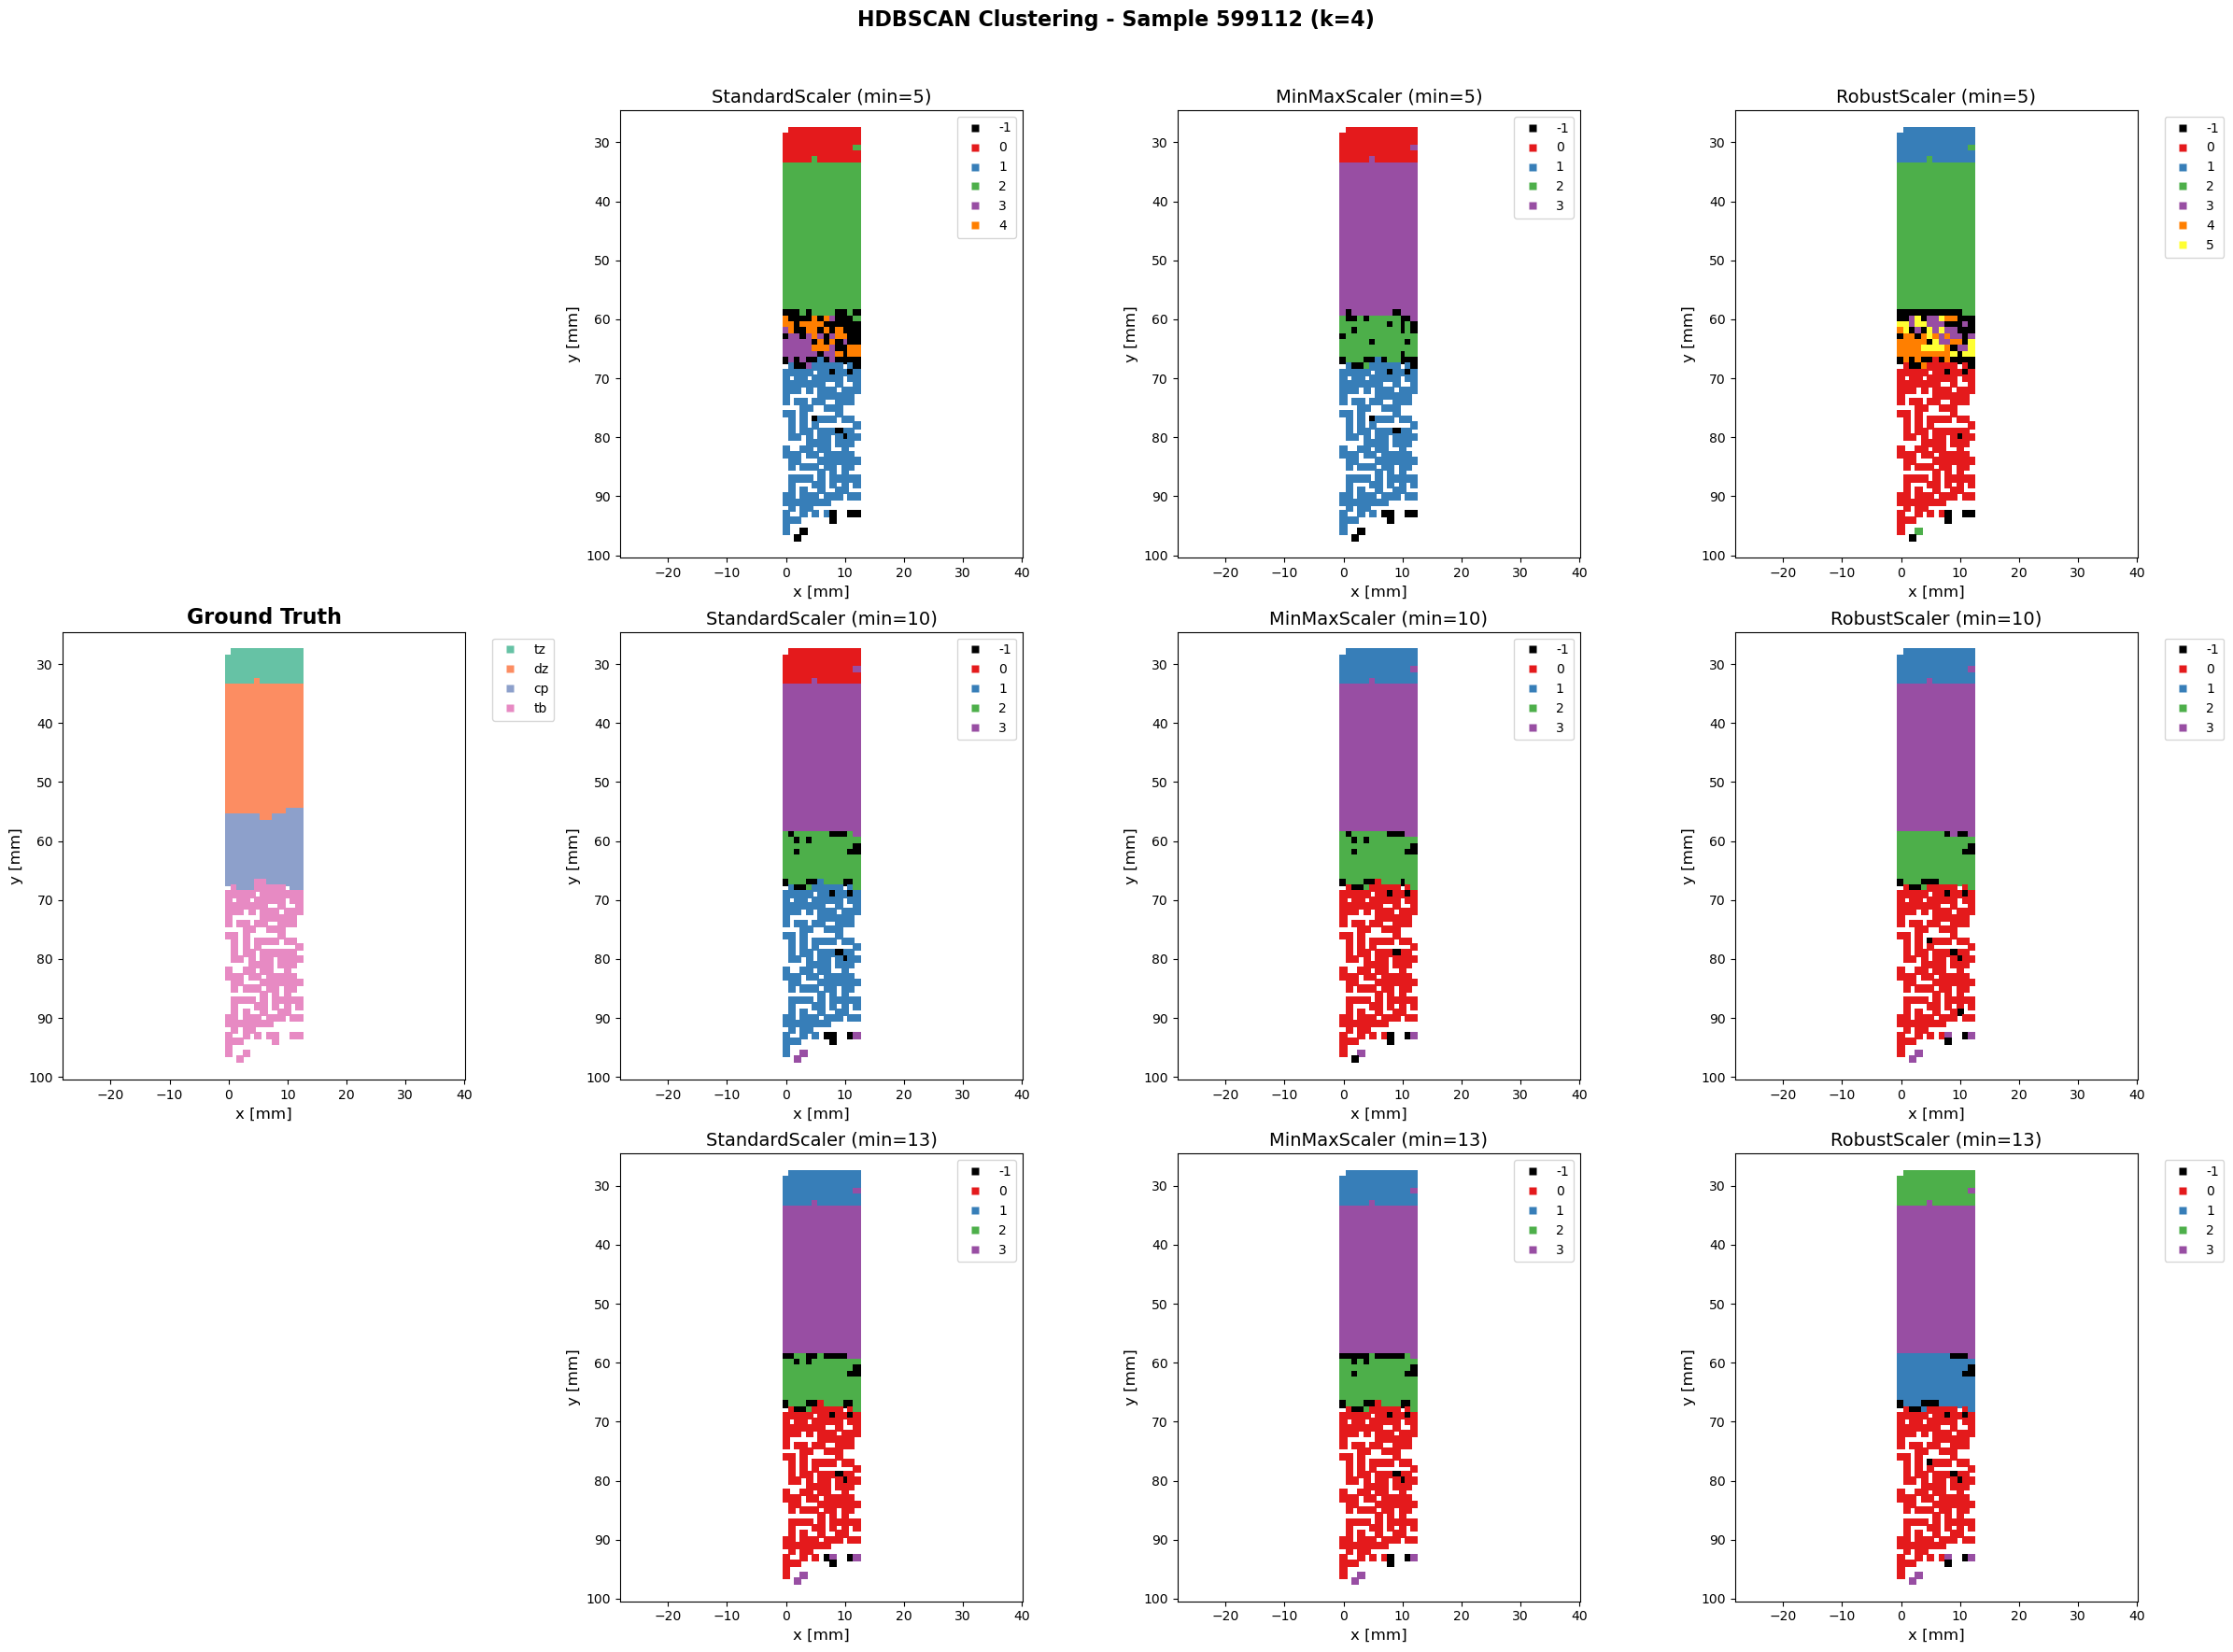

In [11]:
# ==========================================
# 1. CHOOSE YOUR SAMPLE HERE
# ==========================================
target_sample = 599112 # Keep hunting for a 5-region one!
z_params = ['rho_new', 'totalint', 'totalcoll']
hdb_csize = 13

# Isolate the data
df_plot = df_import[df_import['sample no'] == target_sample].dropna(subset=z_params).copy()
k_val = df_plot['region'].nunique()

# ==========================================
# 2. SCALE THE DATA (3 WAYS)
# ==========================================
X_std = StandardScaler().fit_transform(df_plot[z_params])
X_minmax = MinMaxScaler().fit_transform(df_plot[z_params])
X_rob = RobustScaler().fit_transform(df_plot[z_params])

# ==========================================
# 3. SETUP THE 3x4 GRID
# ==========================================
fig, axes = plt.subplots(3, 4, figsize=(24, 18))
fig.suptitle(f'HDBSCAN Clustering - Sample {target_sample} (k={k_val})', fontsize=16, fontweight='bold')

# Hide Top-Left and Bottom-Left axes
axes[0, 0].axis('off')
axes[2, 0].axis('off')

# Plot Ground Truth in the Middle-Left (Row 1, Col 0)
sns.scatterplot(data=df_plot, x='ix', y='iy', hue='region', palette='Set2', 
                edgecolor='none', s=35, marker='s', ax=axes[1, 0])
axes[1, 0].set_title(f'Ground Truth', fontsize=16, fontweight='bold')
axes[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# ==========================================
# 4. RUN AND PLOT THE 3x3 MATRIX
# ==========================================
min_samples_list = [5, 10, 13]
scalers = [('StandardScaler', X_std), ('MinMaxScaler', X_minmax), ('RobustScaler', X_rob)]

for row_idx, ms in enumerate(min_samples_list):
    for col_idx, (s_name, X_scaled) in enumerate(scalers):
        
        # Shift col_idx by 1 because Col 0 is for the Ground Truth
        actual_col = col_idx + 1
        
        # Run HDBSCAN
        hdb = hdbscan.HDBSCAN(min_cluster_size=hdb_csize, min_samples=ms)
        labels = hdb.fit_predict(X_scaled)
        
        # Plot
        sns.scatterplot(x=df_plot['ix'], y=df_plot['iy'], hue=labels, palette=my_colors, 
                        edgecolor='none', s=35, marker='s', ax=axes[row_idx, actual_col])
        axes[row_idx, actual_col].set_title(f'{s_name} (min={ms})', fontsize=14)
        
        # Add legend only to the far-right column to avoid clutter
        if actual_col == 3:
            axes[row_idx, actual_col].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# ==========================================
# 5. CLEANUP FORMATTING
# ==========================================
for r in range(3):
    for c in range(4):
        if (r == 0 and c == 0) or (r == 2 and c == 0):
            continue  # Skip the hidden axes
            
        axes[r, c].axis('equal')
        axes[r, c].invert_yaxis()
        axes[r, c].set_xlabel('x [mm]', fontsize=12)
        axes[r, c].set_ylabel('y [mm]', fontsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Give the main title some breathing room
plt.show()